In [92]:
import pandas as pd


In [93]:
volume = 38846600
volatility = 0.00929 # 5-day STD
df = pd.read_csv('aapl-merged.csv')
df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True) # time standard
df = df.sort_values('ts_event').reset_index(drop=True) # date sort
market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59

# Set 'ts_event' as the index
df.set_index('ts_event', inplace=True)
# Filter data between market open and close times
df_market = df.between_time(market_open_time, market_close_time)

# Aggregation
df_minute = df_market.resample('1h').agg({
    'bid_fill': 'sum',
    'ask_fill': 'sum',
    'Signed Volume': 'sum',
    'best_bid': 'max',
    'best_ask': 'min',
})
df_minute = df_minute.reset_index()
df_minute['mid_price'] = (df_minute['best_bid'] + df_minute['best_ask']) / 2
print(df_minute.head())

                   ts_event    bid_fill    ask_fill  Signed Volume  best_bid  \
0 2024-10-21 13:00:00+00:00  15892048.0  14714621.0      1177427.0    235.48   
1 2024-10-21 14:00:00+00:00  28998881.0  30188796.0     -1189915.0    236.07   
2 2024-10-21 15:00:00+00:00  43421620.0  44799583.0     -1377963.0    236.44   
3 2024-10-21 16:00:00+00:00  24128658.0  21497440.0      2631218.0    236.60   
4 2024-10-21 17:00:00+00:00  16132179.0  14781517.0      1350662.0    236.83   

   best_ask  mid_price  
0    234.56    235.020  
1    234.96    235.515  
2    235.18    235.810  
3    235.96    236.280  
4    236.21    236.520  


In [94]:
min(df_minute['best_ask'])

219.75

In [95]:
min(df_minute['best_bid'])

221.75

R^2: 0.054370488686987795


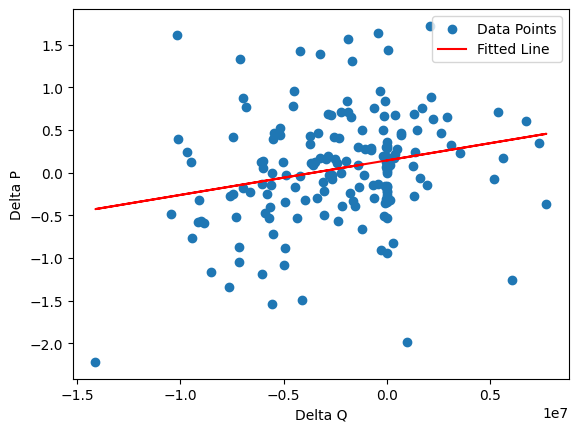

In [96]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df_minute['delta_p'] = df_minute['mid_price'].diff()
df_minute['delta_Q'] = df_minute['Signed Volume']
df_minute=df_minute.dropna(subset=['delta_p', 'delta_Q'])
X = df_minute[['delta_Q']].values
Y = df_minute['delta_p'].values
model = LinearRegression()
model.fit(X, Y)
lambda_value = model.coef_[0]
r2_score = model.score(X, Y)
# t-test and F-test for linearity

print(f"R^2: {r2_score}")
plt.scatter(X, Y, label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Fitted Line')
plt.xlabel('Delta Q')
plt.ylabel('Delta P')
plt.legend()
plt.show()

In [97]:
print('lambda: ',lambda_value)

lambda:  4.043766688096018e-08


In [98]:
import statsmodels.api as sm
X = df_minute['delta_Q']
y = df_minute['delta_p']

# Fit the linear regression model using statsmodels
model = sm.OLS(y, X).fit()

# Print the summary of the regression, which includes t-tests and F-test
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                delta_p   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):              0.019
Method:                 Least Squares   F-statistic:                              4.277
Date:                Mon, 02 Dec 2024   Prob (F-statistic):                      0.0402
Time:                        13:55:59   Log-Likelihood:                         -164.21
No. Observations:                 168   AIC:                                      330.4
Df Residuals:                     167   BIC:                                      333.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [99]:
print(model.pvalues)

delta_Q    0.040164
dtype: float64


## The above example shows that $\Delta P = \lambda \Delta Q$ works when we set resample = 1s or resample = 1h
Since Kevin Webster's implementation implies that we could also try $\Delta P = \lambda \sigma \frac{\Delta Q}{ADV}$
And it seems that estimation of $\beta=0.7$ assumes that $\Delta t = 1\text{h}$

In [100]:
import yfinance as yf
from datetime import timedelta

df = pd.read_csv('aapl-merged.csv')
df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True) # time standard
df = df.sort_values('ts_event').reset_index(drop=True) # date sort
df['Timestamp'] = pd.to_datetime(df['ts_event'])
df['Date'] = df['Timestamp'].dt.date
# Calculate the earliest and latest dates in 'df'
earliest_date = df['Date'].min()
latest_date = df['Date'].max()
# Adjust 'start_date' and 'end_date' based on 'df'
start_date = earliest_date - timedelta(days=30)  # Earliest date minus 30 days
end_date = latest_date + timedelta(days=1)       # Latest date plus 1 day
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')
# code to download daily volume and close price
data = yf.download('AAPL', start=start_date_str, end=end_date_str, interval='1d')
data = data.reset_index()
# Handle MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(level=1)
data['Return'] = data['Adj Close'].pct_change()
data['Volatility'] = data['Return'].rolling(window=5).std()  # 5-day rolling volatility
data['ADV'] = data['Volume'].rolling(window=10).mean() # 10-day rolling average daily volume
data = data.dropna()
# Ensure 'Date' column in 'data' matches the format in 'df'
data['Date'] = data['Date'].dt.date
merged_df = pd.merge(df, data, on='Date', how='left')
# print(merged_df.head())

[*********************100%***********************]  1 of 1 completed


In [101]:
merged_df = merged_df[['ts_event','bid_fill','ask_fill','Signed Volume','best_bid','best_ask','Volatility','ADV']]

market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59

# Set 'ts_event' as the index
merged_df.set_index('ts_event', inplace=True)
# Filter data between market open and close times
df_market = merged_df.between_time(market_open_time, market_close_time)

# Aggregation
df_minute = df_market.resample('1h').agg({
    'bid_fill': 'sum',
    'ask_fill': 'sum',
    'Signed Volume': 'sum',
    'best_bid': 'max',
    'best_ask': 'min',
    'Volatility': 'max',
    'ADV': 'max',
})
df_minute = df_minute.dropna(subset=['best_bid']) # downsample will fill NaNs to out-of-market hours
df_minute = df_minute.reset_index()
df_minute['mid_price'] = (df_minute['best_bid'] + df_minute['best_ask']) / 2
print(df_minute.head(), df_minute.shape)

                   ts_event    bid_fill    ask_fill  Signed Volume  best_bid  \
0 2024-10-21 13:00:00+00:00  15892048.0  14714621.0      1177427.0    235.48   
1 2024-10-21 14:00:00+00:00  28998881.0  30188796.0     -1189915.0    236.07   
2 2024-10-21 15:00:00+00:00  43421620.0  44799583.0     -1377963.0    236.44   
3 2024-10-21 16:00:00+00:00  24128658.0  21497440.0      2631218.0    236.60   
4 2024-10-21 17:00:00+00:00  16132179.0  14781517.0      1350662.0    236.83   

   best_ask  Volatility         ADV  mid_price  
0    234.56    0.008558  37978500.0    235.020  
1    234.96    0.008558  37978500.0    235.515  
2    235.18    0.008558  37978500.0    235.810  
3    235.96    0.008558  37978500.0    236.280  
4    236.21    0.008558  37978500.0    236.520   (192, 9)


R^2: 0.037398117666781916


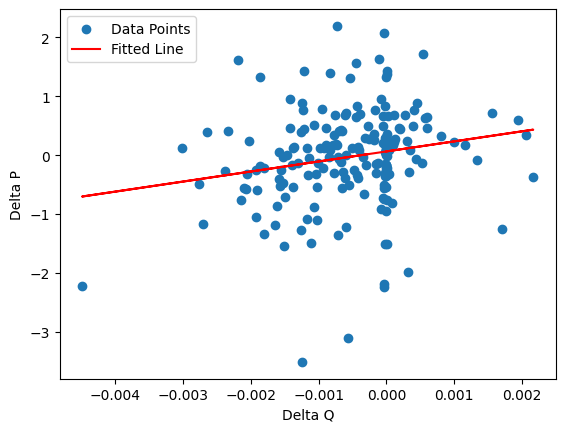

In [102]:
df_minute['delta_p'] = df_minute['mid_price'].diff()
df_minute['delta_Q'] = df_minute['Signed Volume'] * df_minute['Volatility'] / df_minute['ADV']

#df_minute=df_minute.dropna(subset=['delta_p', 'delta_Q'])
X = df_minute[['delta_Q']].values[1:]
Y = df_minute['delta_p'].values[1:]
model = LinearRegression()
model.fit(X, Y)
lambda_value = model.coef_[0]
r2_score = model.score(X, Y)
# t-test and F-test for linearity

print(f"R^2: {r2_score}")
plt.scatter(X, Y, label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Fitted Line')
plt.xlabel('Delta Q')
plt.ylabel('Delta P')
plt.legend()
plt.show()

In [103]:
import numpy as np
print(df_minute.shape)
print(sum(df_minute['best_bid'].isna()))
print(sum(df_minute['delta_p'].isna()))

(192, 11)
0
1


In [104]:
print('lambda: ',lambda_value)

lambda:  170.60589081550026


In [105]:
import statsmodels.api as sm
X = df_minute['delta_Q'][1:]
y = df_minute['delta_p'][1:]

# Fit the linear regression model using statsmodels
model = sm.OLS(y, X).fit()

# Print the summary of the regression, which includes t-tests and F-test
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                delta_p   R-squared (uncentered):                   0.034
Model:                            OLS   Adj. R-squared (uncentered):              0.029
Method:                 Least Squares   F-statistic:                              6.717
Date:                Mon, 02 Dec 2024   Prob (F-statistic):                      0.0103
Time:                        13:56:01   Log-Likelihood:                         -230.45
No. Observations:                 191   AIC:                                      462.9
Df Residuals:                     190   BIC:                                      466.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## It seems lambda estimation works for 1-hour-wise data, and the r square increases when we change it to adjusted $Q$.

In [106]:
import math
# set beta to hour frequency
h_minutes = 60 # hour-wise frequency
#input is h_minutes: h_minutes=60mins means the traded volume will influence the following 60 mins (exponential decay)
h_hours = h_minutes / 60

# Calculate beta using half-life transformation
beta = math.log(2) / h_hours
print(df_minute.head())

                   ts_event    bid_fill    ask_fill  Signed Volume  best_bid  \
0 2024-10-21 13:00:00+00:00  15892048.0  14714621.0      1177427.0    235.48   
1 2024-10-21 14:00:00+00:00  28998881.0  30188796.0     -1189915.0    236.07   
2 2024-10-21 15:00:00+00:00  43421620.0  44799583.0     -1377963.0    236.44   
3 2024-10-21 16:00:00+00:00  24128658.0  21497440.0      2631218.0    236.60   
4 2024-10-21 17:00:00+00:00  16132179.0  14781517.0      1350662.0    236.83   

   best_ask  Volatility         ADV  mid_price  delta_p   delta_Q  
0    234.56    0.008558  37978500.0    235.020      NaN  0.000265  
1    234.96    0.008558  37978500.0    235.515    0.495 -0.000268  
2    235.18    0.008558  37978500.0    235.810    0.295 -0.000311  
3    235.96    0.008558  37978500.0    236.280    0.470  0.000593  
4    236.21    0.008558  37978500.0    236.520    0.240  0.000304  


In [107]:
df_minute = df_minute.reset_index(drop=True)

price_impact = [0 for i in range(df_minute.shape[0])] # treat start of each trade day as I_0 = 0
delta_t = 1 # 1 hour
lambda_t = lambda_value
for time_i in range(df_minute.shape[0]-1):
    if df_minute.iloc[time_i,0].hour==13: # start of each day, but it relies on the frequency that is hour-wise
        continue
    I_t = price_impact[time_i]
    # I_t1 = lambda_t * df_minute.iloc[time_i,6] * df_minute.iloc[time_i,3] / df_minute.iloc[time_i,7] - beta * I_t * delta_t

    # Using loc just to increase readability of code
    delta_I = lambda_t * df_minute.loc[time_i,"Volatility"] * df_minute.loc[time_i,"Signed Volume"] / df_minute.loc[time_i,"ADV"] - beta * I_t * delta_t 

    # including I_t addition in the RHS
    I_t1 = I_t + delta_I

    price_impact[time_i+1] = I_t1
df_minute['price_impact'] = price_impact

# Formula Used Above : 
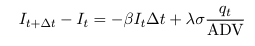

## Without + I_t
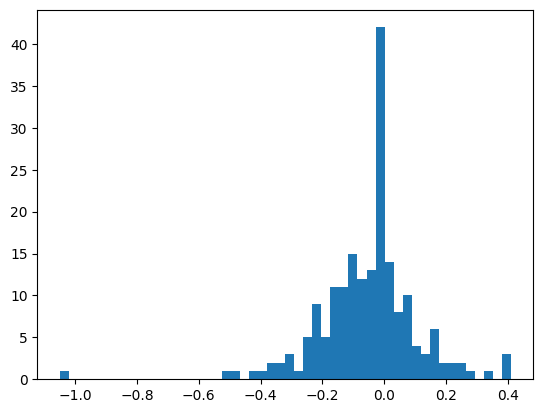


## With + I_t
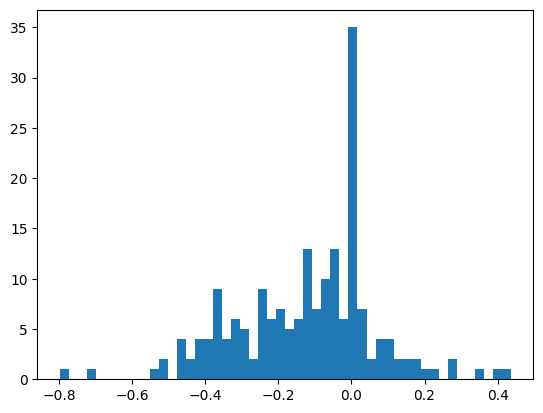

In [108]:
df_minute.iloc[time_i,:]

ts_event         2024-11-21 19:00:00+00:00
bid_fill                        13489883.0
ask_fill                        14138643.0
Signed Volume                    -648760.0
best_bid                            229.66
best_ask                            229.01
Volatility                         0.00993
ADV                             42032220.0
mid_price                          229.335
delta_p                             -0.295
delta_Q                          -0.000153
price_impact                     -0.027817
Name: 190, dtype: object

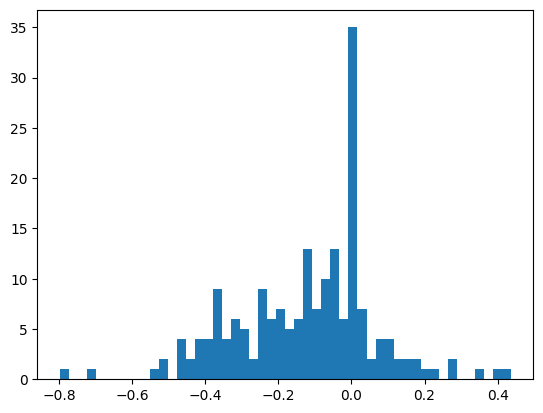

In [109]:
plt.hist(df_minute['price_impact'], bins=50)
plt.show()

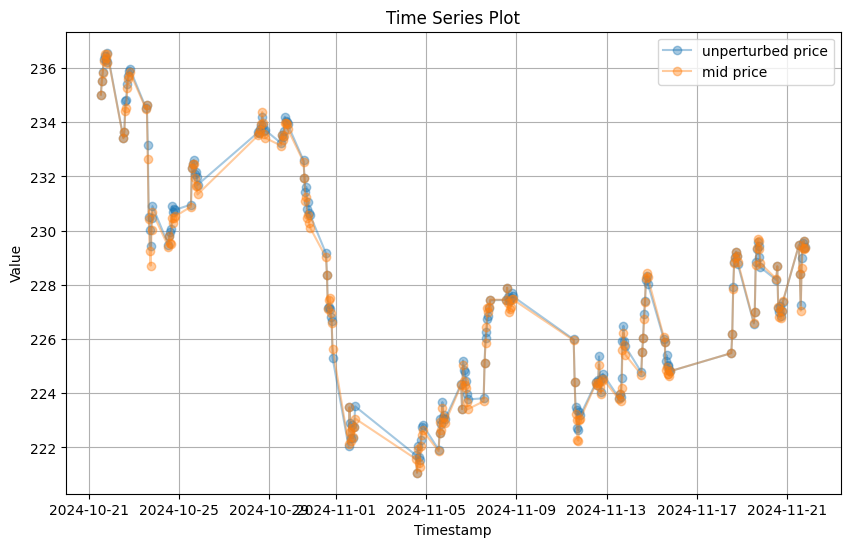

In [110]:
df_minute['unperturbed_price'] = df_minute['mid_price'] - df_minute['price_impact']
plt.figure(figsize=(10, 6))
plt.plot(df_minute['ts_event'], df_minute['unperturbed_price'], marker='o', alpha=0.4,label='unperturbed price')
plt.plot(df_minute['ts_event'], df_minute['mid_price'], marker='o', alpha=0.4,label='mid price')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Time Series Plot')
plt.legend()
plt.grid(True)
plt.show()

In [111]:
def determined_strategy(data):
    """
    Function to estimate alpha.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'price' columns.

    Returns:
        dict: Keys as dates and values as calculated price differences.
    """
    # Extract date and time components
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time

    # Get the closing price for each date
    end_time = pd.to_datetime('20:00:00').time()
    filtered_data = data
    closing_prices = filtered_data[filtered_data['time'] == end_time].set_index('date')['unperturbed_price']

    # Calculate the new prices for each date
    def calculate_difference(row):
        return row['unperturbed_price'] - closing_prices.get(row['date'], np.nan)

    filtered_data['determined_alpha'] = filtered_data.apply(calculate_difference, axis=1)
    filtered_data.drop('date', axis=1, inplace=True)
    filtered_data.drop('time', axis=1, inplace=True)

    # Aggregate results by date
    #result = filtered_data.groupby('date')['calculated_price'].apply(list).to_dict()

    return filtered_data

In [112]:
res = determined_strategy(df_minute)

In [113]:
for i in res['determined_alpha']:
    print(i)

-1.5480361638528848
-1.0530361638528802
-0.7122896234456277
-0.22102262237234527
-0.1286306167389455
-0.2696932926593263
-0.3604424764756686
0.0
-2.5466208518212454
-2.3231036366436797
-1.192348699138023
-1.154091440242098
-0.5488585083799933
-0.25863853420869987
-0.07356023470907758
0.0
3.628606614374519
3.719941167206315
2.244138024411683
-0.3854630176275009
-0.862599542865695
-1.4878935540168072
-0.43759335973373936
0.0
-1.2878007451329267
-0.9519574192433424
-0.8234588841547463
-0.7226188002414347
0.12623555316912416
-0.0954681258675123
0.050773410094592464
0.0
-0.7266796476757236
0.6307222420543042
0.7587526070308286
0.9130413233523882
0.4195329270465322
0.46754374263409204
0.28758773328769394
0.0
-0.0758599638209887
-0.09739671632593172
0.05051301087044635
0.17436660212408128
0.4765870697046637
0.17861110107031664
-0.05670551258356227
0.0
-0.7036432348477604
-0.38907357685278043
-0.4844913241507811
-0.2439645837583555
0.2680851936650299
0.10477426678576762
0.08161569425126913
0.0

## We can assume $I_{0}^{*}=0$, and since un-normalized $Q_0$ is position for the whole market, which is very big, we should set normalzied $Q_0=1$ (determined formula), or we can just set $\nu=0$ (Stochastic formula).

In [114]:
def nu(data, beta, lambda_t, T=6.5):
    """
    Function to estimate nu.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.
        beta (float): A parameter.
        lambda_t (float): Another parameter.
        T (float): Total time, default is 6.5 hours each day.

    Returns:
        pd.DataFrame: Original data with a new 'determined_nu' column.
    """
    Q_0 = 0.01 # this value is tricky, since this value is the normalized start position for each day
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    start_time = pd.to_datetime('13:00:00').time()
    
    def calculate_nu(group):
        # Get 'determined_alpha' at start_time
        start_alpha_series = group.loc[group['time'] == start_time, 'determined_alpha']
        if not start_alpha_series.empty:
            start_alpha = start_alpha_series.iloc[0]
        else:
            # Handle case where start_time is not present
            start_alpha = 0  # Or use an appropriate default value
        summed_alpha = group['determined_alpha'].sum()
        res = (start_alpha + beta * summed_alpha + 2 * lambda_t * Q_0) * -1 / (2 + beta * T)
        return res
    
    # Compute 'determined_nu' per date
    nu_values = data.groupby('date').apply(calculate_nu,include_groups=False).reset_index(name='determined_nu')
    
    # Merge back into 'data'
    data = data.merge(nu_values, on='date', how='left')
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data

res = nu(res, beta, lambda_t)


In [115]:
def alpha_prime(data):
    """
    Function to estimate the difference of 'determined_alpha' per day.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.

    Returns:
        pd.DataFrame: Original data with a new 'determined_alpha_prime' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    end_time = pd.to_datetime('20:00:00').time()

    def calculate_alpha_prime(group):
        # Ensure the group is sorted by 'ts_event' if necessary
        group = group.sort_values('ts_event')
        res = group['determined_alpha'].diff()
        return res
    
    def calculate_I_star(group, nu=0):
        '''stochastic I_star where nu=0, but here we assume we have perfect alpha estimation
        '''
        res = ((group['determined_alpha'] - (group['determined_alpha_prime'] / beta))/2).fillna(0)
        res[group['time']==end_time] = nu
        return res

    # Compute 'determined_alpha_prime' per date and align with original index
    data['determined_alpha_prime'] = data.groupby('date').apply(calculate_alpha_prime,include_groups=False).reset_index(level=0, drop=True)
    data['I_star_t'] = data.groupby('date').apply(calculate_I_star,include_groups=False).reset_index(level=0, drop=True)
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data
res = alpha_prime(res)

In [116]:
#res['I_star_t'] = ((res['determined_alpha'] - (res['determined_alpha_prime'] / beta)  + res['determined_nu'])/2).fillna(0)
#res['I_star_t'] = ((res['determined_alpha'] - (res['determined_alpha_prime'] / beta))/2).fillna(0)
res['delta_Q_star'] = ((res['I_star_t'].diff() + beta * res['I_star_t'])/lambda_t).fillna(0)
res['myopic_market_obj'] = (beta * res['determined_alpha'] * res['price_impact'] - res['determined_alpha_prime'] * res['price_impact'] - beta*res['price_impact']**2).fillna(0)
res['myopic_opt_obj'] = (beta * res['determined_alpha'] * res['I_star_t'] - res['determined_alpha_prime'] * res['I_star_t'] - beta*res['I_star_t']**2).fillna(0)


In [117]:
def PnL(data):
    """
    Function to estimate nu.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.
    Returns:
        pd.DataFrame: Original data with a new 'determined_nu' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    end_time = pd.to_datetime('20:00:00').time()
    
    def calculate_optimal_PnL(group):
        # Get 'determined_alpha' at start_time
        res = ((group['determined_alpha'] - group['I_star_t']) * group['delta_Q_star']).cumsum()
        return res
    
    def calculate_PnL(group):
        # Get 'determined_alpha' at start_time
        res = ((group['determined_alpha'] - group['price_impact']) * group['delta_Q']).cumsum()
        return res
    
    def calculate_integral(group):
        a=group['myopic_market_obj'].sum() + group[group['time'] == end_time]['determined_alpha'] * group[group['time'] == end_time]['price_impact']
        a=a-(group[group['time'] == end_time]['price_impact'])**2/2
        return a
    
    def calculate_optimal_integral(group):
        a=group['myopic_opt_obj'].sum()+group[group['time'] == end_time]['determined_alpha'] * group[group['time'] == end_time]['I_star_t']
        a=a-(group[group['time'] == end_time]['I_star_t'])**2/2
        return a
    
    data['optimal_PnL'] = data.groupby('date').apply(calculate_optimal_PnL,include_groups=False).reset_index(level=0, drop=True)
    data['PnL'] = data.groupby('date').apply(calculate_PnL,include_groups=False).reset_index(level=0, drop=True)
    data['integral'] = data.groupby('date').apply(calculate_integral,include_groups=False).reset_index(level=0, drop=True)
    data['optimal_integral'] = data.groupby('date').apply(calculate_optimal_integral,include_groups=False).reset_index(level=0, drop=True)
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data
res = PnL(res)

In [118]:
res[['PnL','optimal_PnL','I_star_t','delta_Q_star','determined_alpha','price_impact','delta_Q']]

,PnL,optimal_PnL,I_star_t,delta_Q_star,determined_alpha,price_impact,delta_Q
0,-0.000411,-0.000000,0.000000,0.000000,-1.548036,0.000000,2.653275e-04
1,-0.000128,0.001486,-0.883585,-0.008769,-1.053036,0.000000,-2.681416e-04
2,0.000079,0.001574,-0.601941,-0.000795,-0.712290,-0.045747,-3.105173e-04
3,-0.000013,0.001309,-0.464886,-0.001085,-0.221023,-0.067014,5.929323e-04
4,-0.000076,0.001312,-0.130962,0.001425,-0.128631,0.080594,3.043652e-04
...,...,...,...,...,...,...,...
187,0.004712,-0.009313,-1.455973,-0.012983,-0.409557,-0.370127,-4.473135e-04
188,0.004857,-0.006682,-0.333107,0.005228,0.170205,-0.189889,4.025980e-04
189,0.004817,-0.006261,0.071889,0.002666,0.229898,0.010418,-1.817884e-04
190,0.004817,-0.006516,0.171783,0.001283,-0.026866,-0.027817,-1.532661e-04


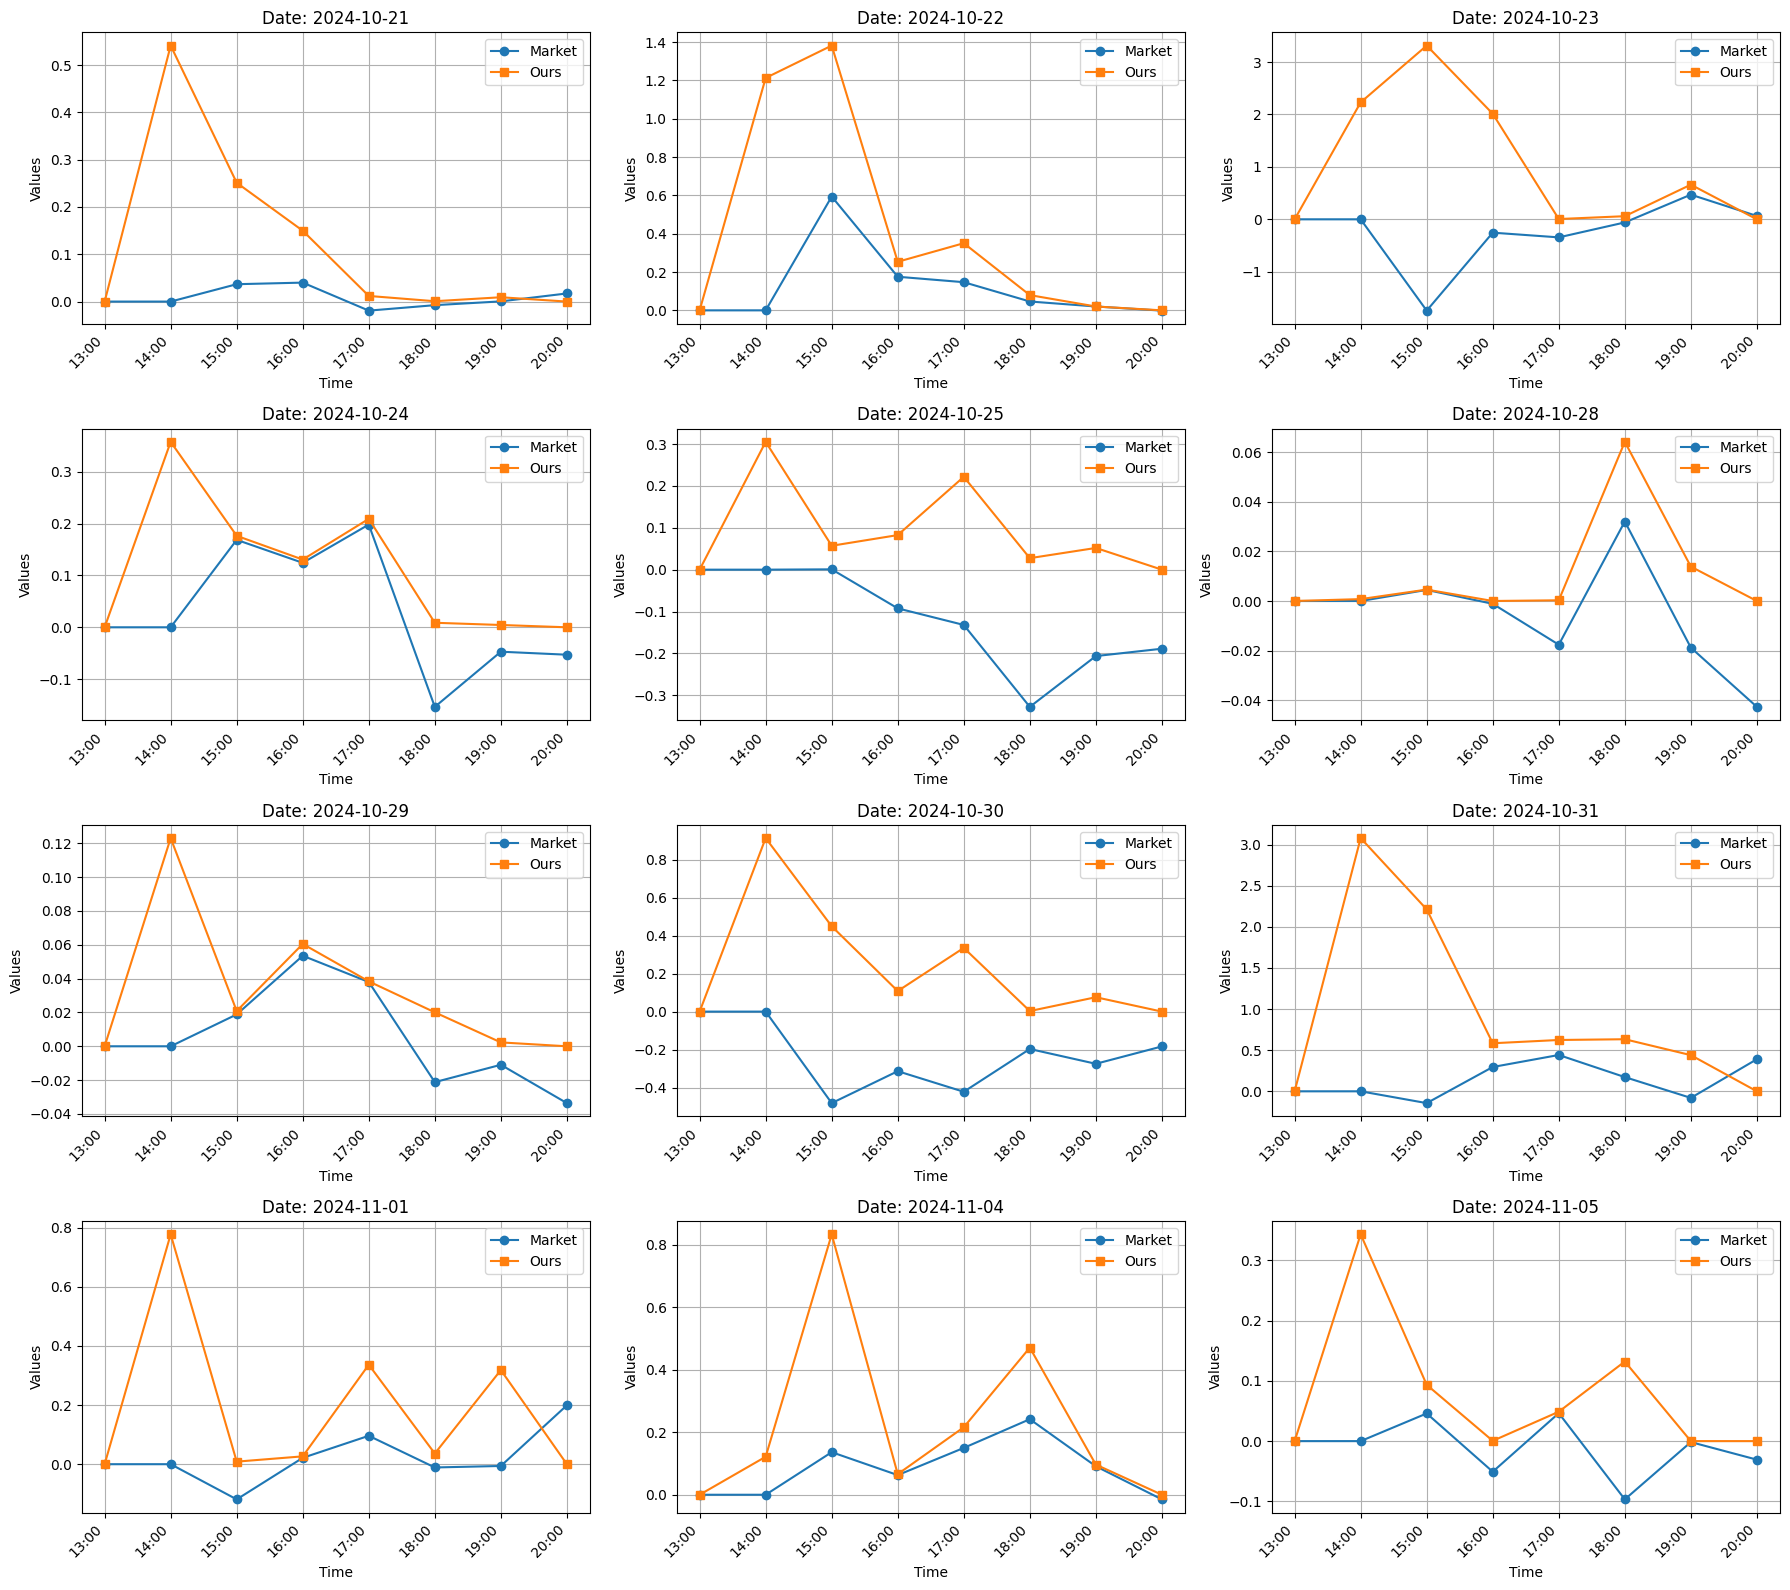

In [119]:
import matplotlib.dates as mdates

res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:12]

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(first_6_days)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Prepare for plotting
num_days = len(first_6_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot the time series
for i, date in enumerate(first_6_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting
    ax = axes[i]
    ax.plot(day_data['ts_event'], day_data['myopic_market_obj'], label='Market', marker='o')
    ax.plot(day_data['ts_event'], day_data['myopic_opt_obj'], label='Ours', marker='s')
    
    # Formatting the x-axis to show time only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Time')
    ax.set_ylabel('Values')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)
    
    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots if there are any
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


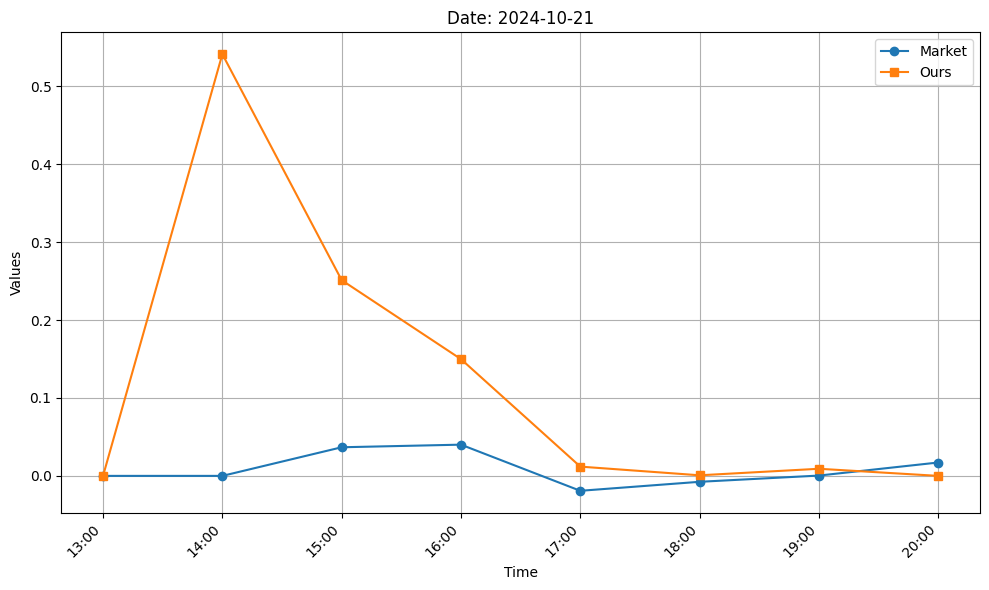

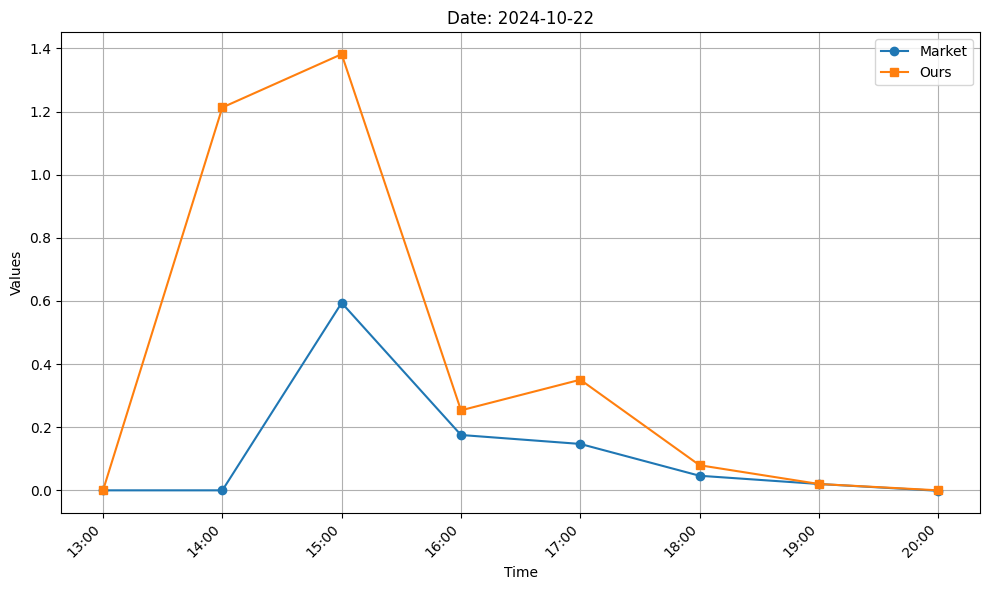

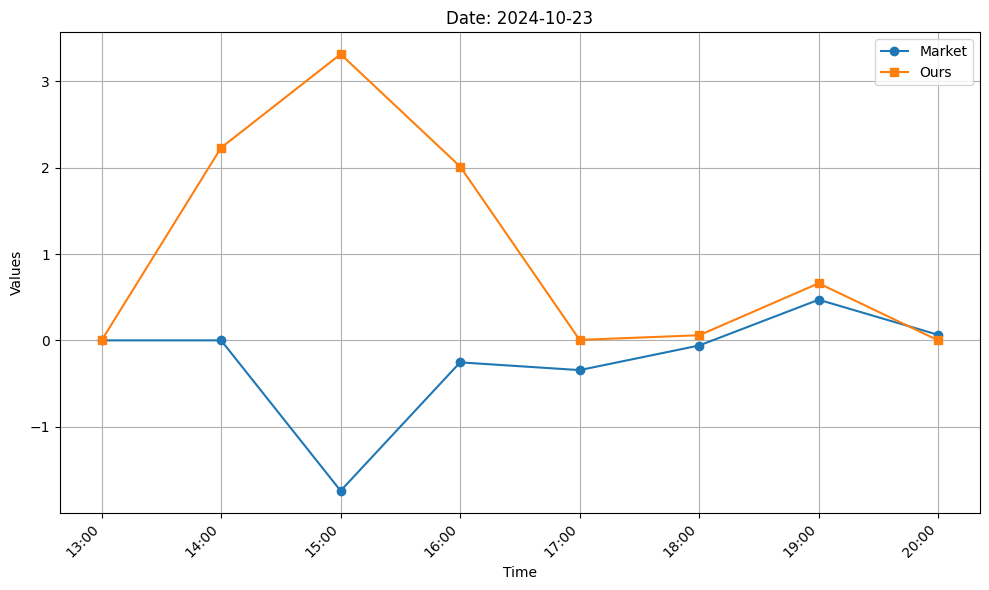

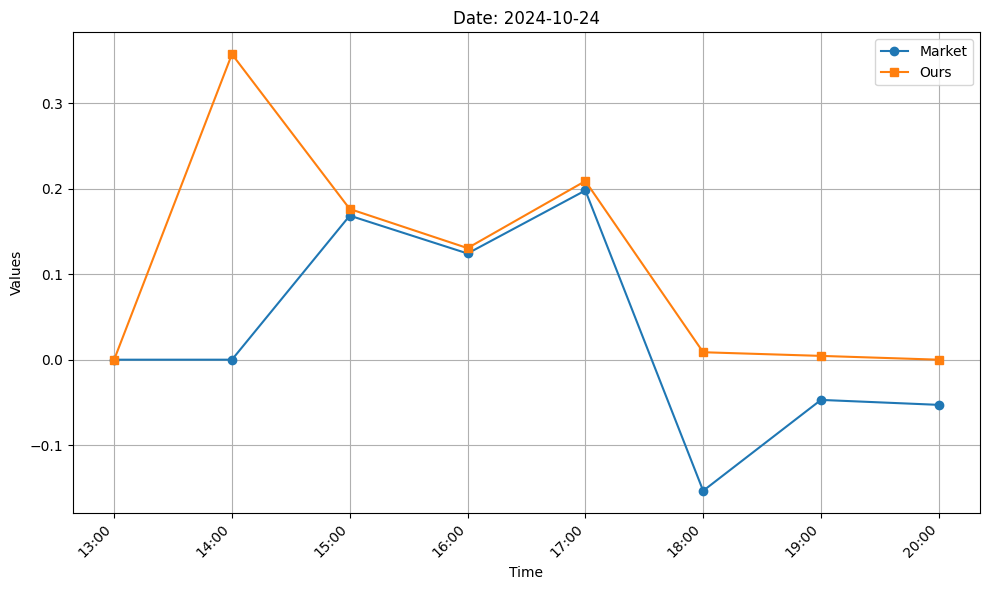

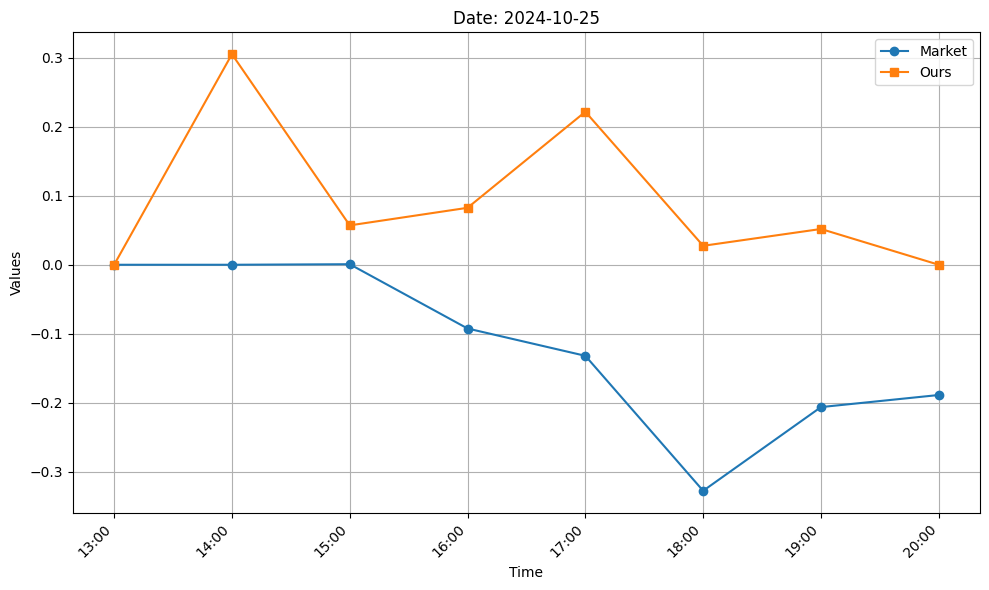

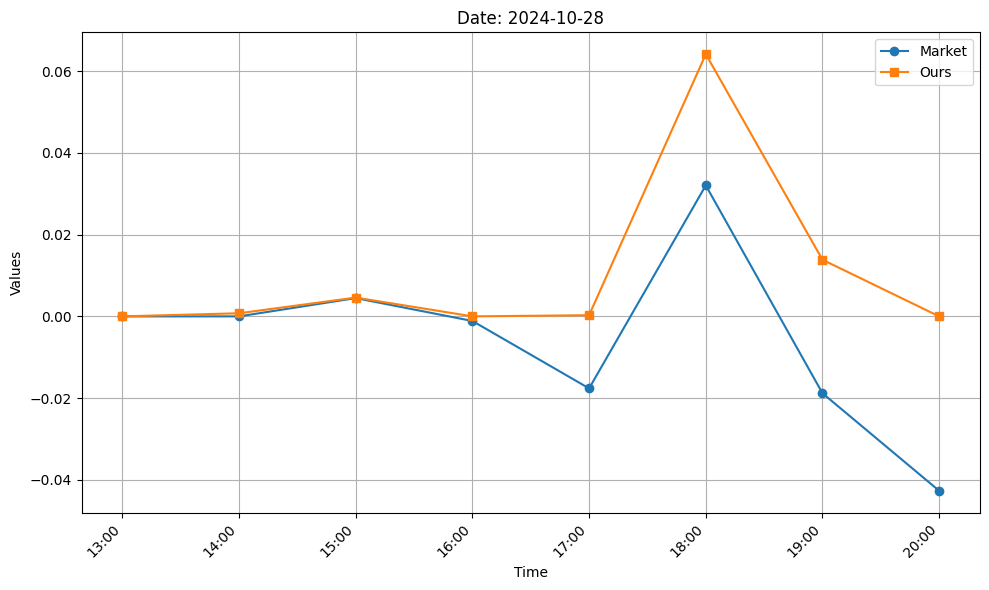

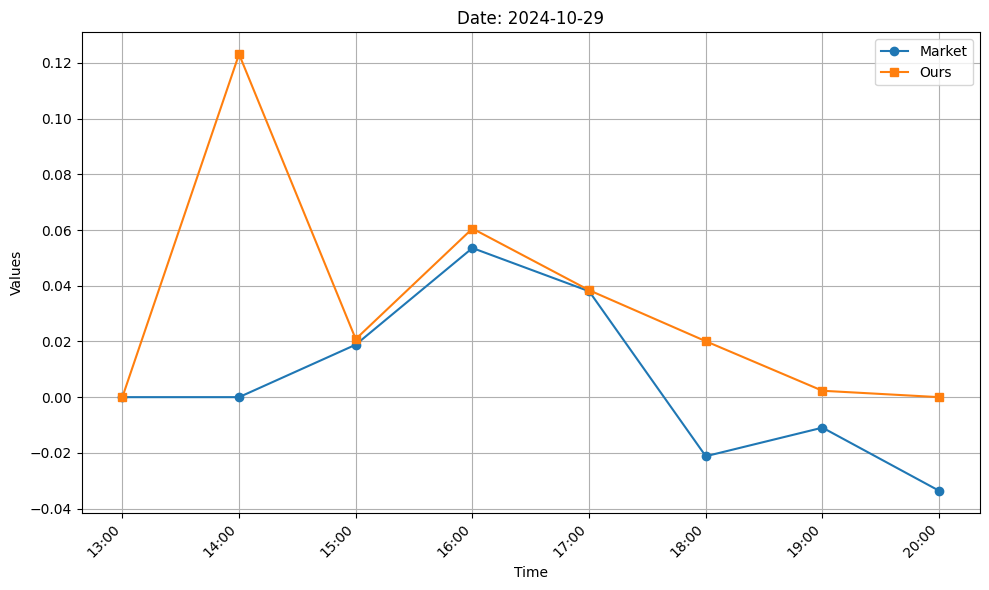

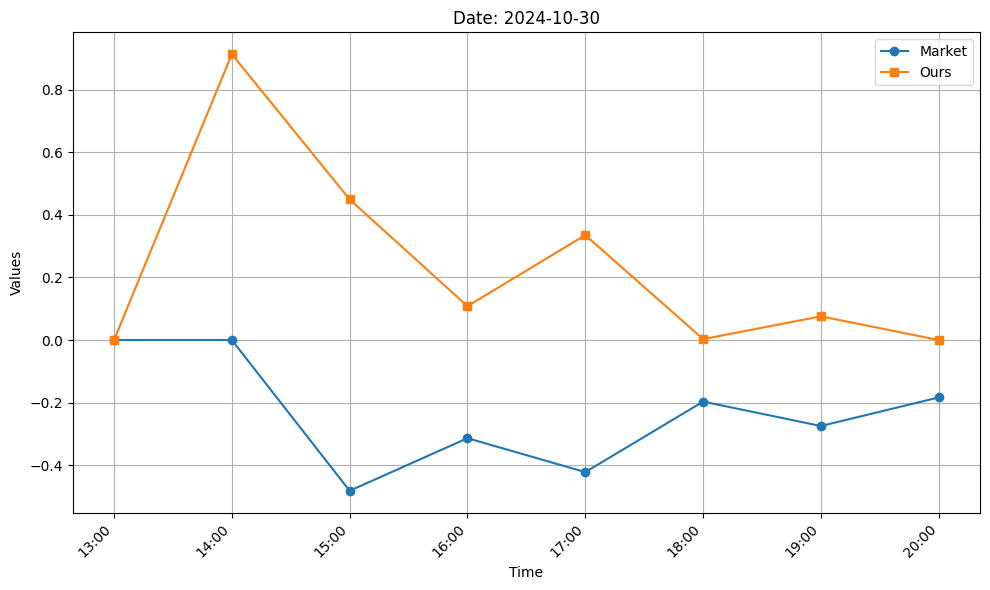

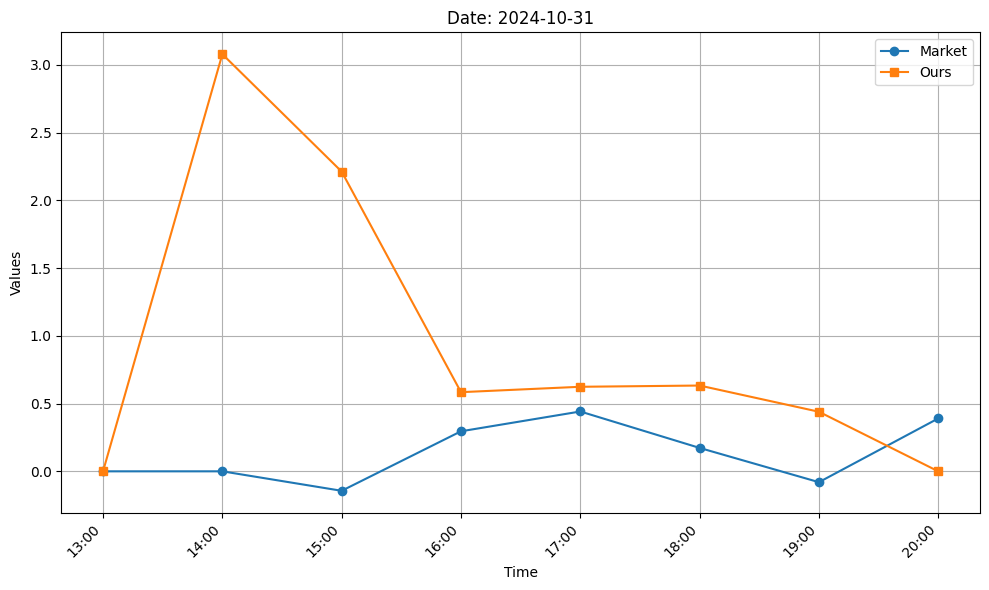

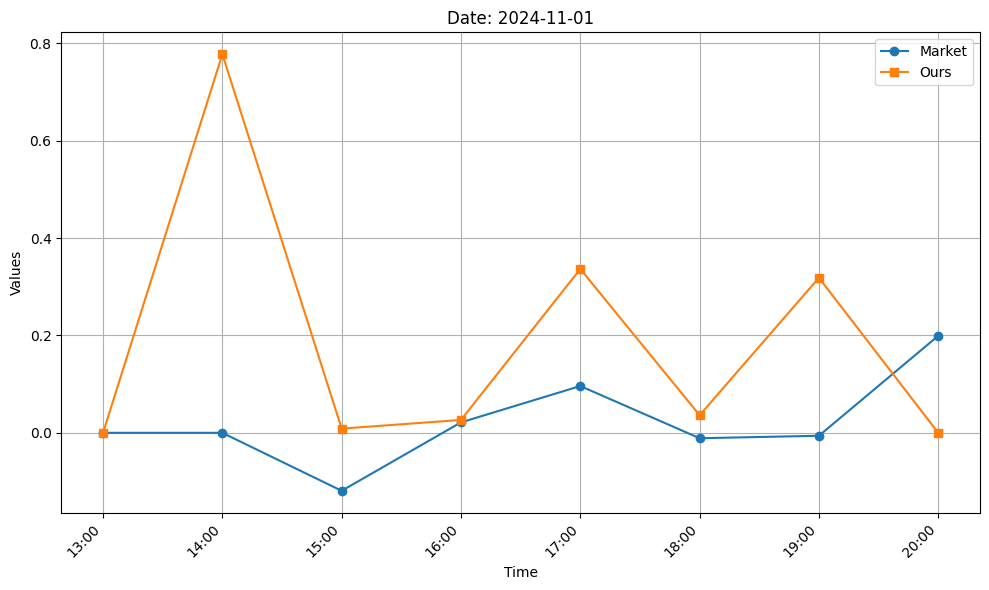

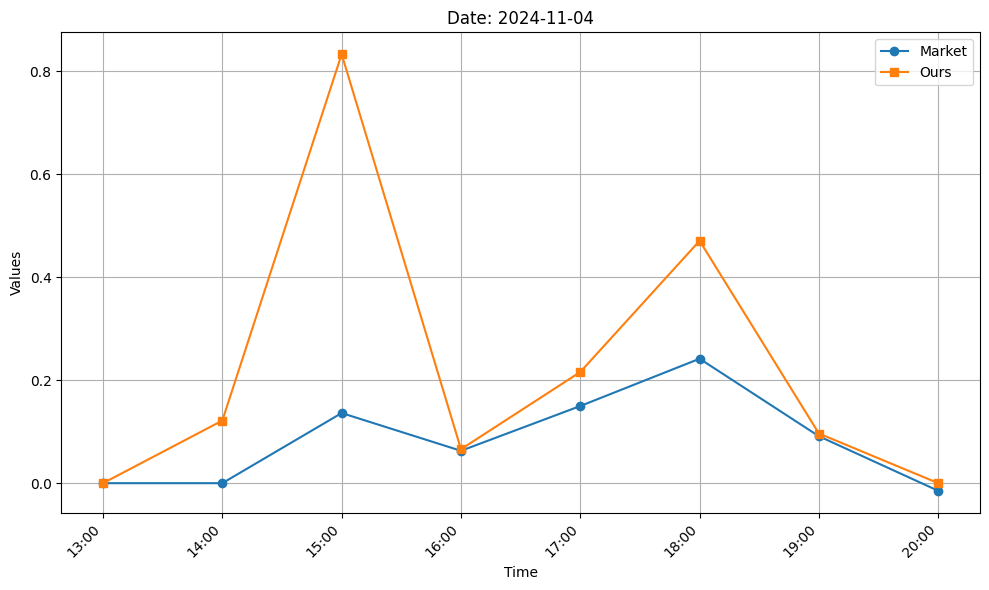

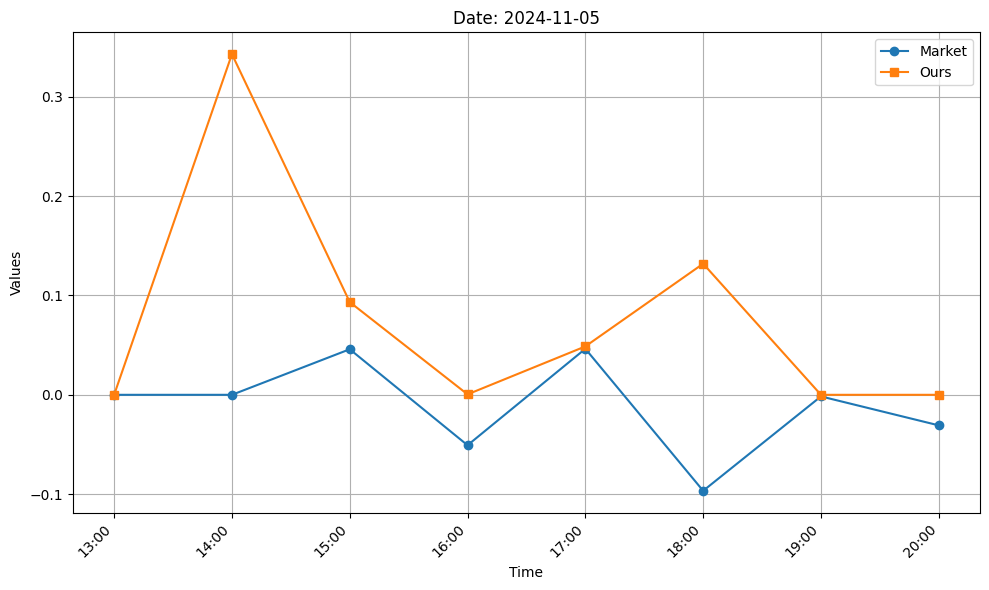

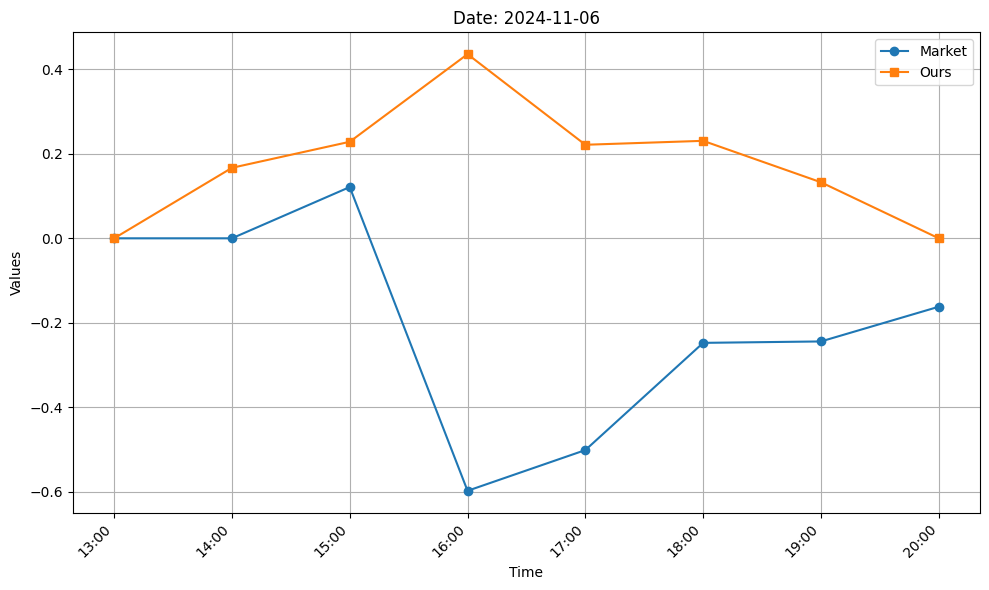

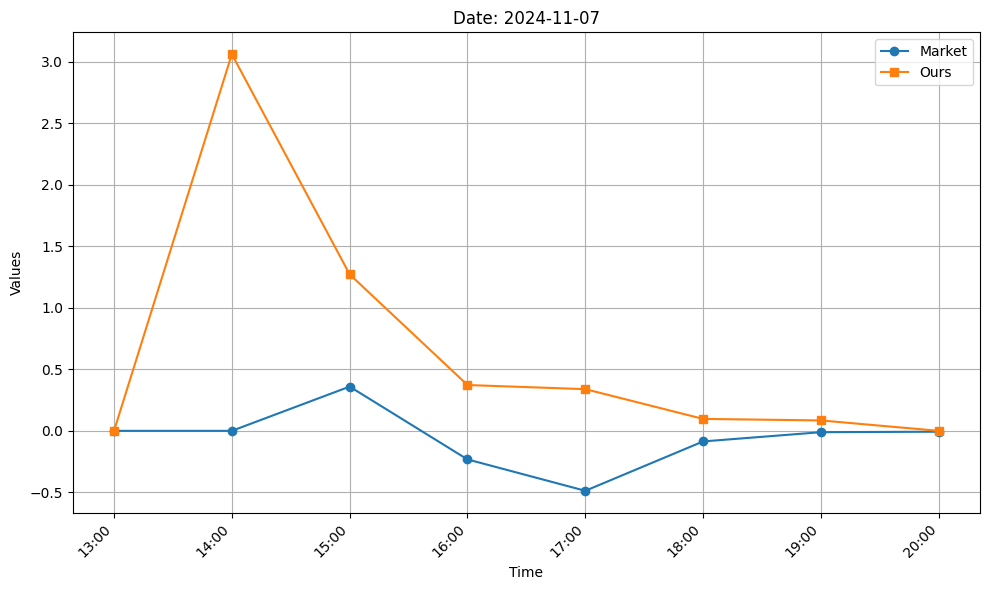

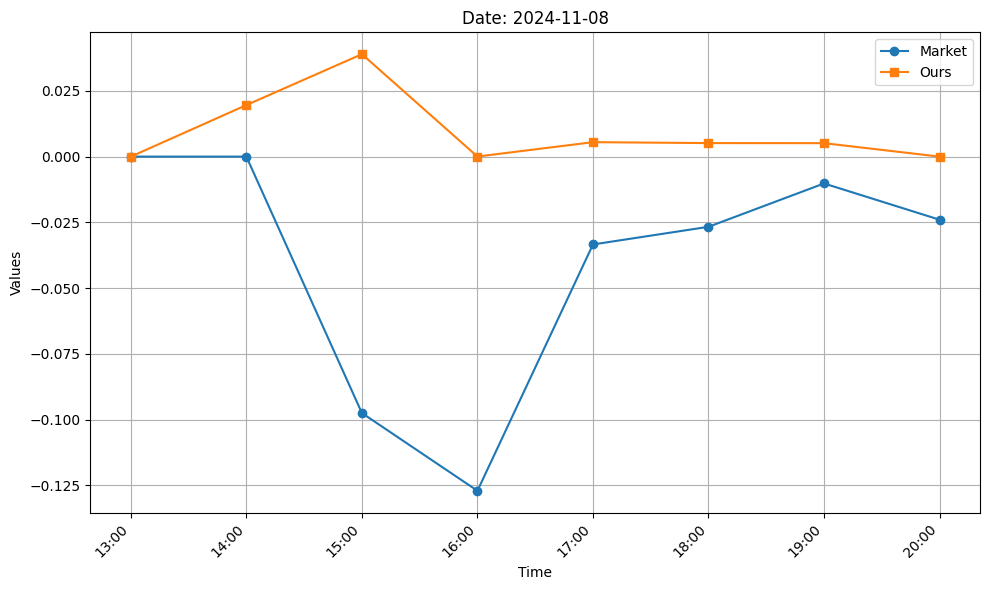

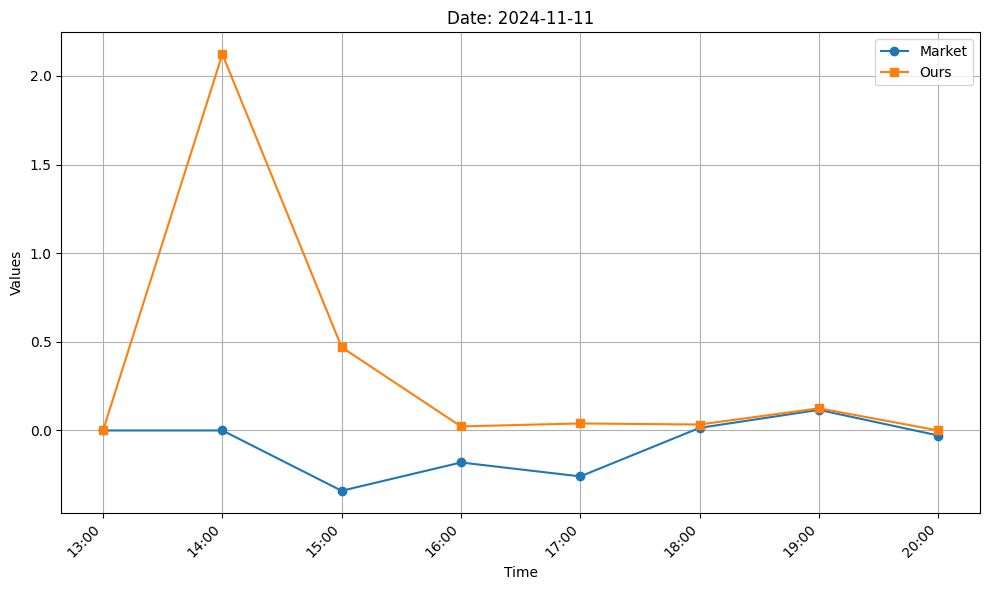

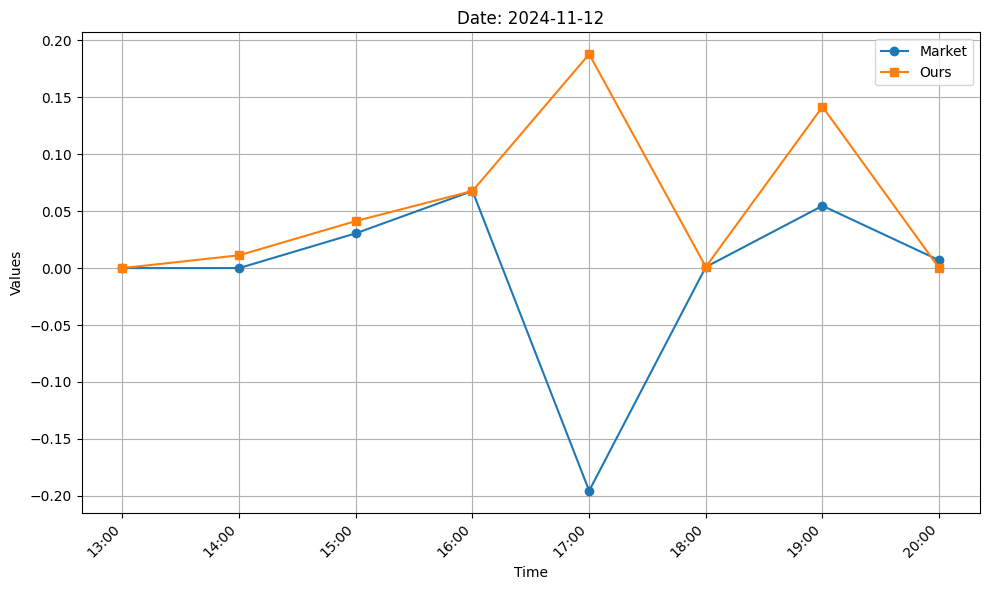

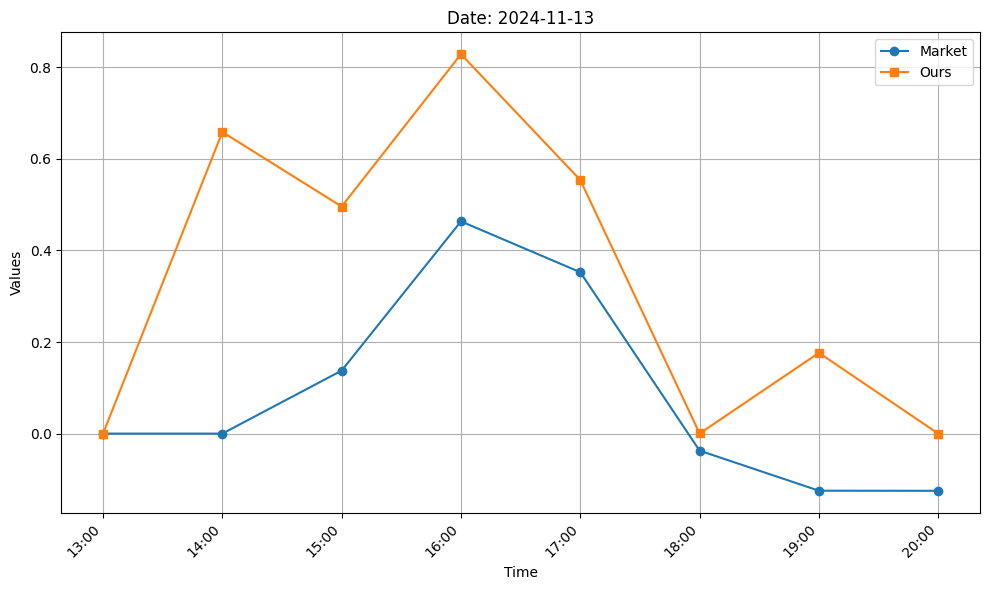

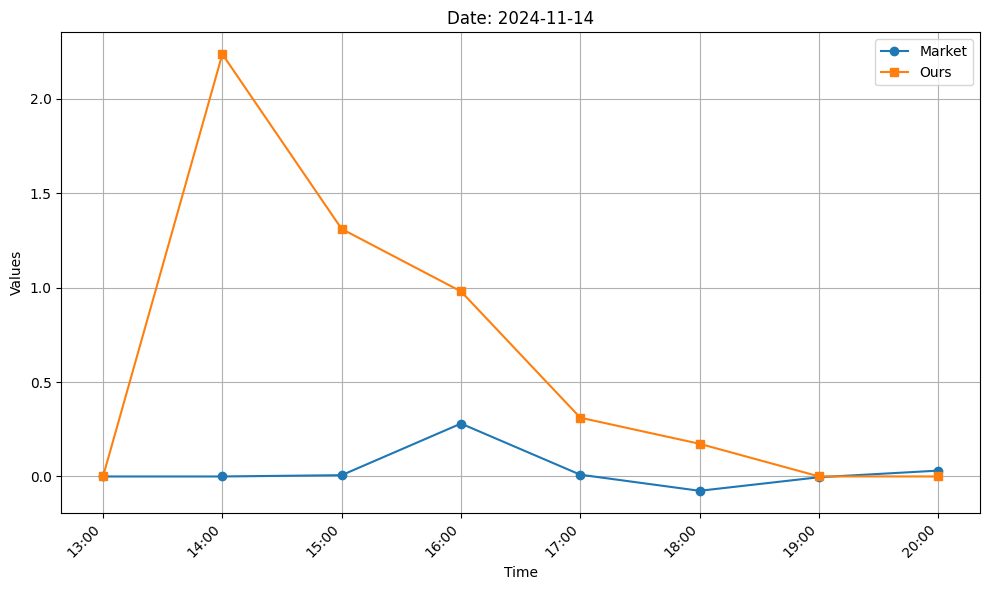

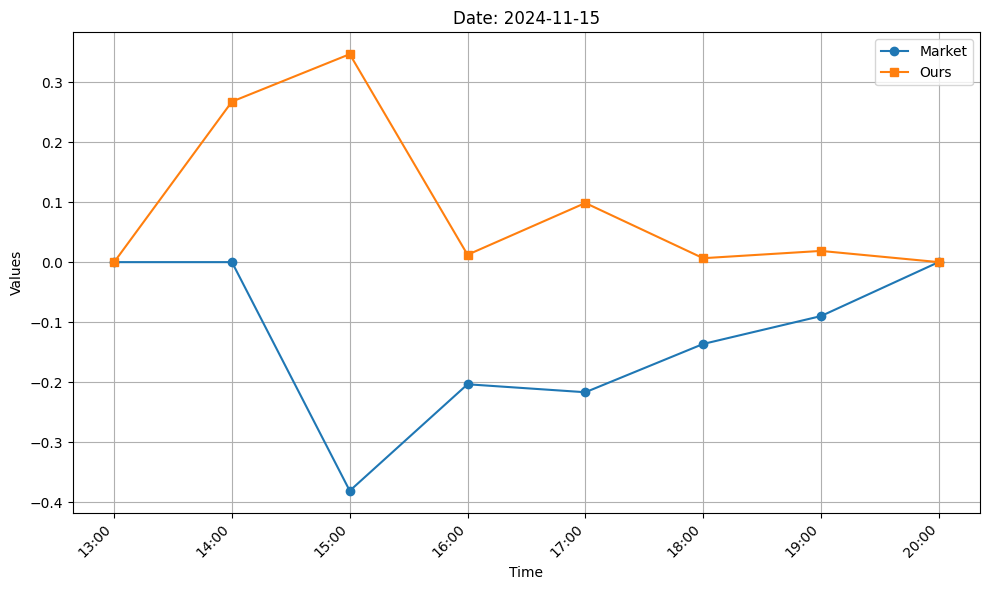

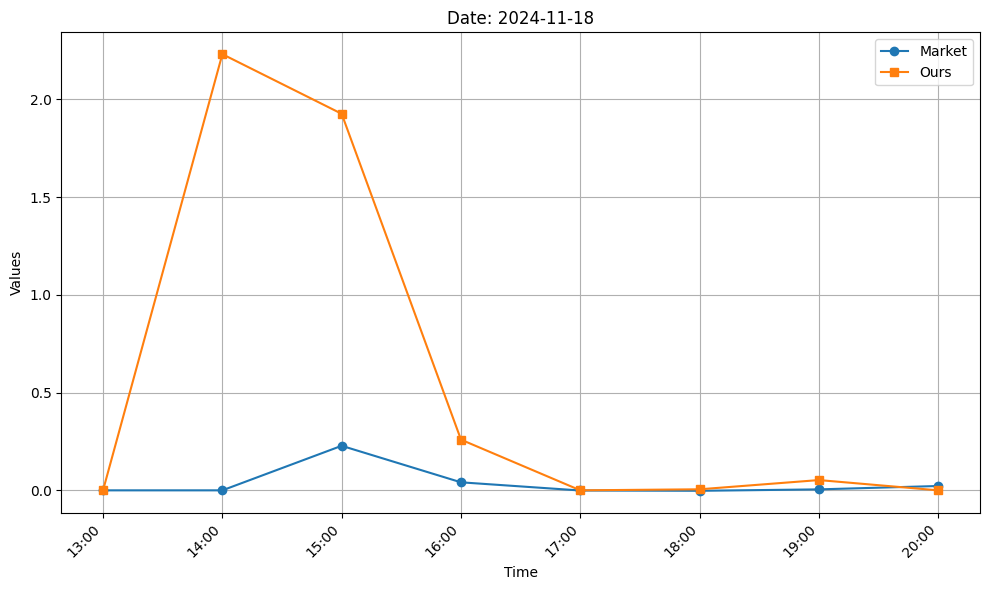

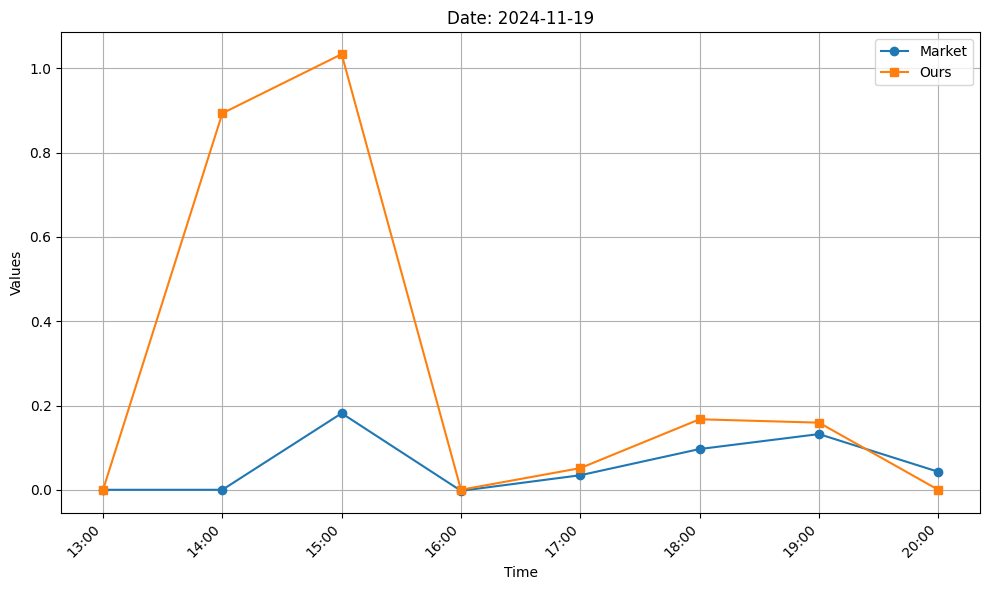

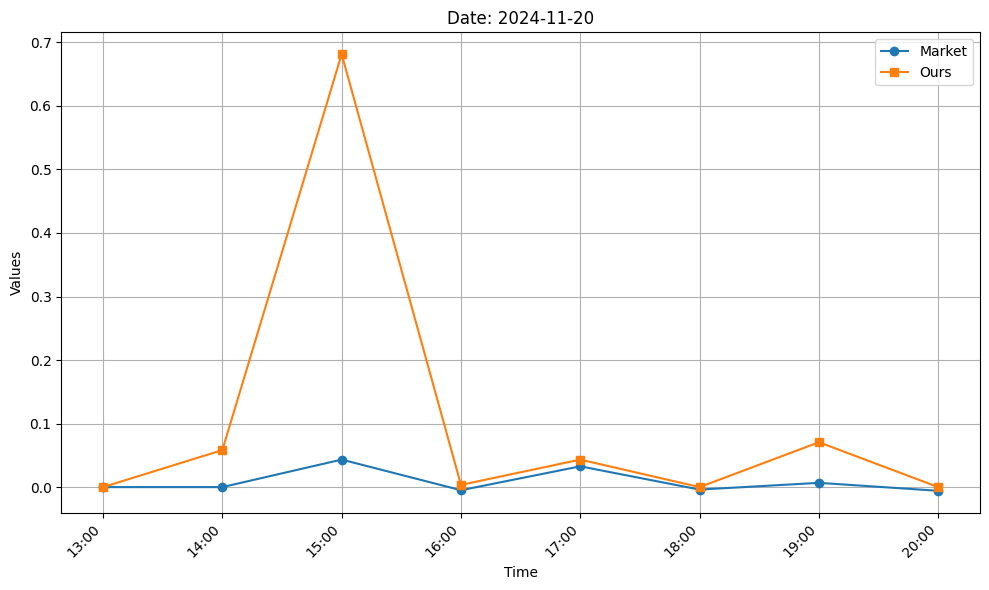

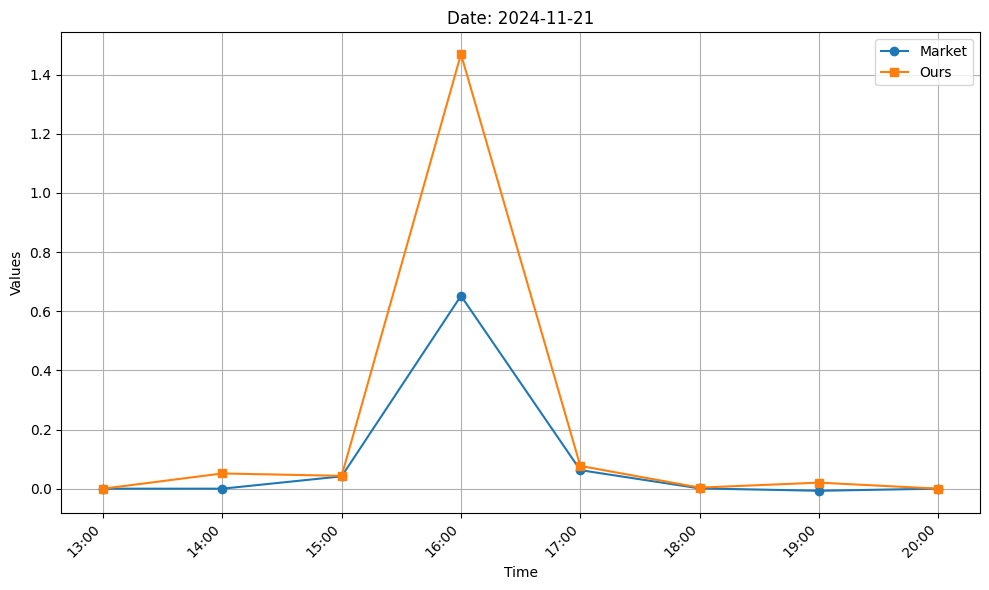

In [120]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Convert ts_event to datetime and extract the date
res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:6]  # Adjust to first 6 days

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(unique_dates)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Loop over each day and plot the time series
for date in unique_dates:
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Create a new figure for each day
    plt.figure(figsize=(10, 6))
    
    # Plot the data
    plt.plot(day_data['ts_event'], day_data['myopic_market_obj'], label='Market', marker='o')
    plt.plot(day_data['ts_event'], day_data['myopic_opt_obj'], label='Ours', marker='s')
    
    # Formatting the x-axis to show time only
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title(f'Date: {date}')
    plt.legend()
    plt.grid(True)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()


In [121]:
diff = []
for date in unique_dates:
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    
    temp = day_data["myopic_opt_obj"] - day_data["myopic_market_obj"]

    diff.append(temp)
    

In [122]:
diff[0]

0    0.000000
1    0.541156
2    0.214427
3    0.109727
4    0.031023
5    0.008349
6    0.008721
7   -0.017167
dtype: float64

In [123]:
count = 0
for i in range(len(diff)):
    for idx,val in enumerate(diff[i]):
        if val == 0:
            count += 1
            print(f"Index : {i},{idx}")
print(count)

Index : 0,0
Index : 1,0
Index : 2,0
Index : 3,0
Index : 4,0
Index : 5,0
Index : 6,0
Index : 7,0
Index : 8,0
Index : 9,0
Index : 10,0
Index : 11,0
Index : 12,0
Index : 13,0
Index : 14,0
Index : 15,0
Index : 16,0
Index : 17,0
Index : 18,0
Index : 19,0
Index : 20,0
Index : 21,0
Index : 22,0
Index : 23,0
24


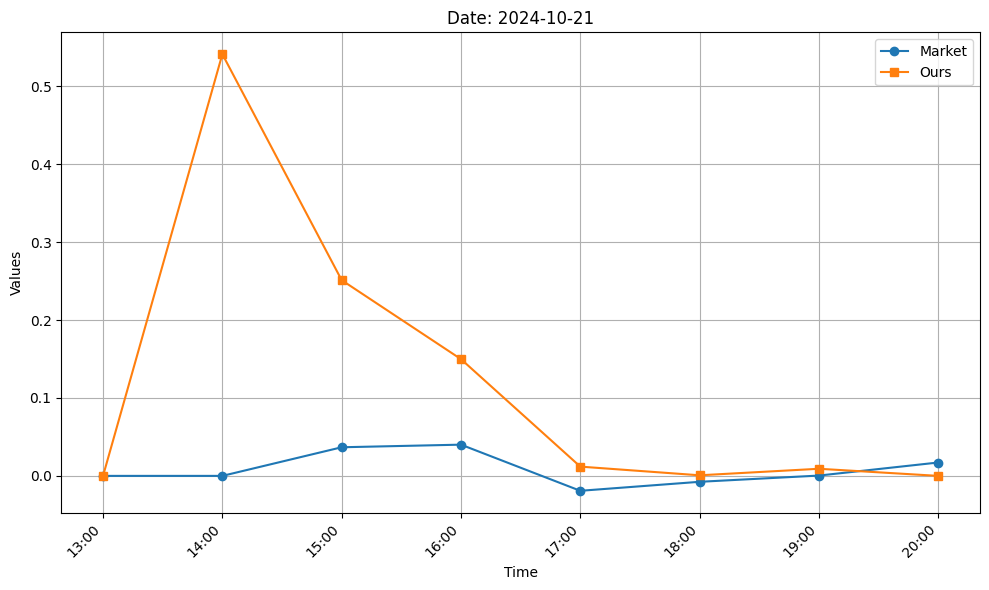

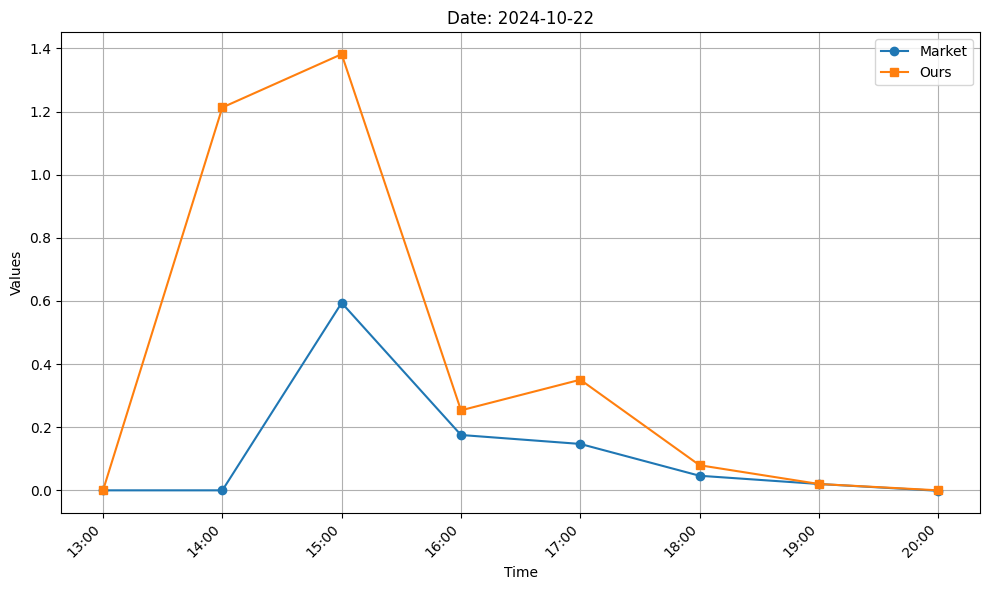

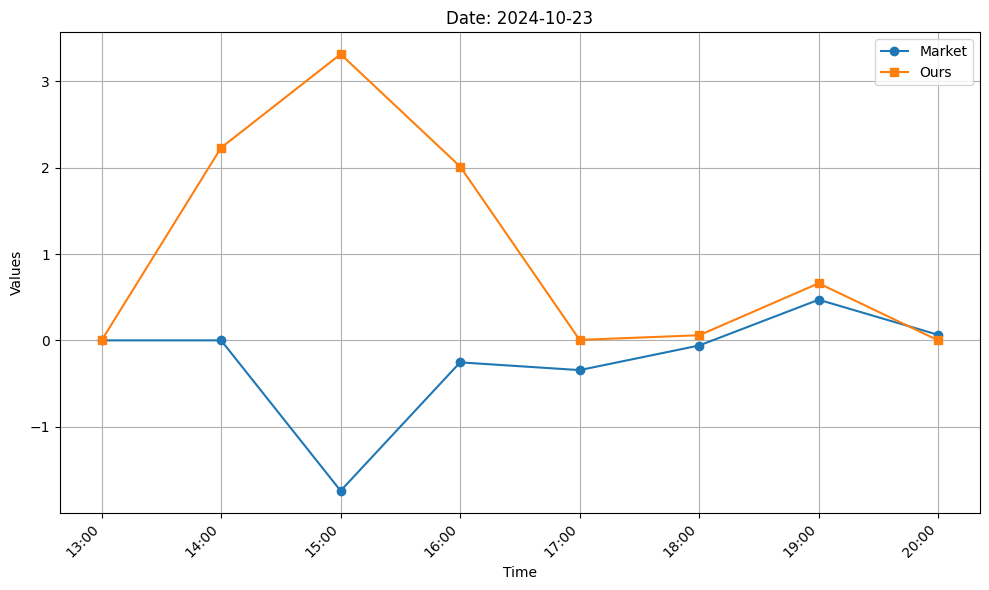

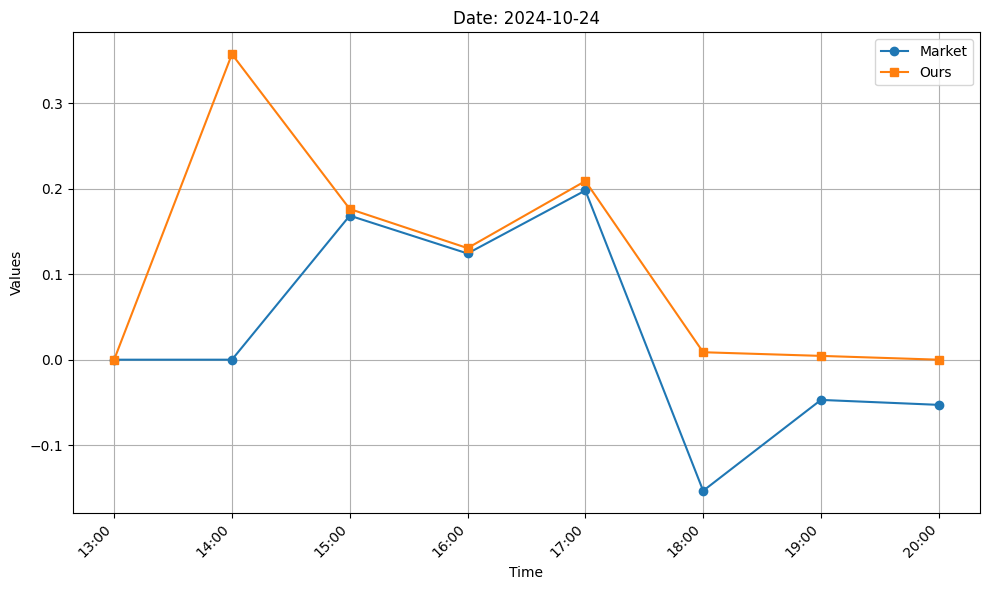

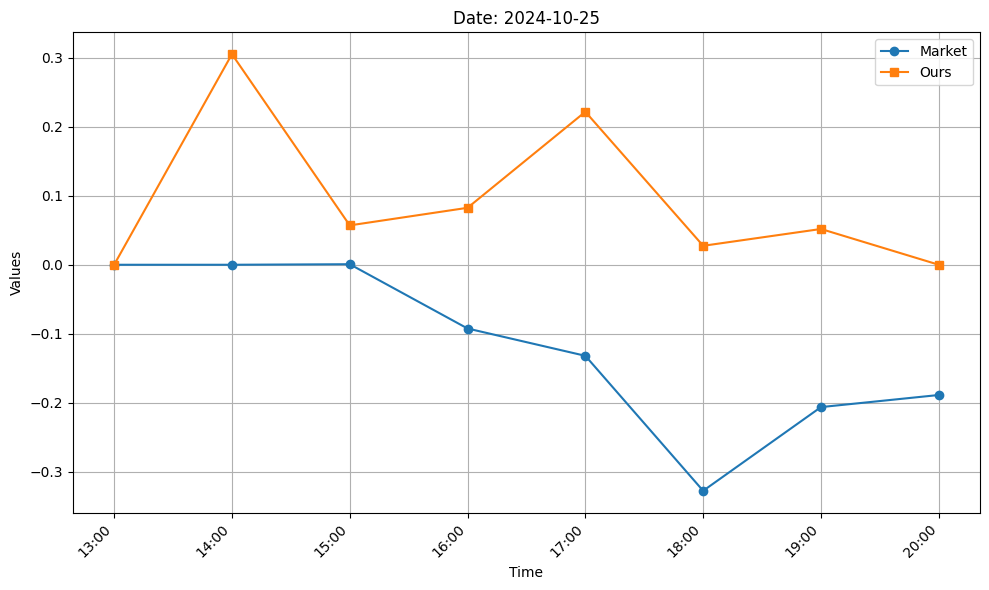

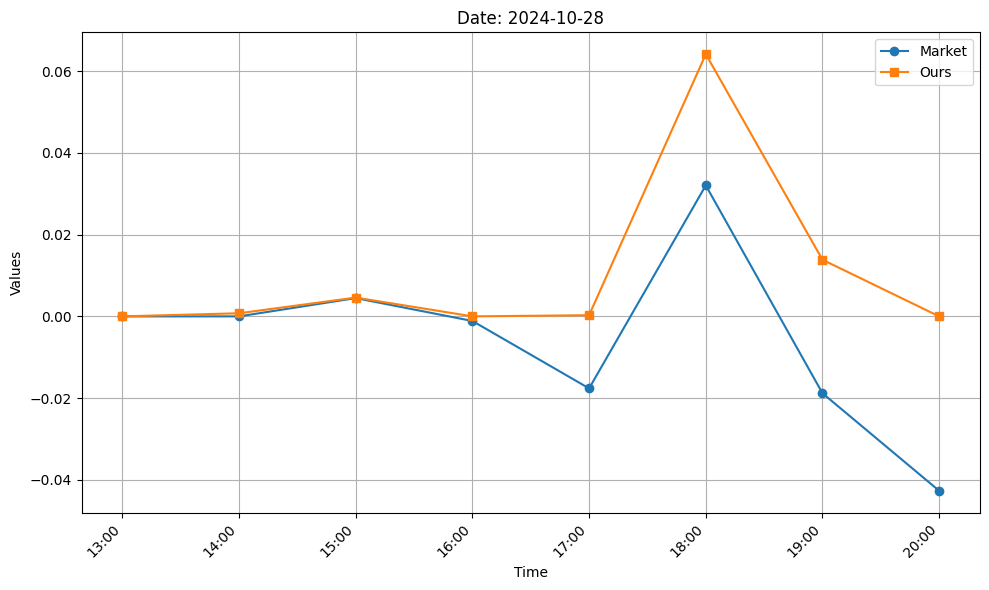

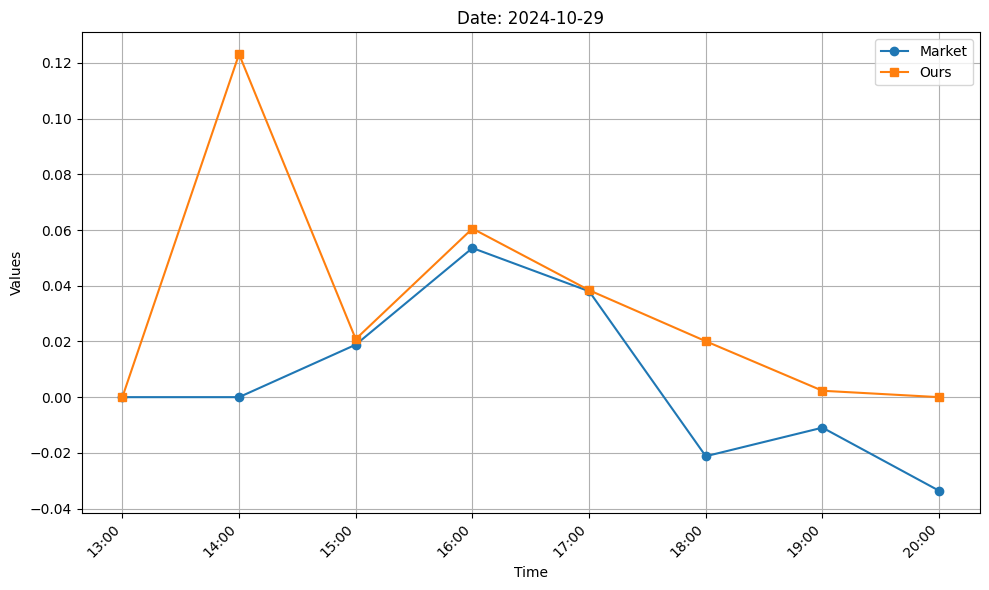

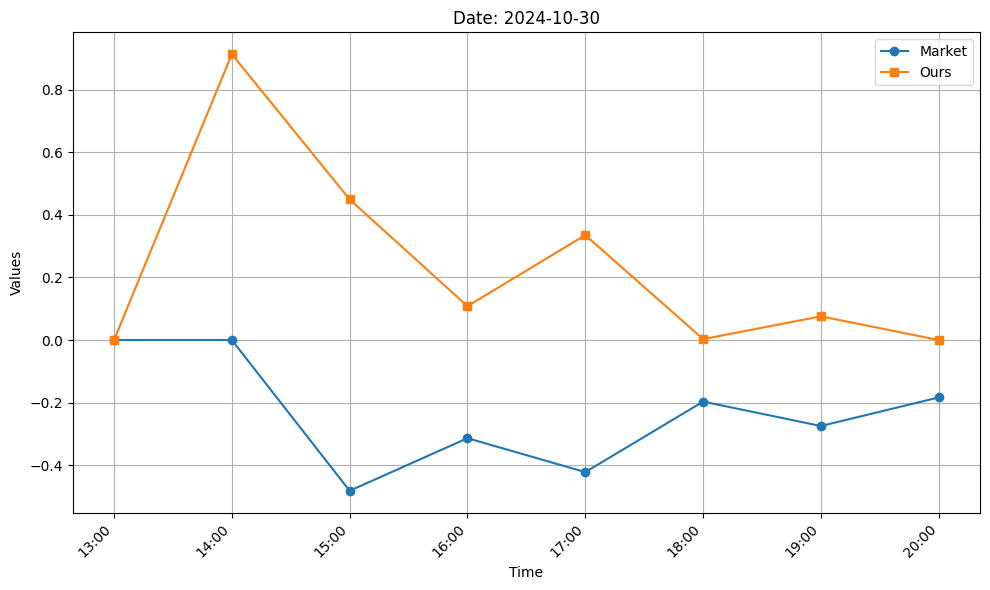

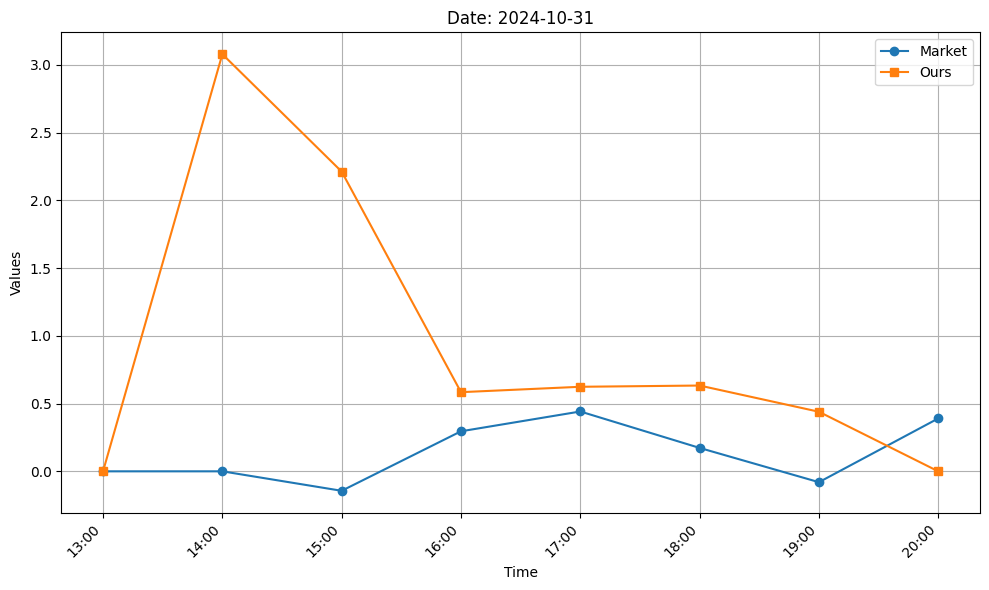

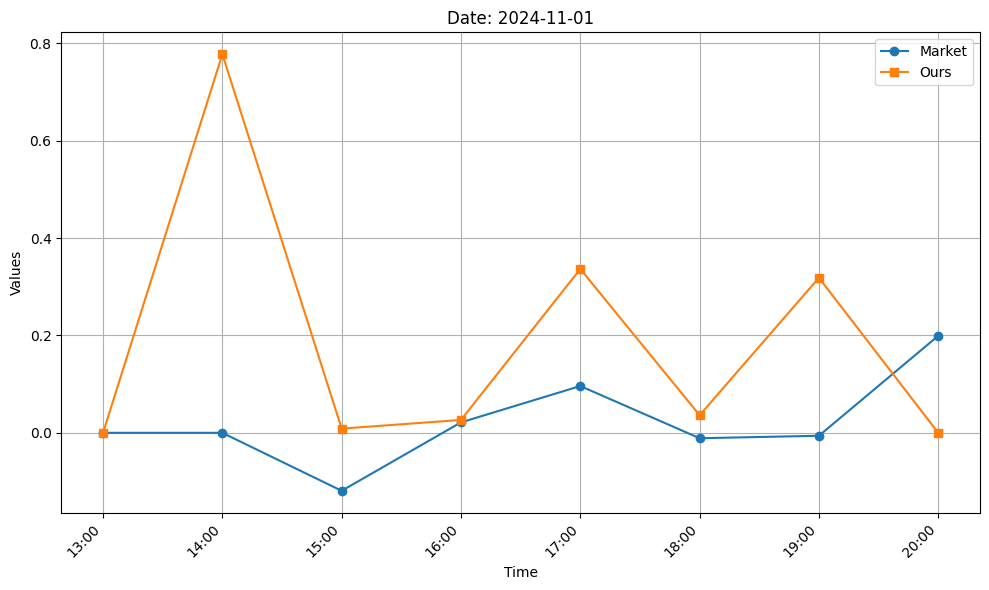

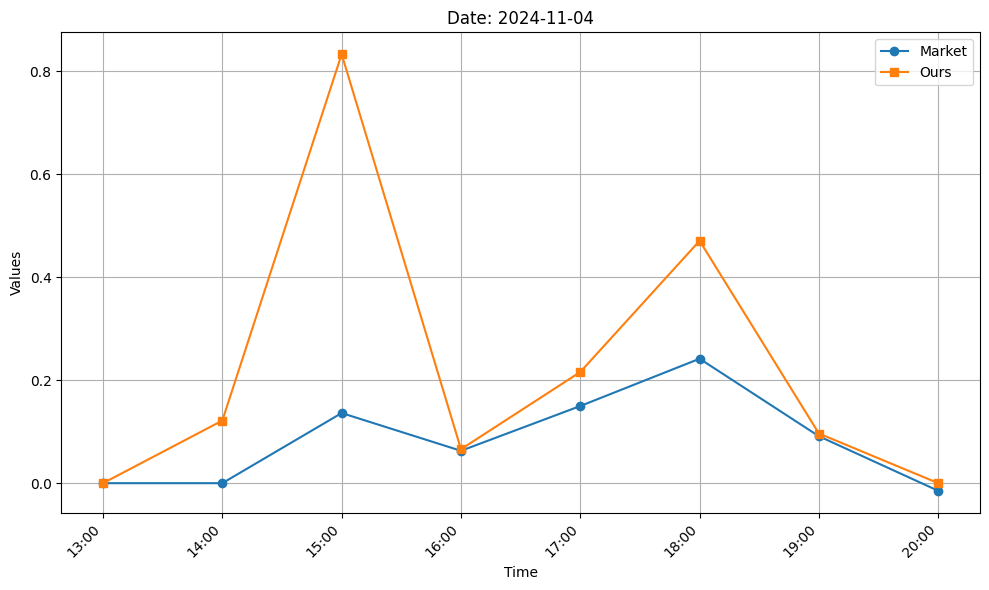

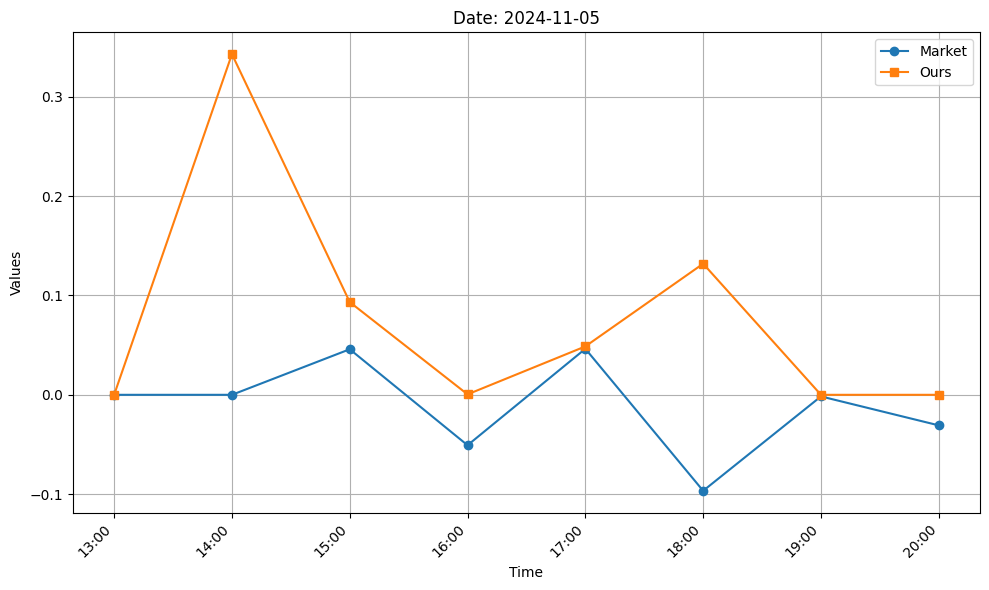

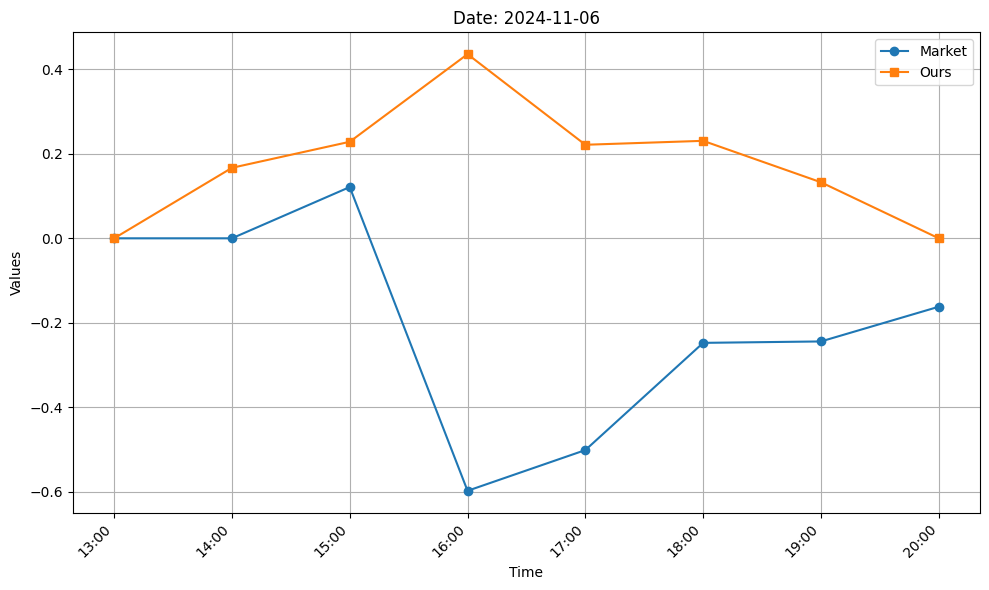

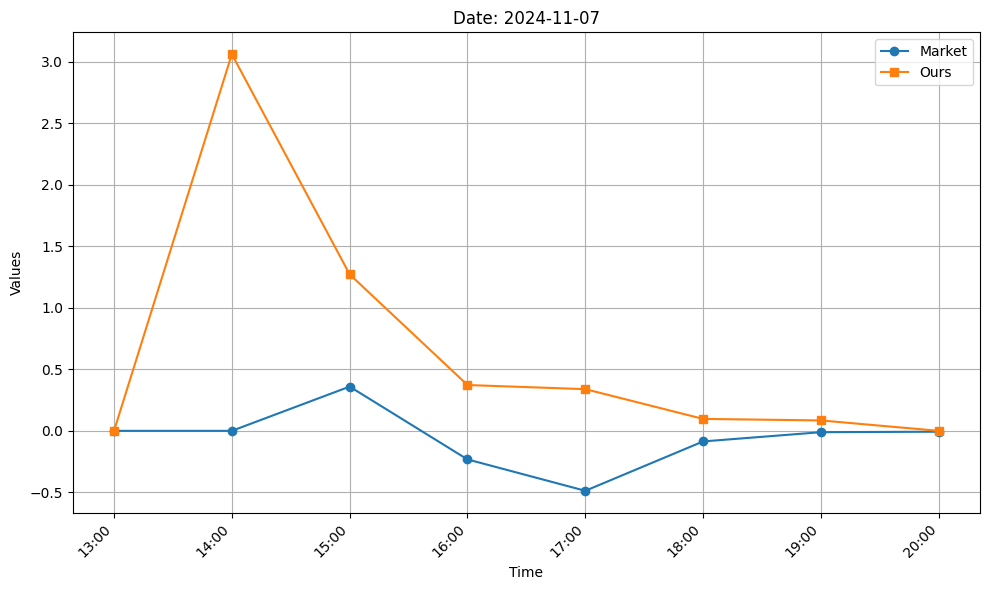

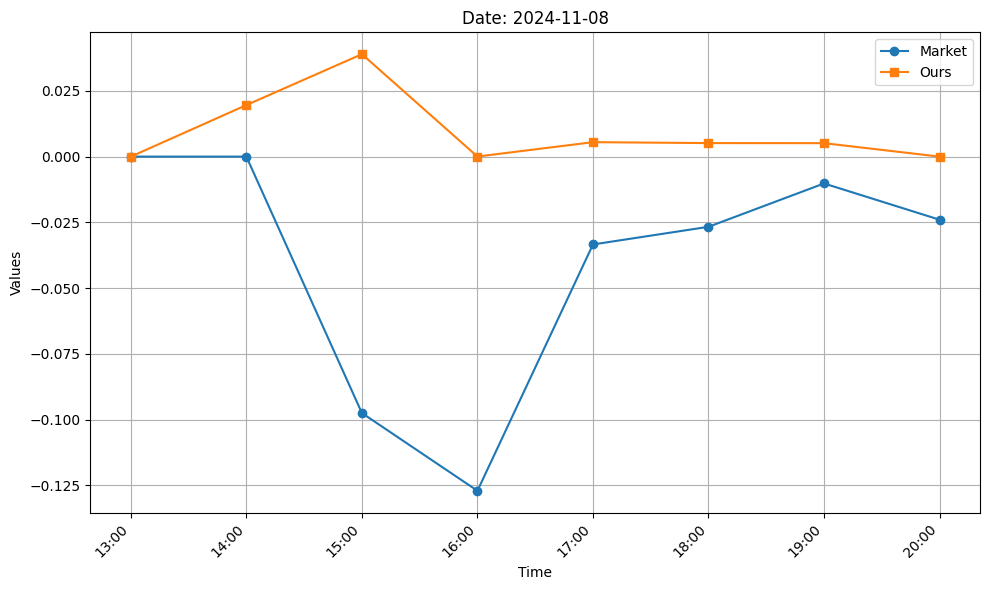

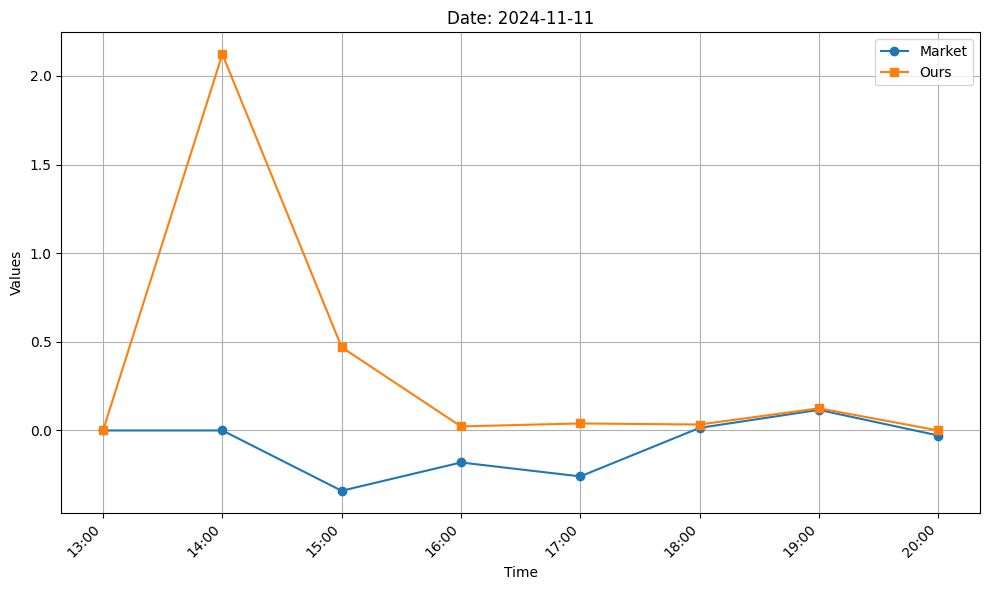

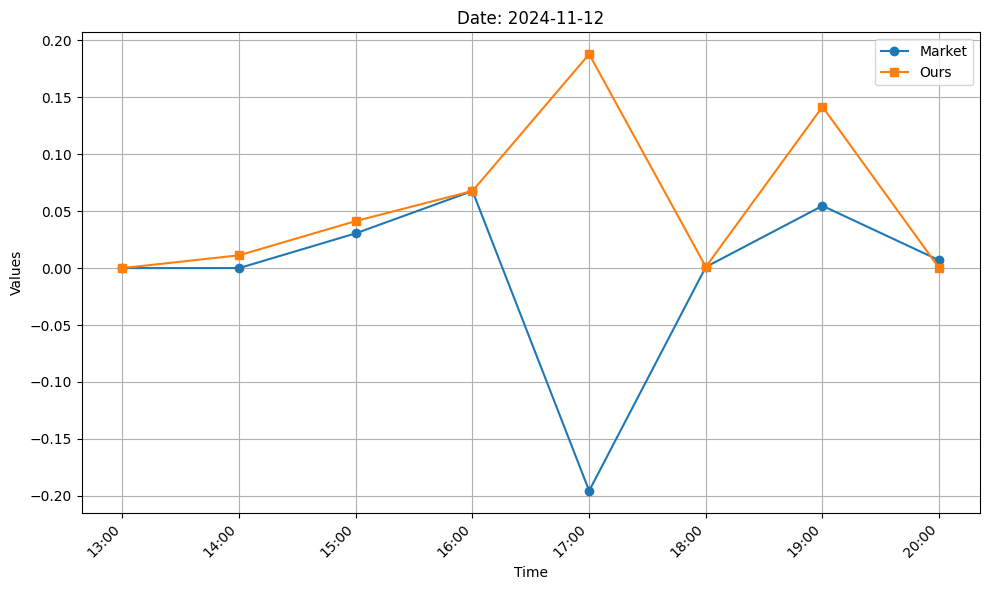

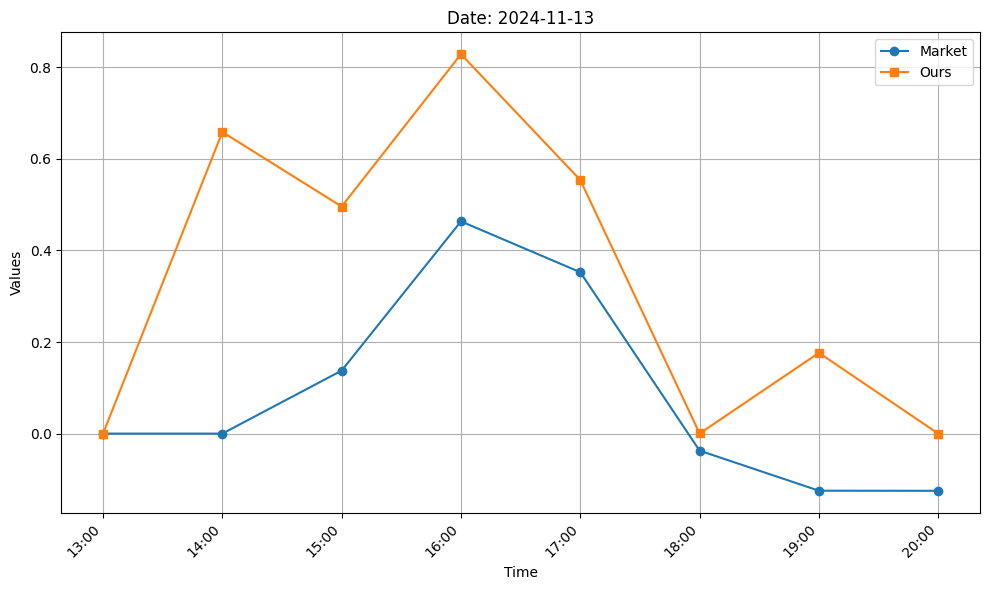

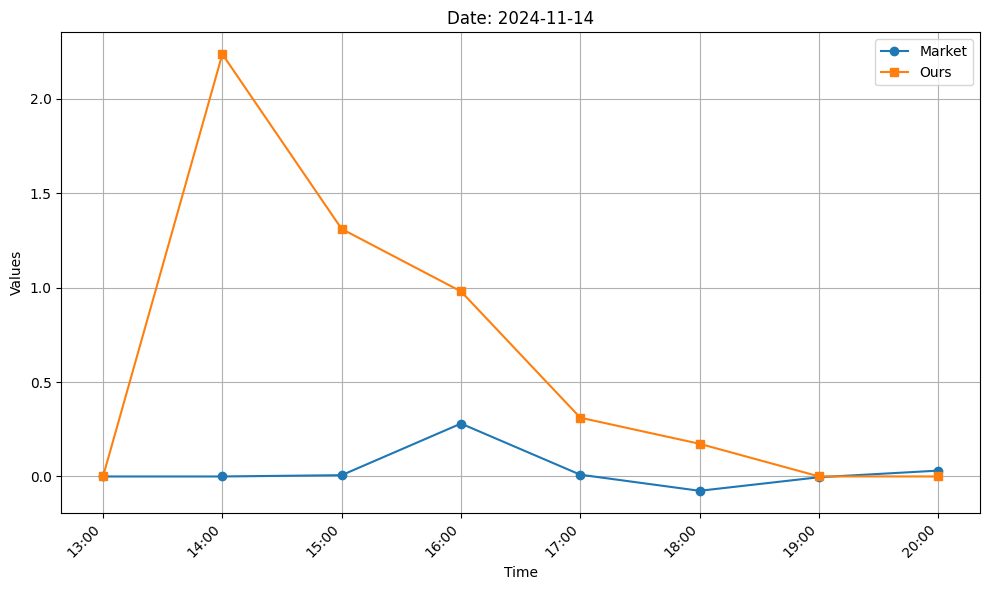

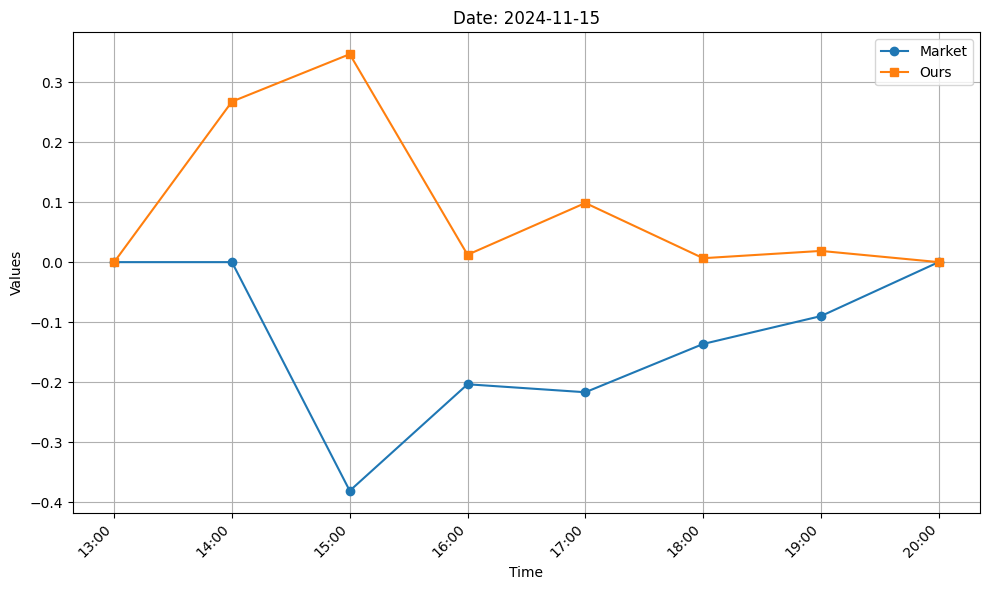

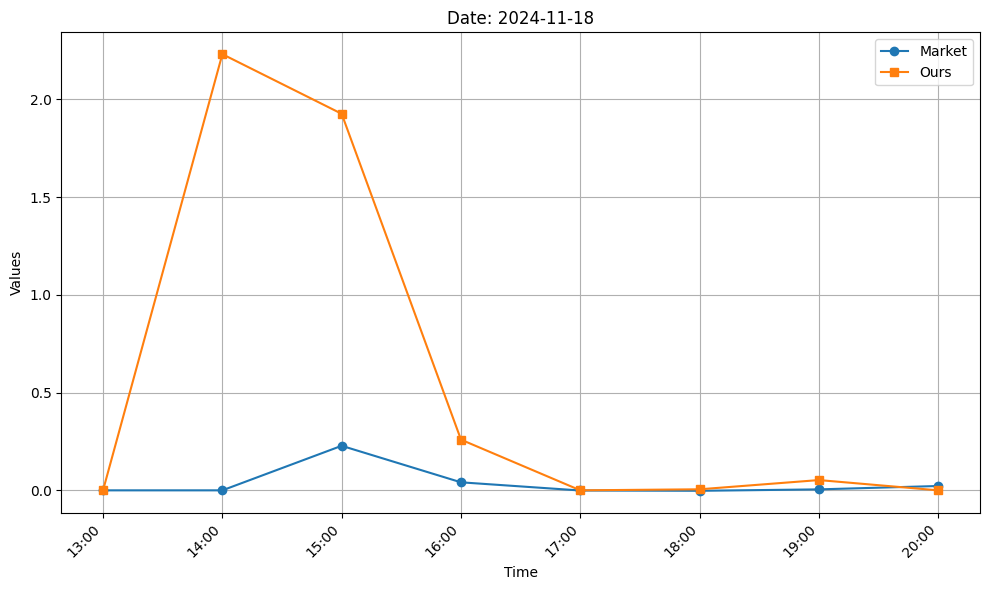

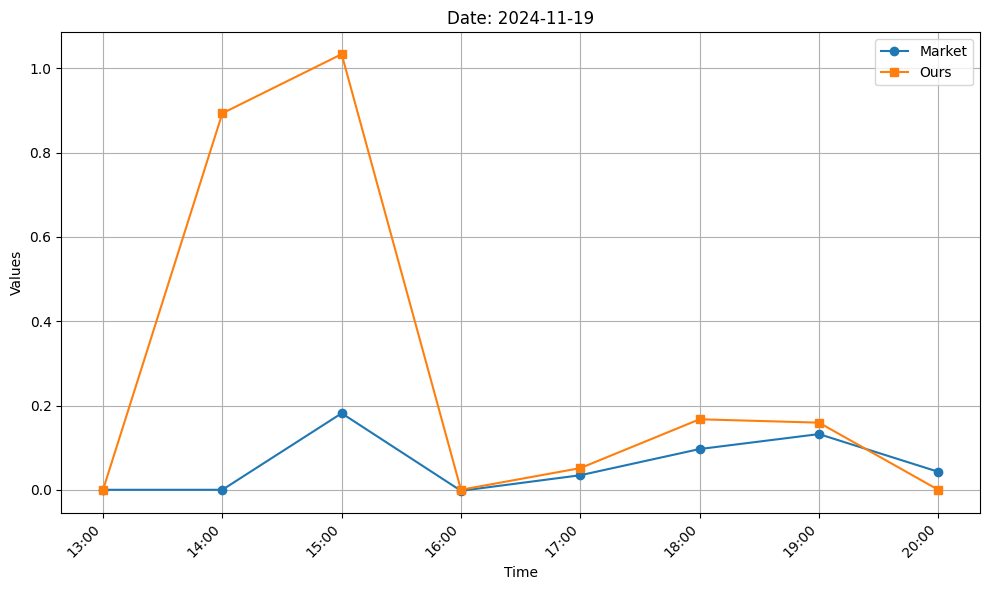

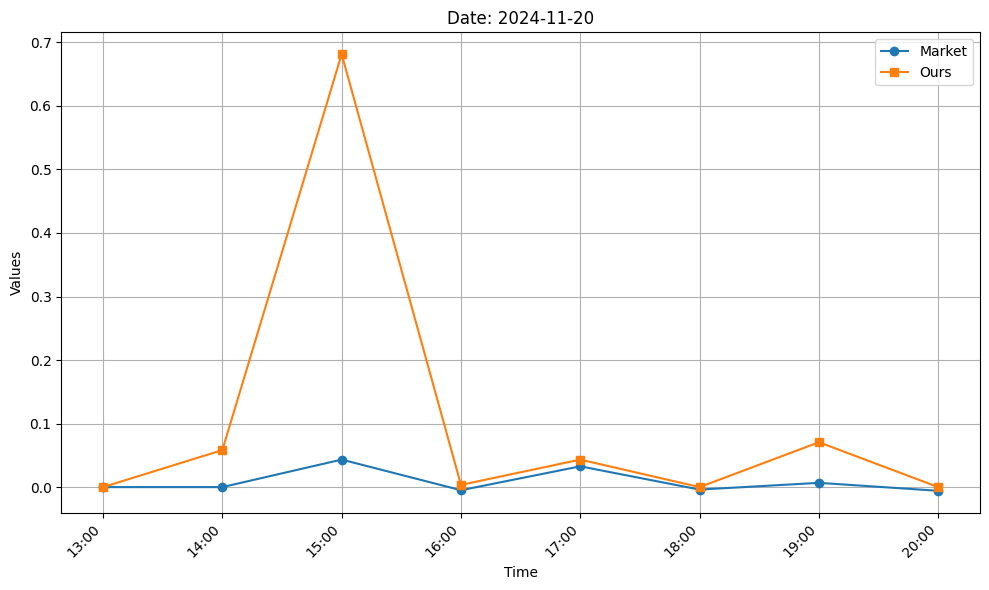

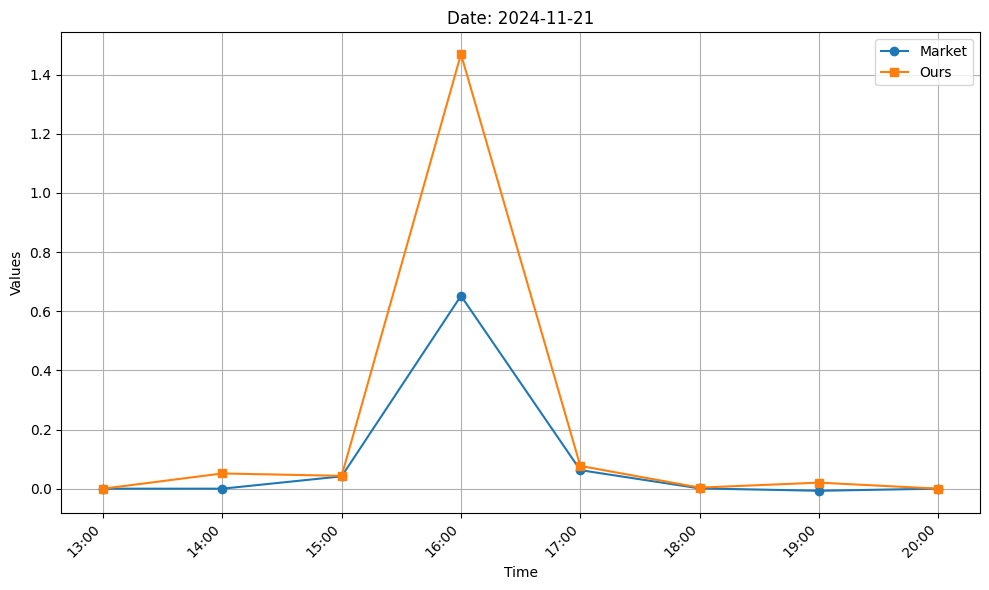

In [124]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Convert ts_event to datetime and extract the date
res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:6]  # Adjust to first 6 days

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(unique_dates)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Loop over each day and plot the time series
for date in unique_dates:
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Create a new figure for each day
    plt.figure(figsize=(10, 6))
    
    # Plot the data
    plt.plot(day_data['ts_event'], day_data['myopic_market_obj'], label='Market', marker='o')
    plt.plot(day_data['ts_event'], day_data['myopic_opt_obj'], label='Ours', marker='s')
    
    # Formatting the x-axis to show time only
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title(f'Date: {date}')
    plt.legend()
    plt.grid(True)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()


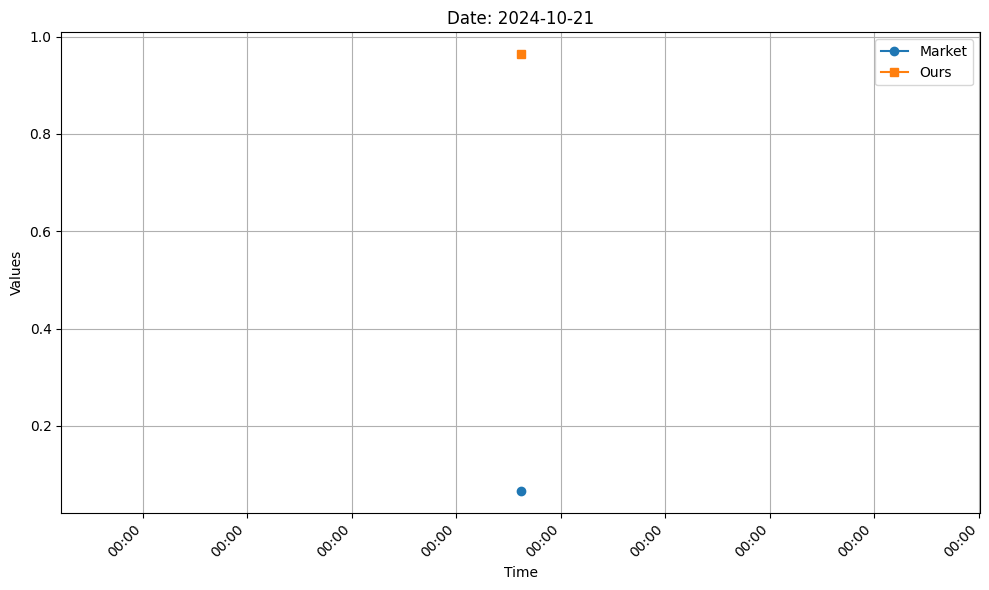

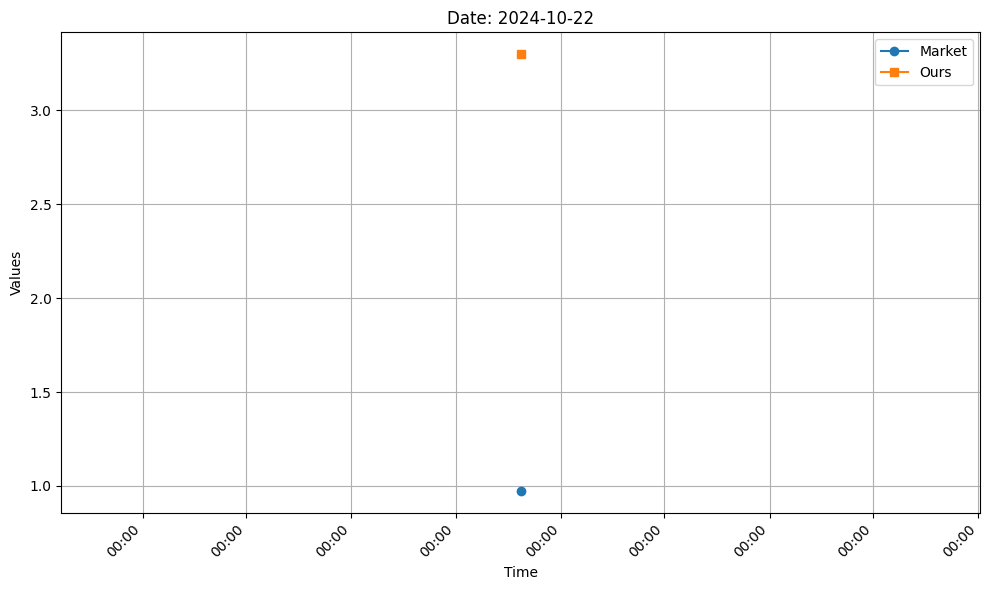

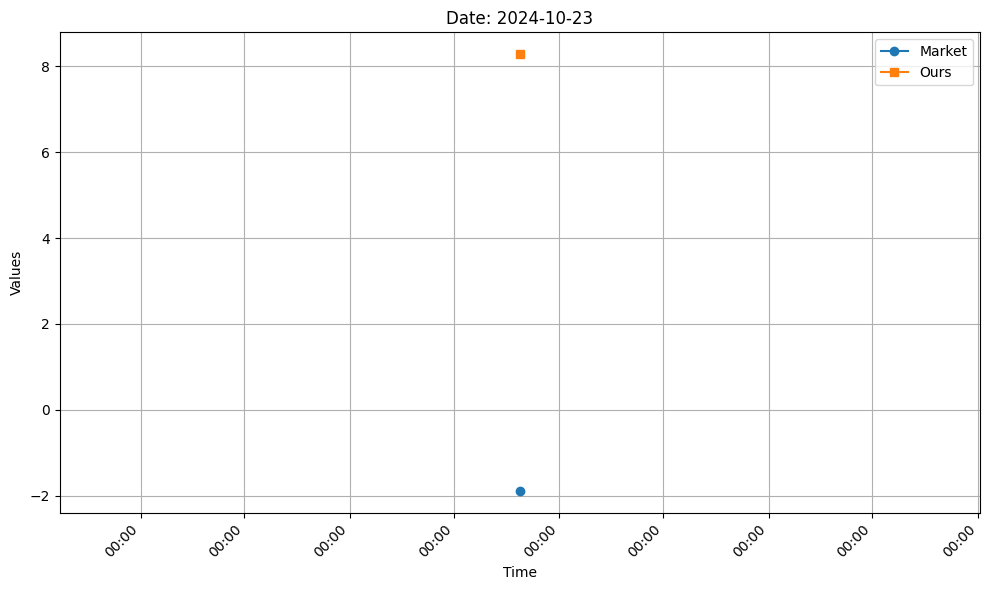

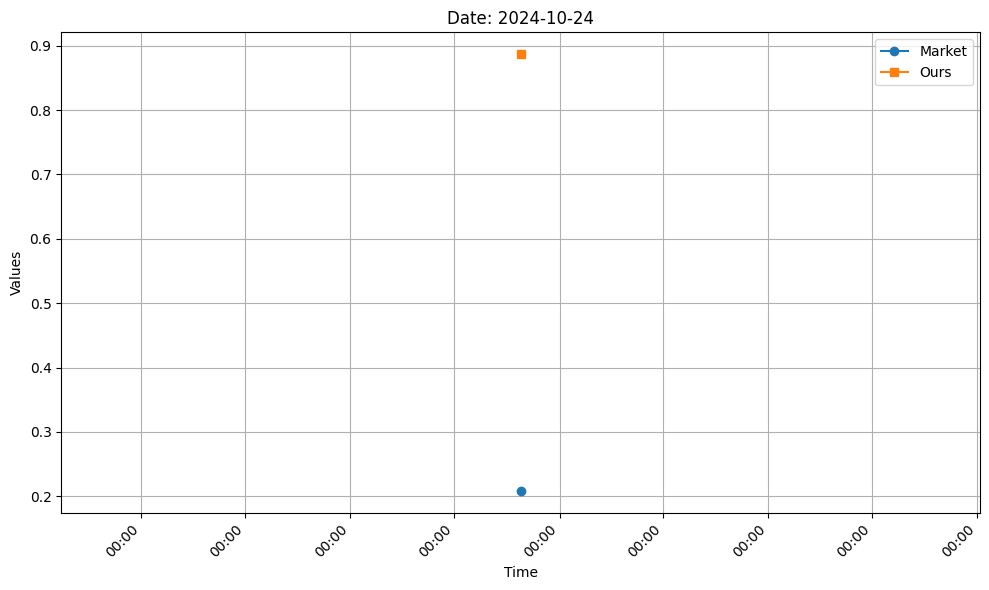

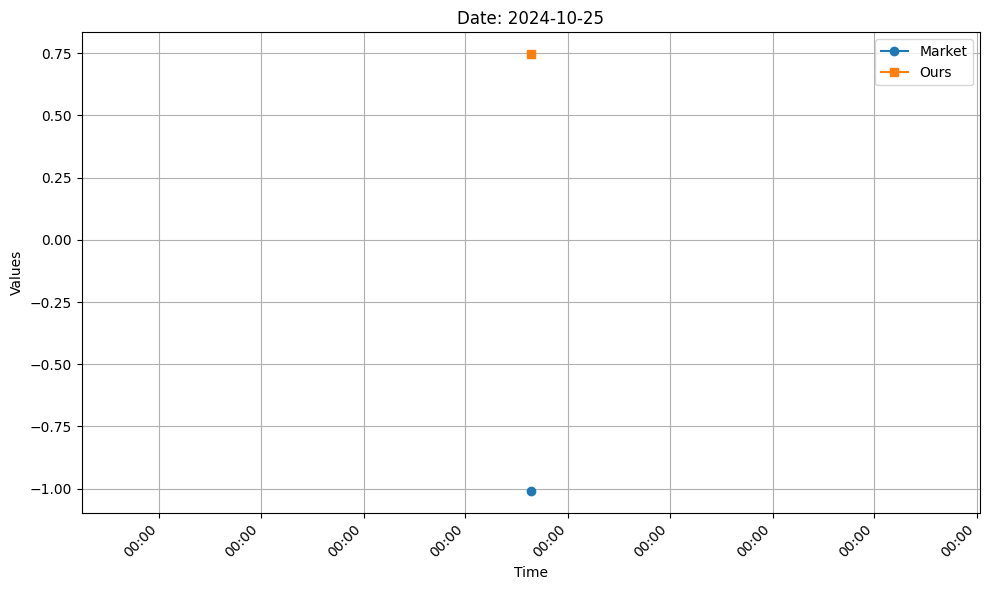

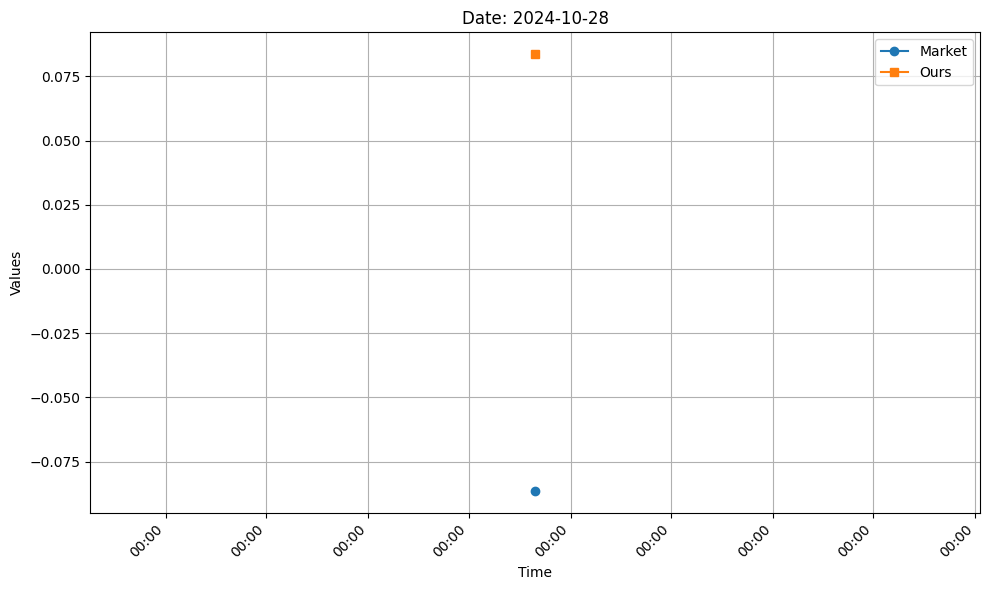

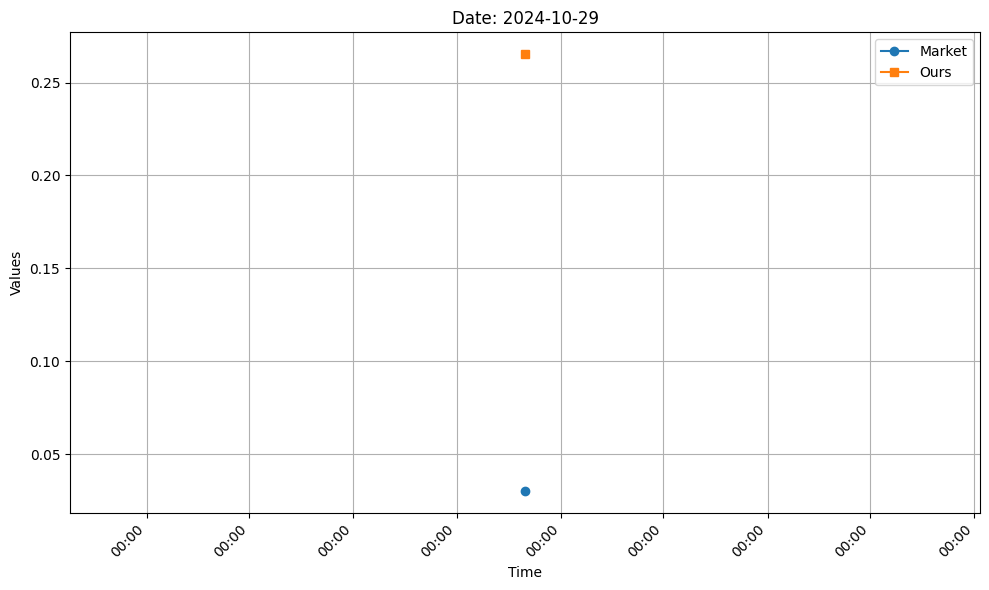

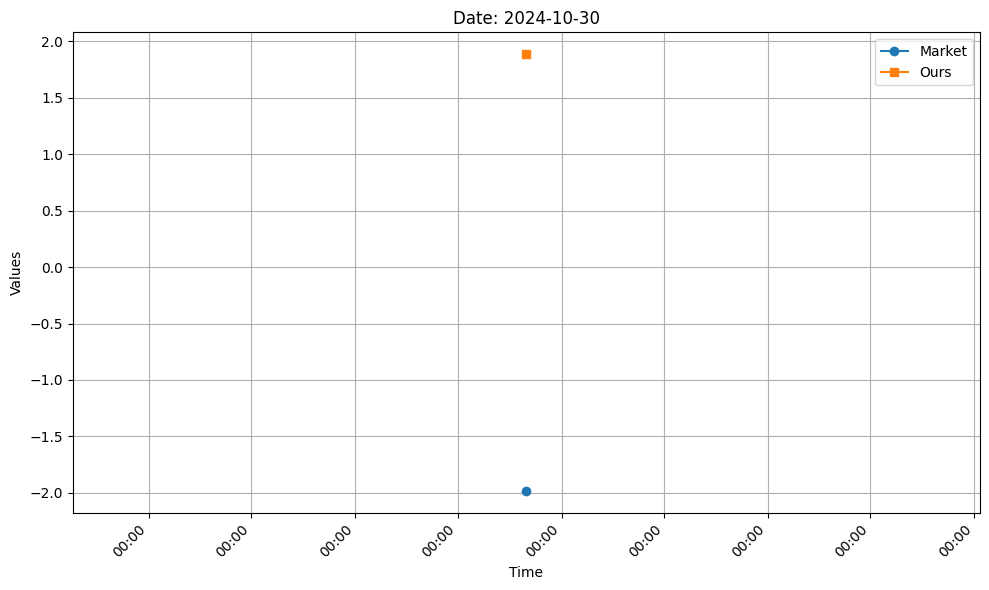

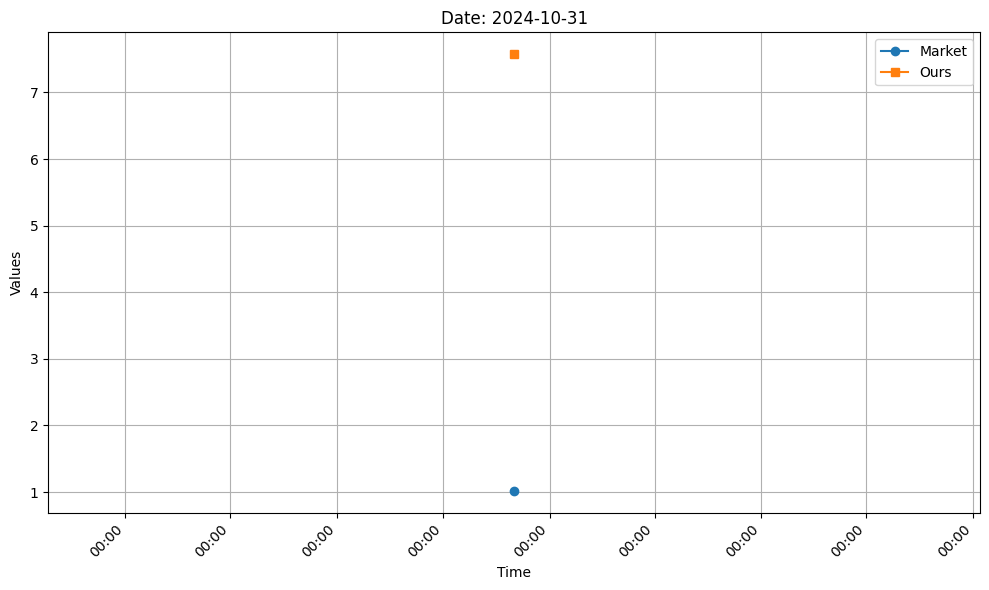

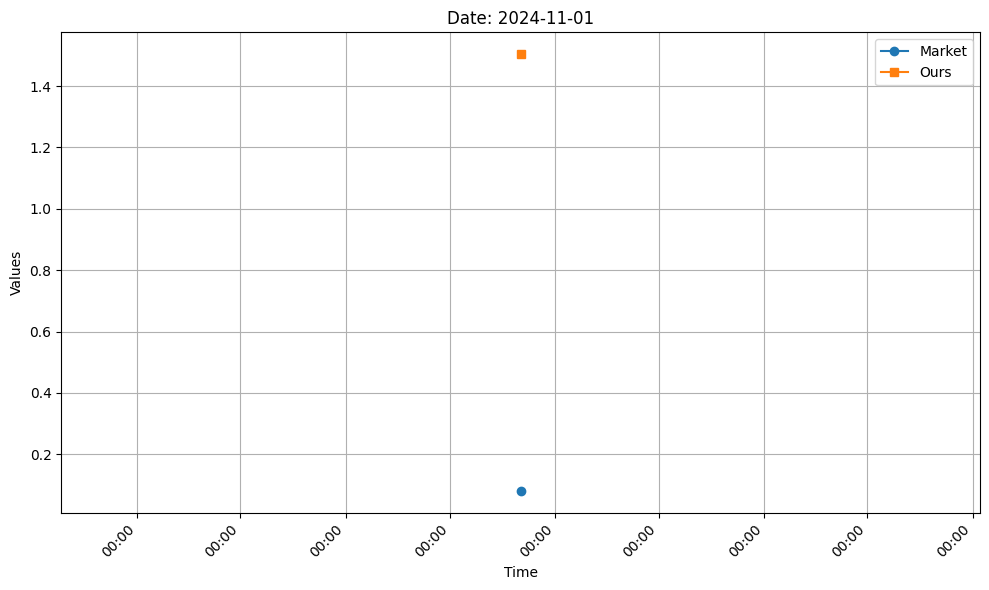

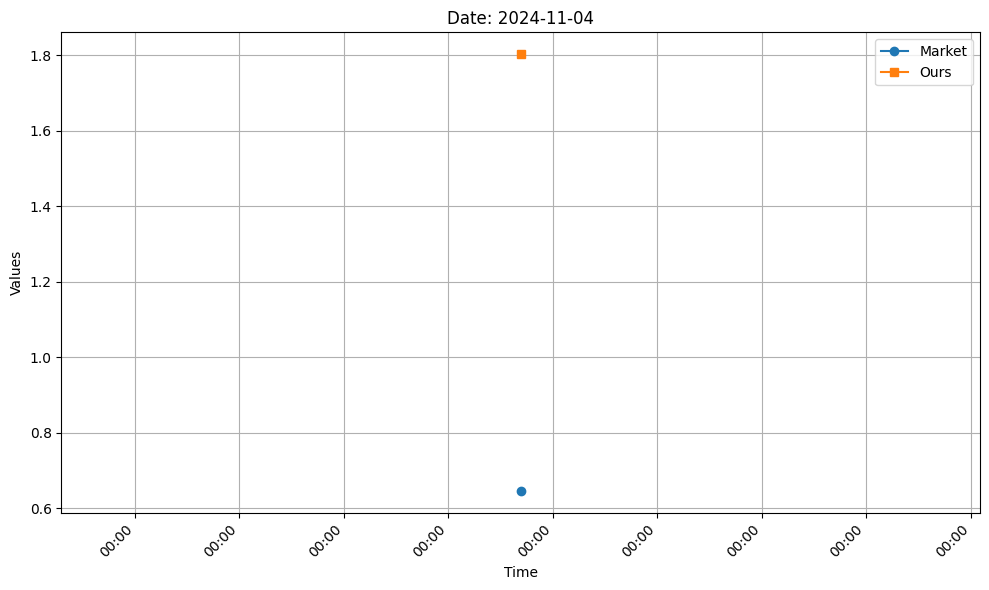

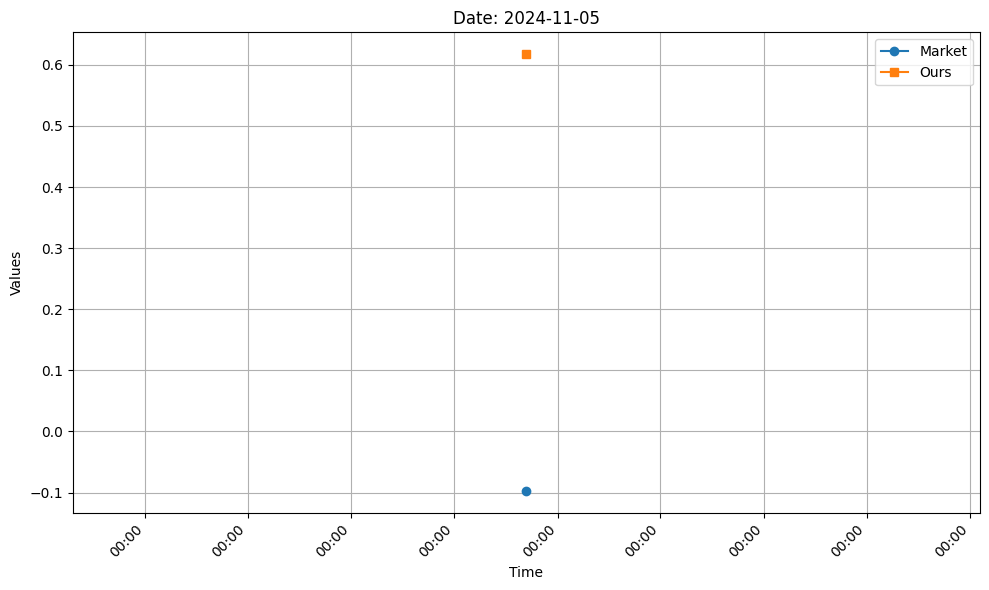

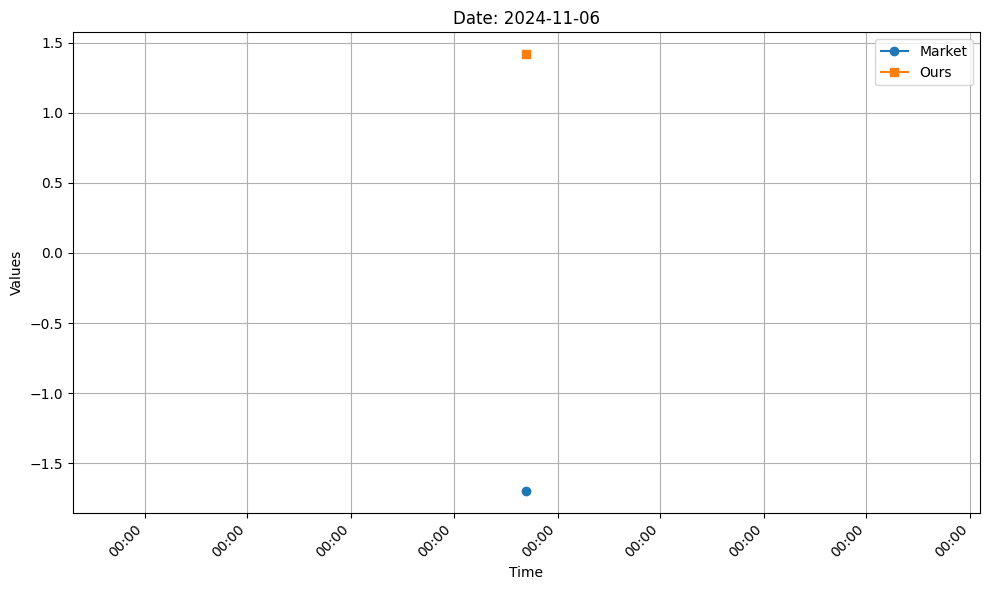

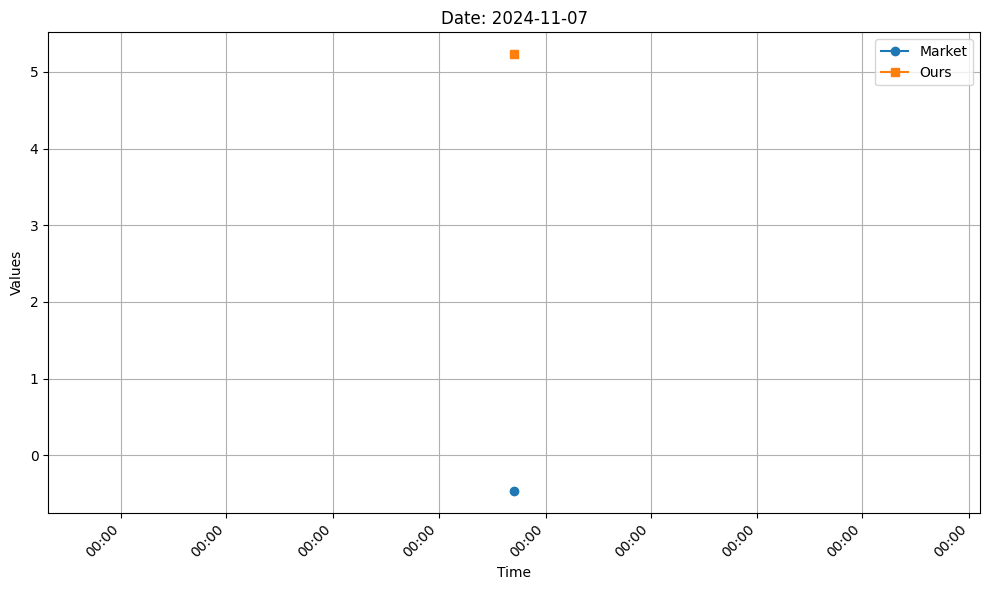

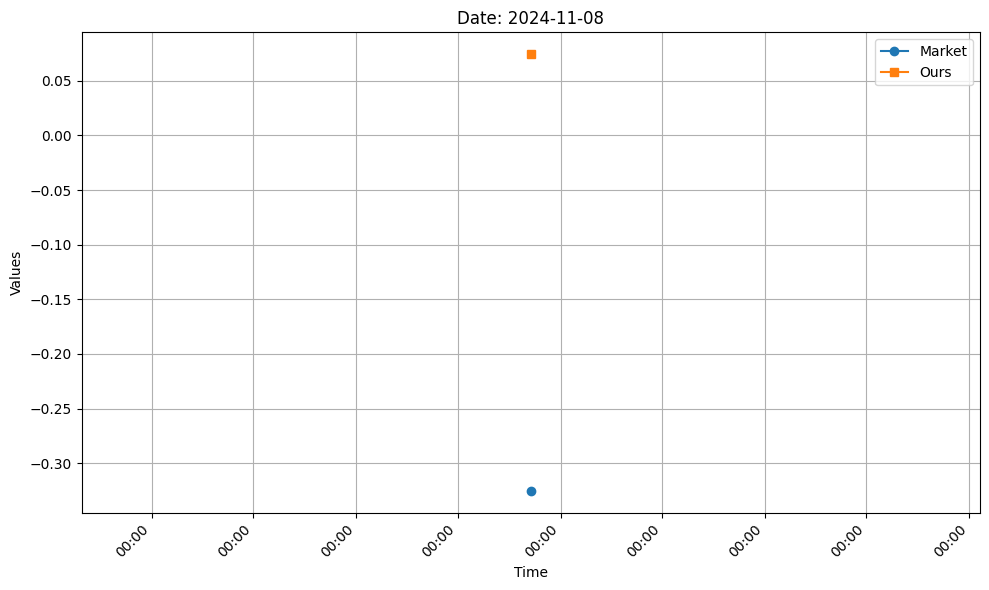

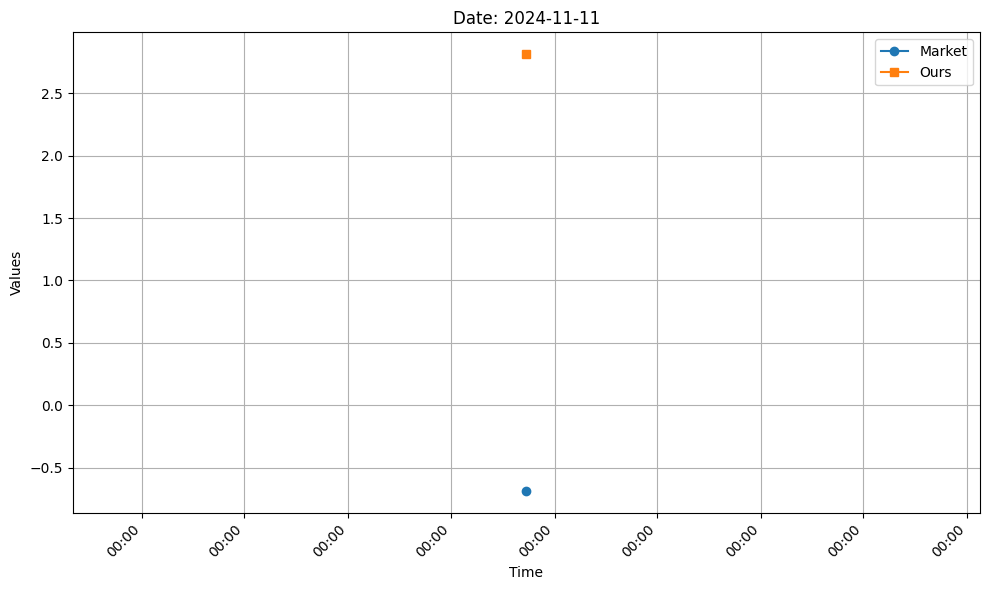

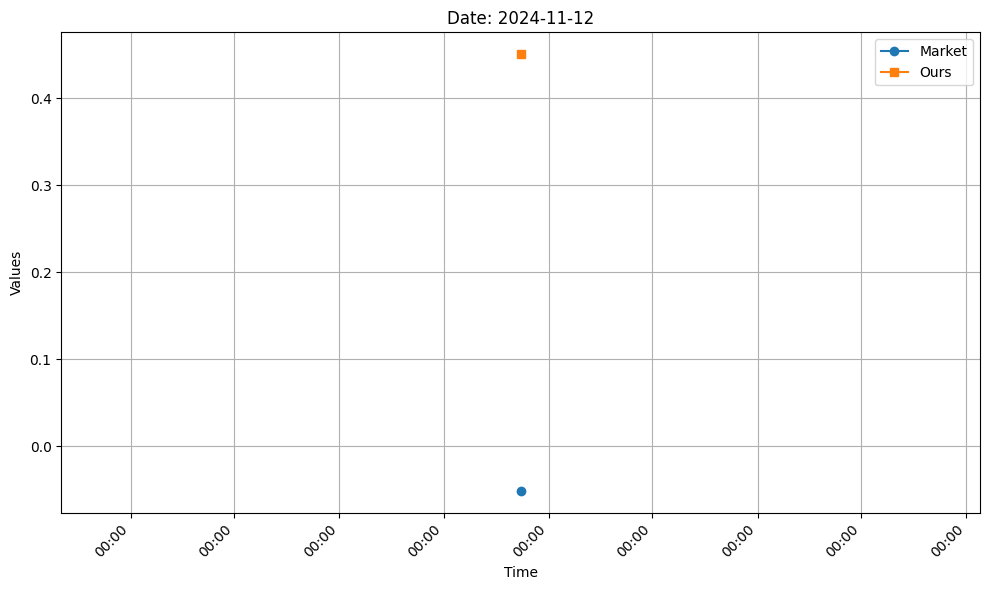

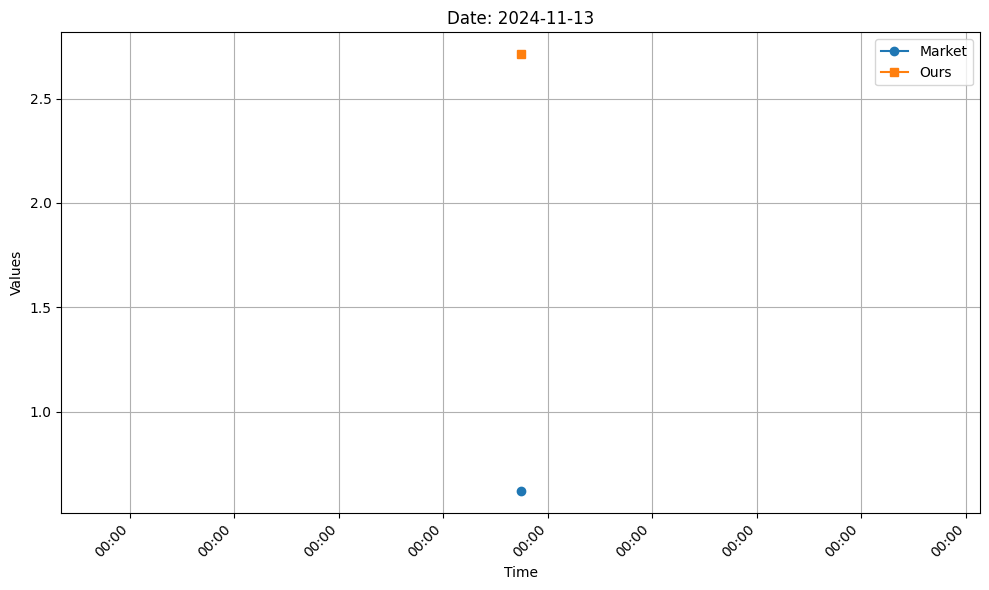

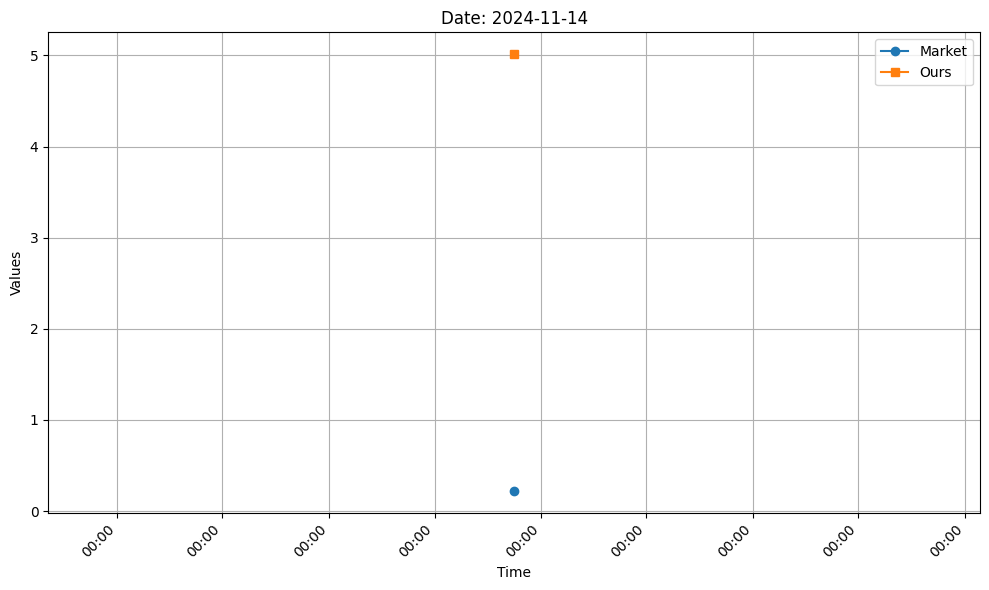

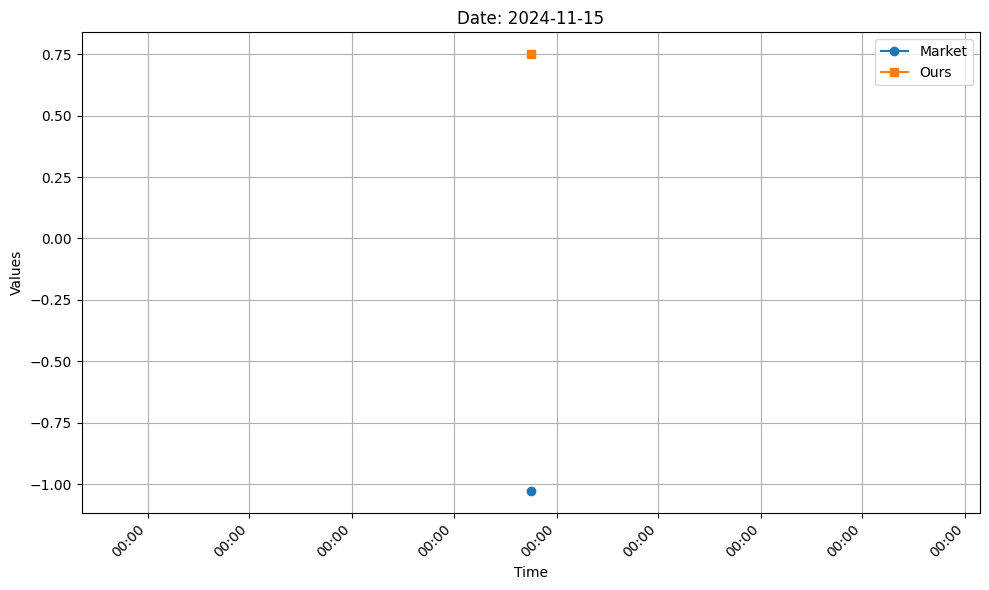

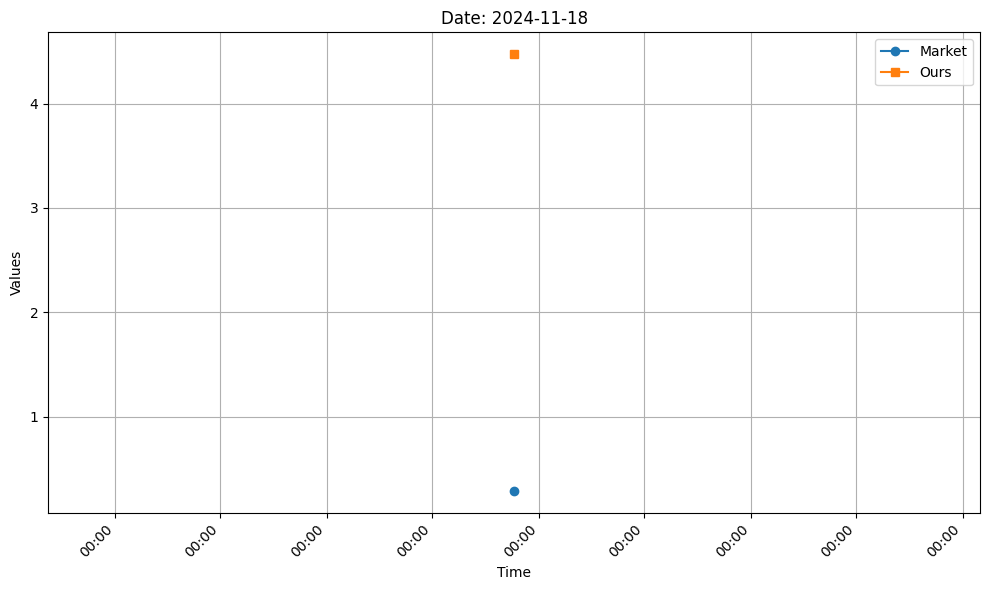

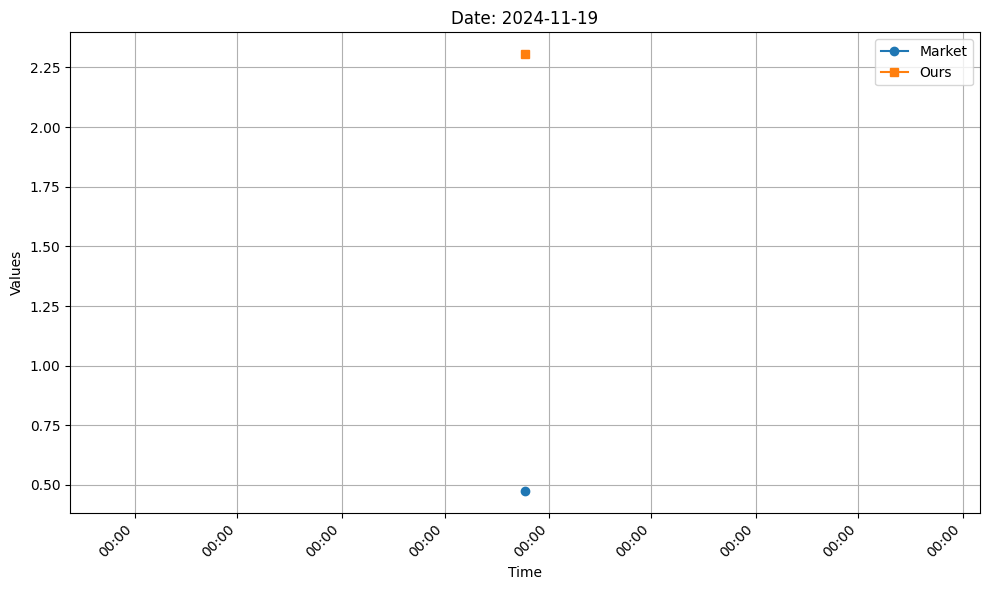

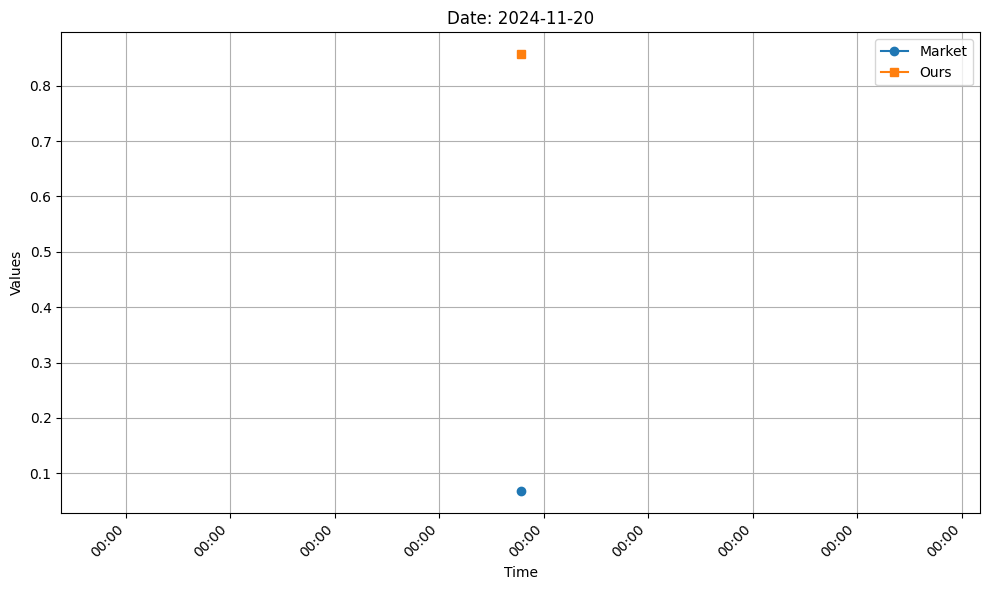

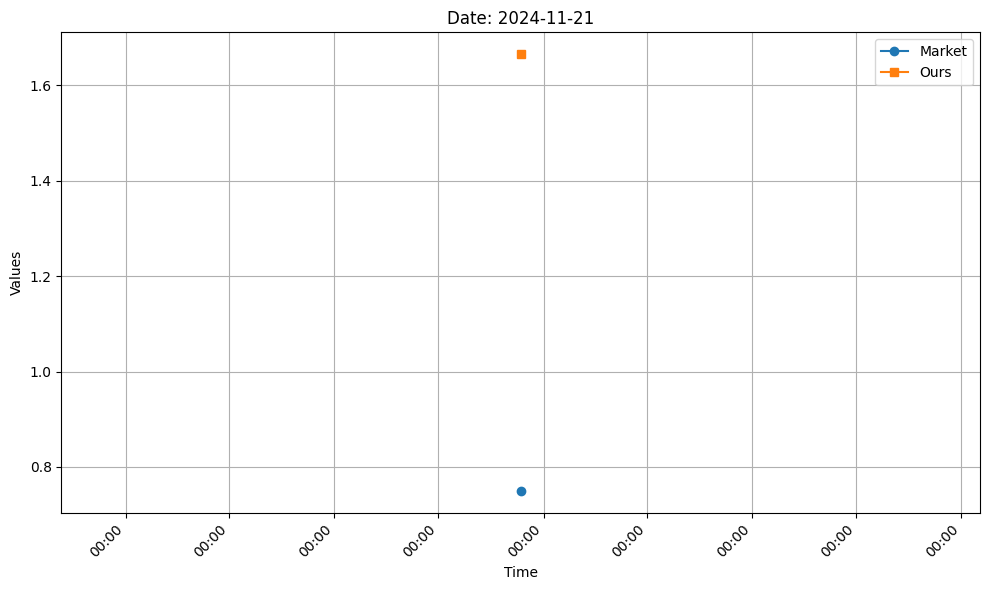

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Convert ts_event to datetime and extract the date
res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:6]  # Adjust to first 6 days

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(unique_dates)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Loop over each day and plot the time series
for date in unique_dates:
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Create a new figure for each day
    plt.figure(figsize=(10, 6))
    
    # Plot the data
    plt.plot(day_data['ts_event'], day_data['integral'], label='Market', marker='o')
    plt.plot(day_data['ts_event'], day_data["optimal_integral"], label='Ours', marker='s')
    
    # Formatting the x-axis to show time only
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title(f'Date: {date}')
    plt.legend()
    plt.grid(True)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()


In [126]:
res[['PnL',"date"]]

,PnL,date
0,-0.000411,2024-10-21
1,-0.000128,2024-10-21
2,0.000079,2024-10-21
3,-0.000013,2024-10-21
4,-0.000076,2024-10-21
...,...,...
187,0.004712,2024-11-21
188,0.004857,2024-11-21
189,0.004817,2024-11-21
190,0.004817,2024-11-21


In [127]:
res.columns

Index(['ts_event', 'bid_fill', 'ask_fill', 'Signed Volume', 'best_bid',
       'best_ask', 'Volatility', 'ADV', 'mid_price', 'delta_p', 'delta_Q',
       'price_impact', 'unperturbed_price', 'determined_alpha',
       'determined_nu', 'determined_alpha_prime', 'I_star_t', 'delta_Q_star',
       'myopic_market_obj', 'myopic_opt_obj', 'optimal_PnL', 'PnL', 'integral',
       'optimal_integral', 'date'],
      dtype='object')

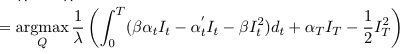

In [128]:
res['myopic_opt_obj'] = (beta * res['determined_alpha'] * res['I_star_t'] - res['determined_alpha_prime'] * res['I_star_t'] - beta*res['I_star_t']**2).fillna(0)


In [129]:
res.columns

Index(['ts_event', 'bid_fill', 'ask_fill', 'Signed Volume', 'best_bid',
       'best_ask', 'Volatility', 'ADV', 'mid_price', 'delta_p', 'delta_Q',
       'price_impact', 'unperturbed_price', 'determined_alpha',
       'determined_nu', 'determined_alpha_prime', 'I_star_t', 'delta_Q_star',
       'myopic_market_obj', 'myopic_opt_obj', 'optimal_PnL', 'PnL', 'integral',
       'optimal_integral', 'date'],
      dtype='object')

In [130]:
# Full PnL

def completedPnL(data):

    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    

    lam = 170.6

    def calcoptimalPnL(df):
        res = (((df['myopic_opt_obj'] + df["determined_alpha"].iloc[-1] * df["I_star_t"].iloc[-1] - (0.5 *df["I_star_t"].iloc[-1])) * (lam**(-1))))
        return res
    def calcPnL(df):
        res = (((df['myopic_market_obj'] + df["determined_alpha"].iloc[-1] * df["price_impact"].iloc[-1] - (0.5 *df["price_impact"].iloc[-1])) * (lam**(-1))))
        return res
        
    data['complete_optimal_PnL'] = data.groupby('date').apply(calcoptimalPnL,include_groups=False).reset_index(level=0, drop=True)
    data['completePnL'] = data.groupby('date').apply(calcPnL,include_groups=False).reset_index(level=0, drop=True)
    
    
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data


res = completedPnL(res)


In [131]:
res.columns

Index(['ts_event', 'bid_fill', 'ask_fill', 'Signed Volume', 'best_bid',
       'best_ask', 'Volatility', 'ADV', 'mid_price', 'delta_p', 'delta_Q',
       'price_impact', 'unperturbed_price', 'determined_alpha',
       'determined_nu', 'determined_alpha_prime', 'I_star_t', 'delta_Q_star',
       'myopic_market_obj', 'myopic_opt_obj', 'optimal_PnL', 'PnL', 'integral',
       'optimal_integral', 'complete_optimal_PnL', 'completePnL'],
      dtype='object')

### Graphing Complete PnL equation against Optimal PnL

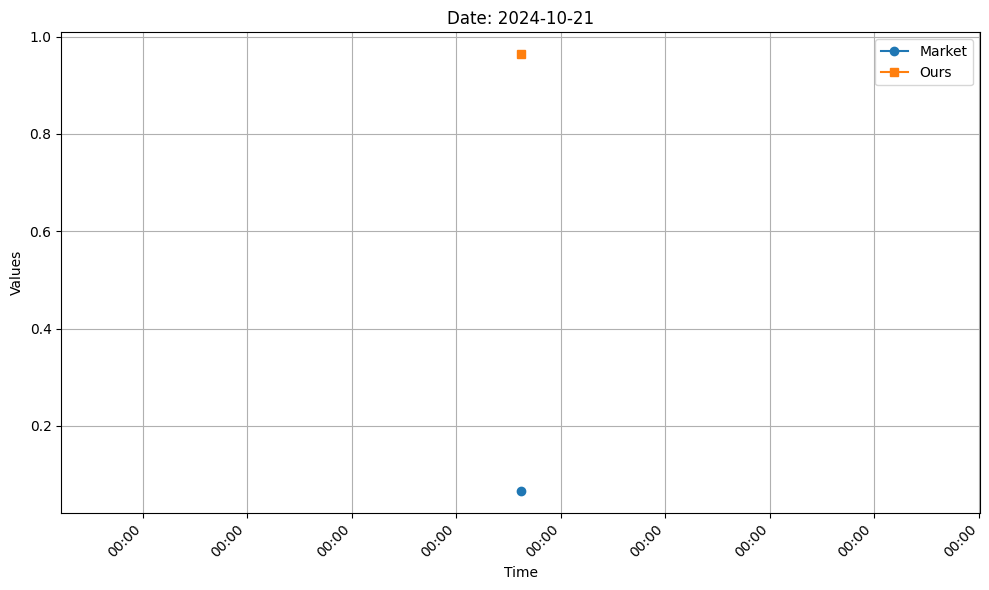

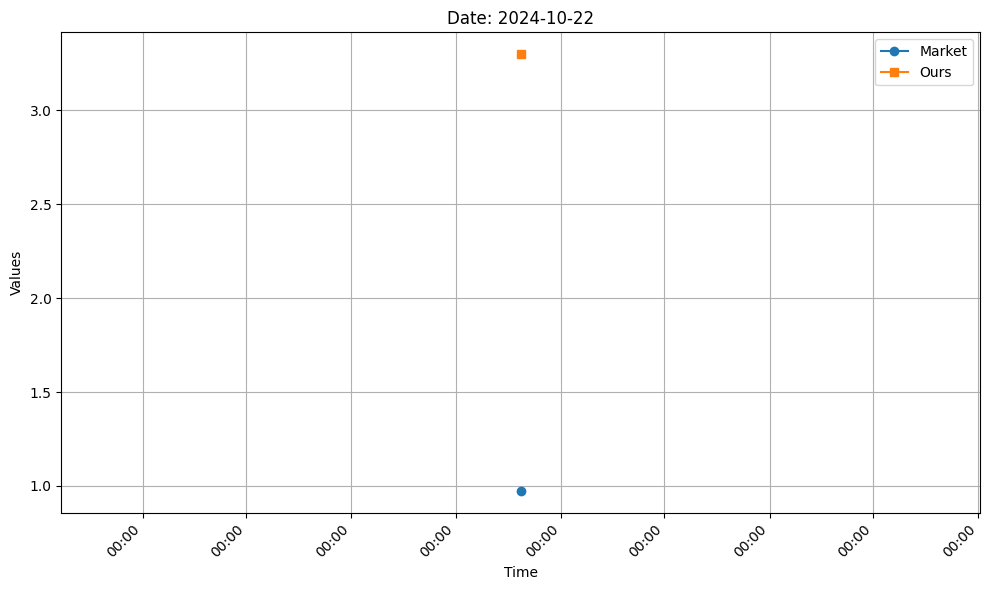

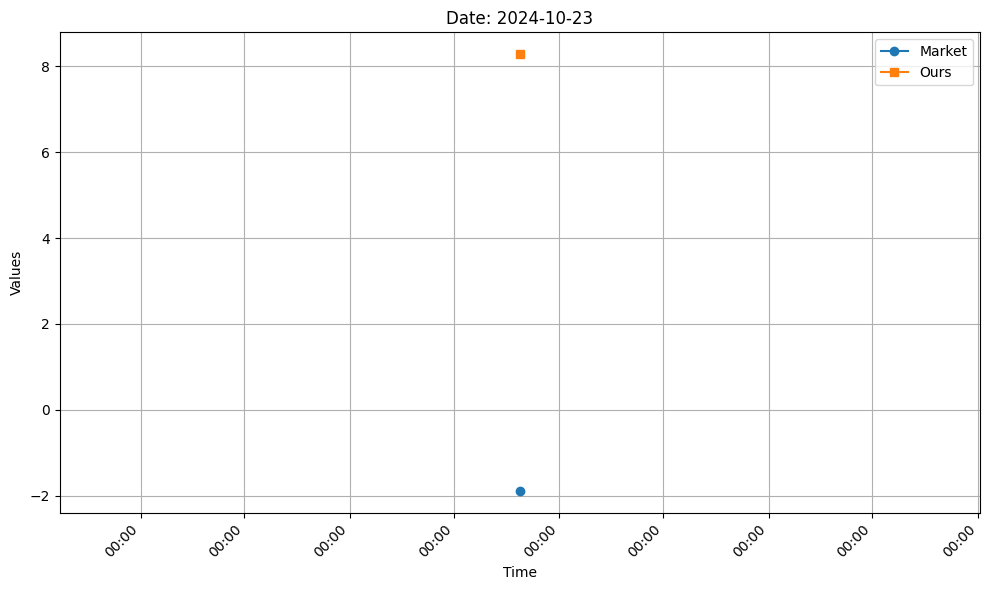

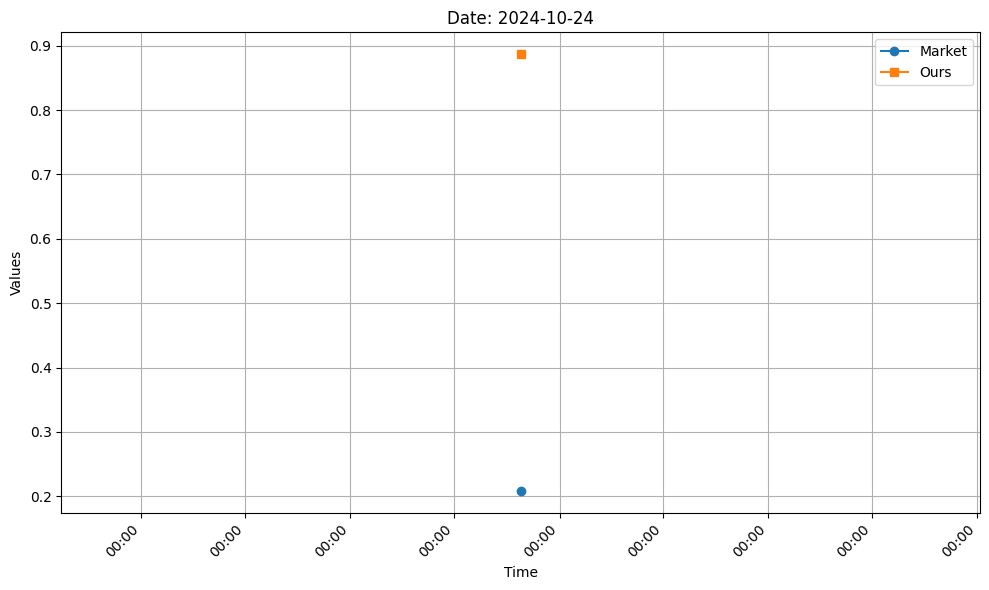

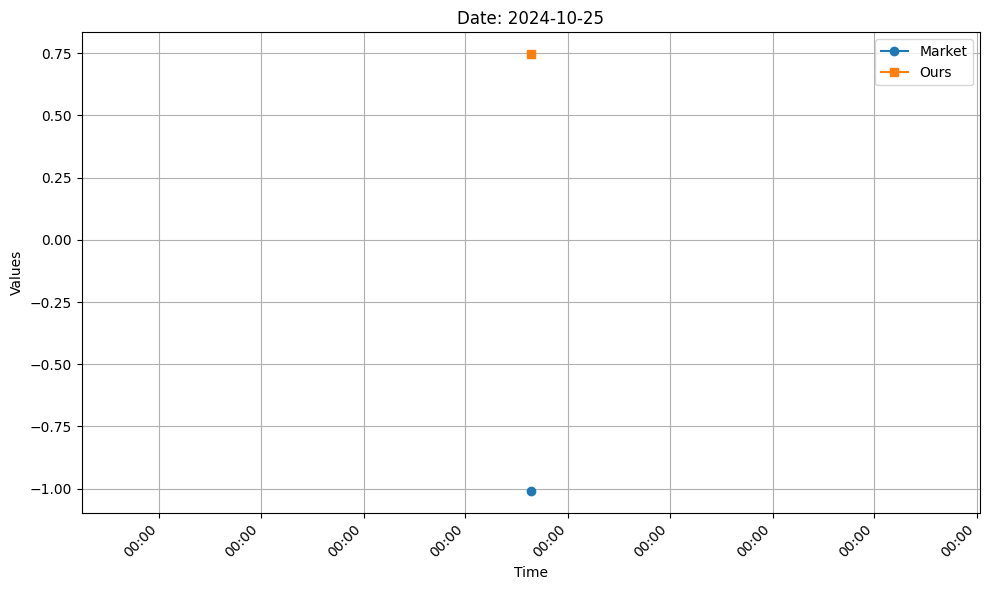

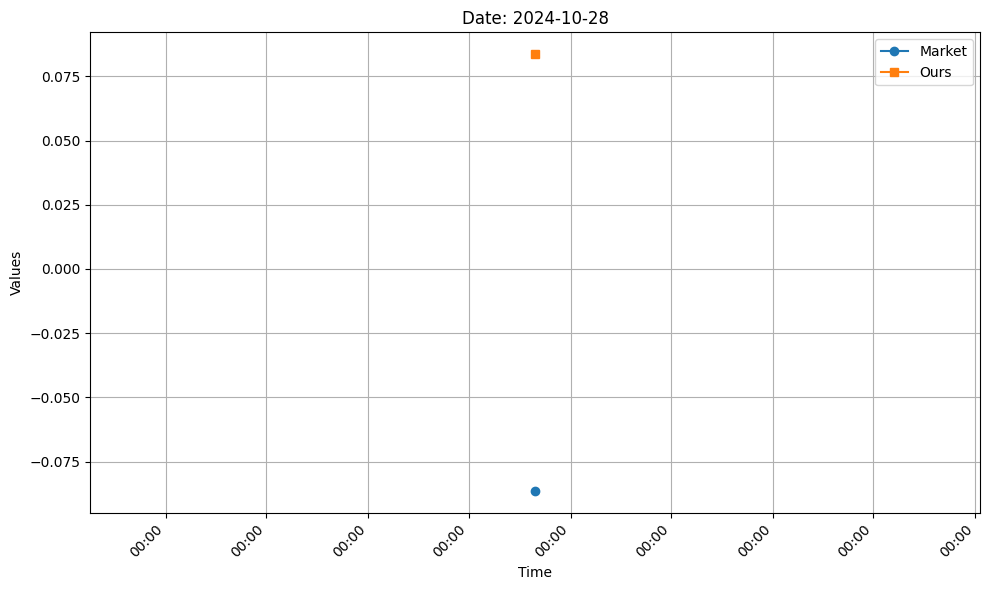

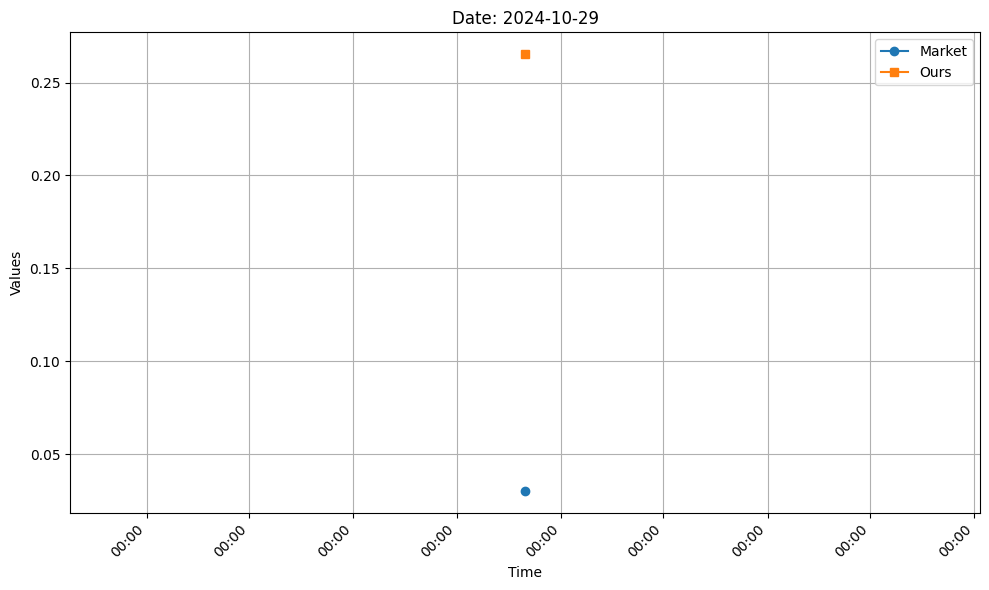

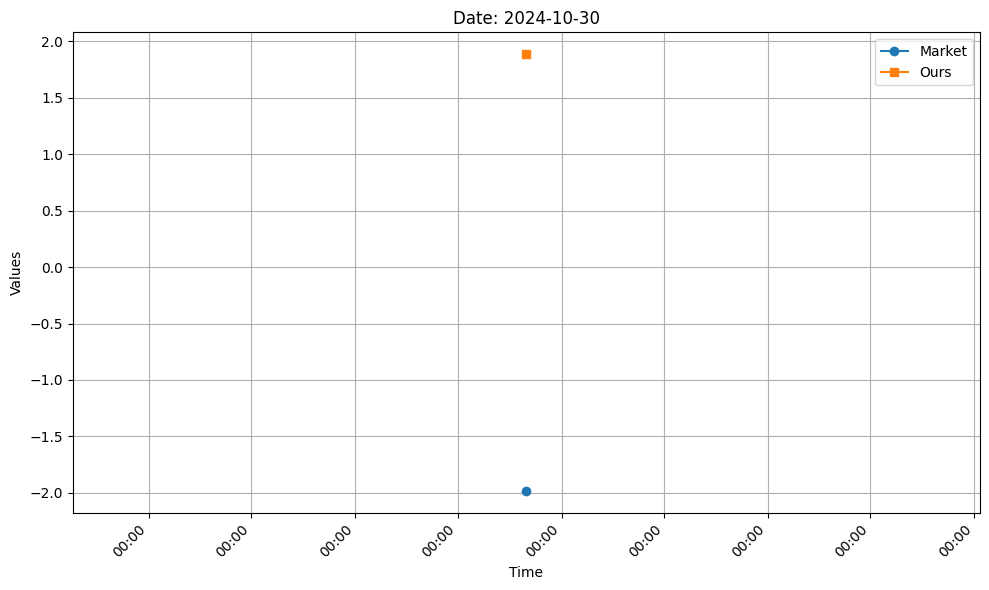

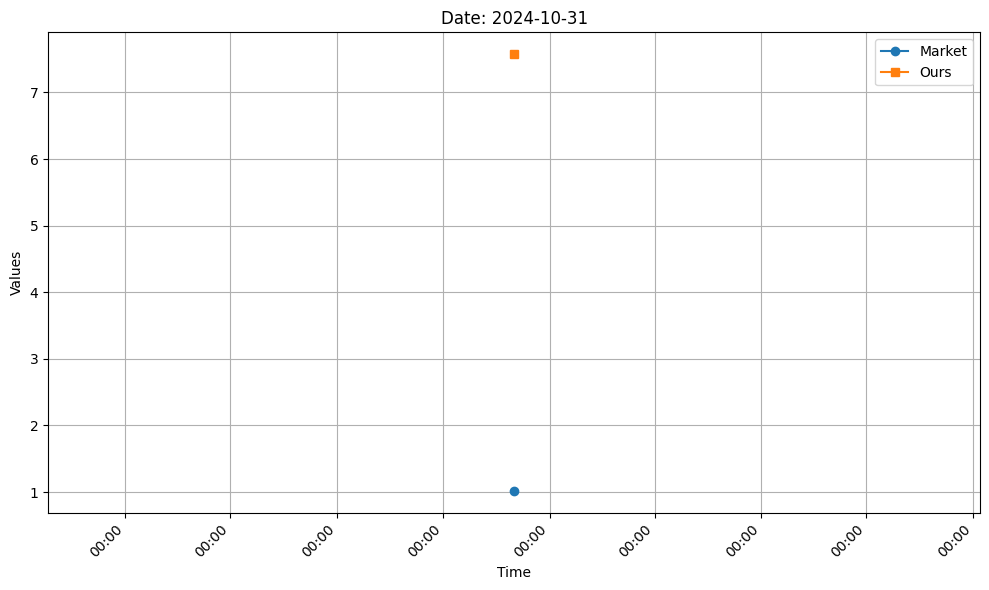

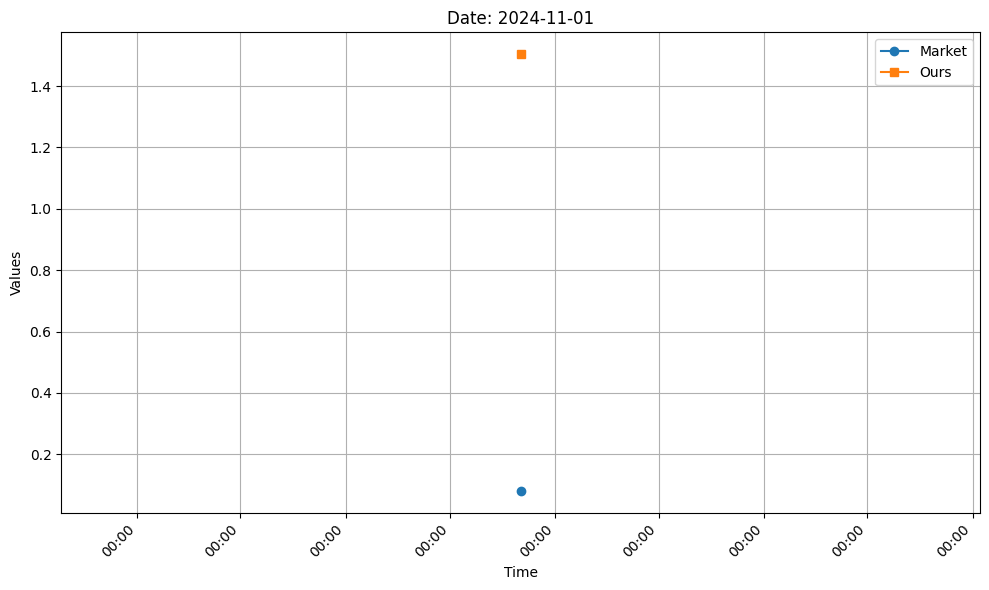

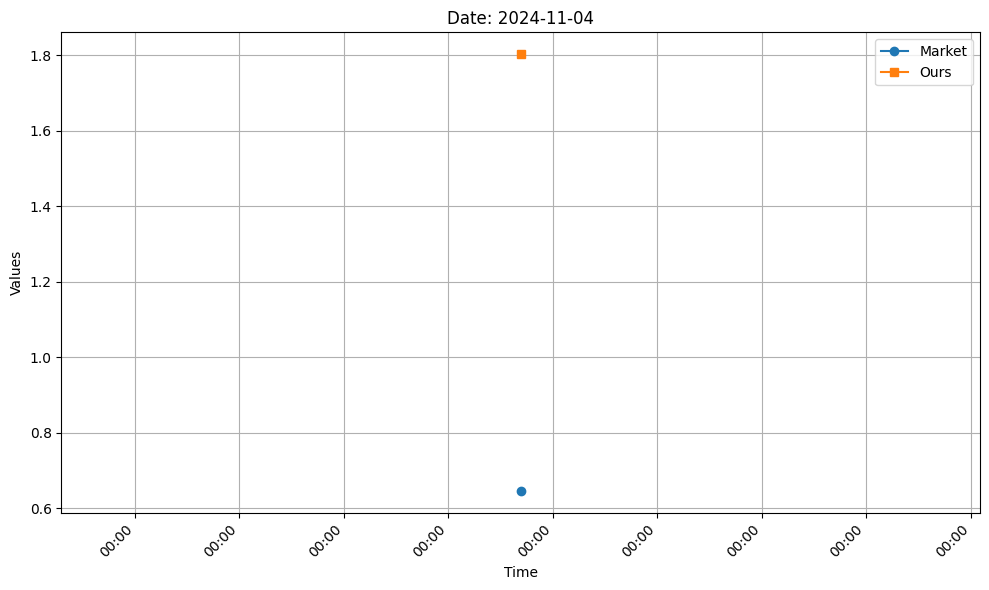

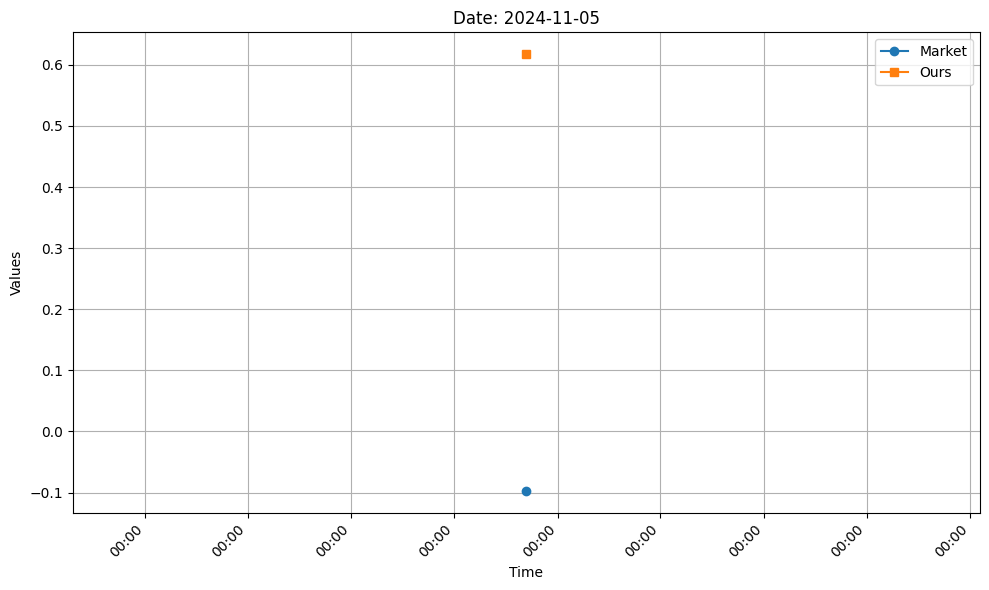

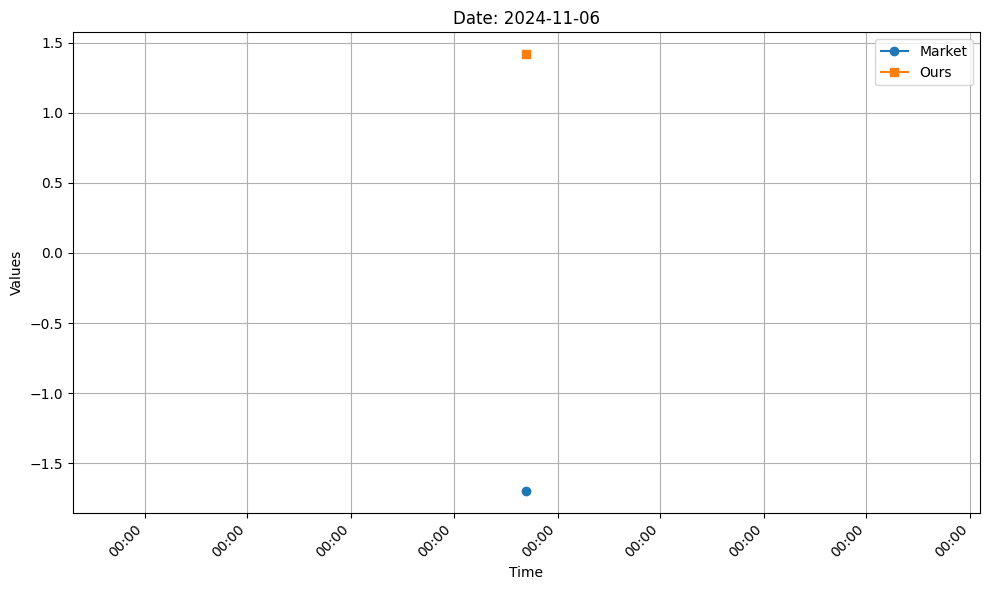

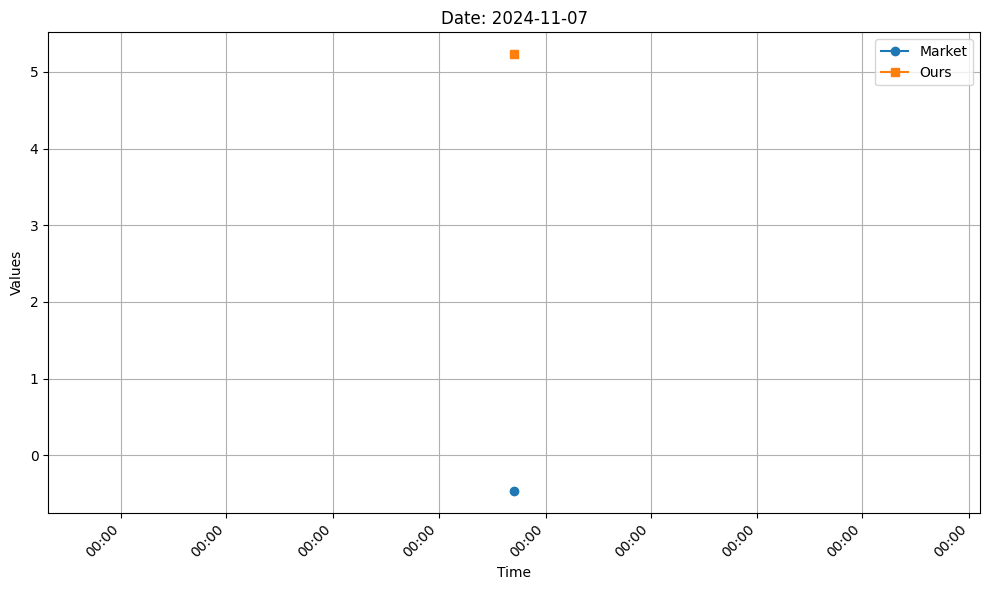

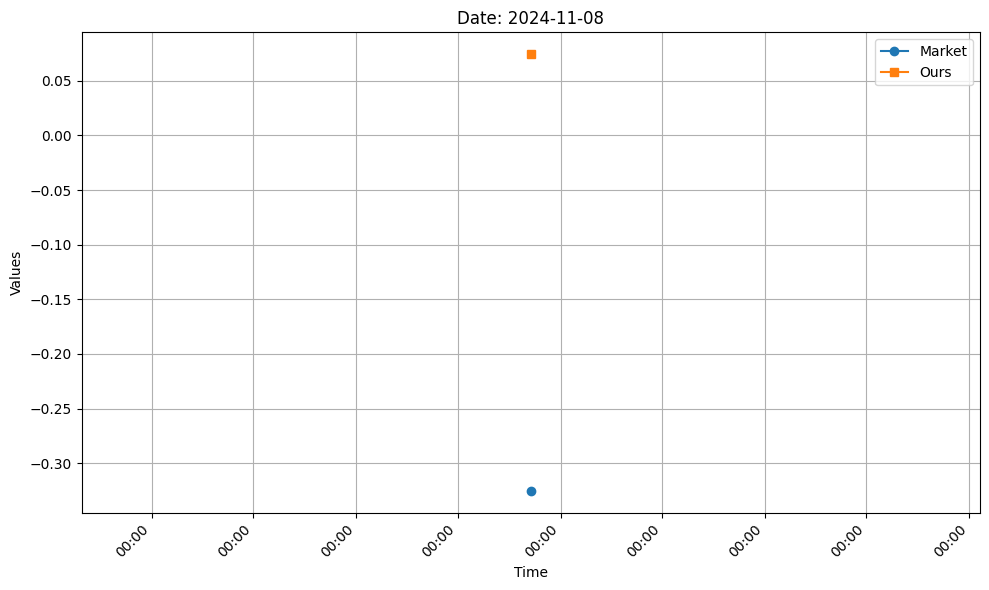

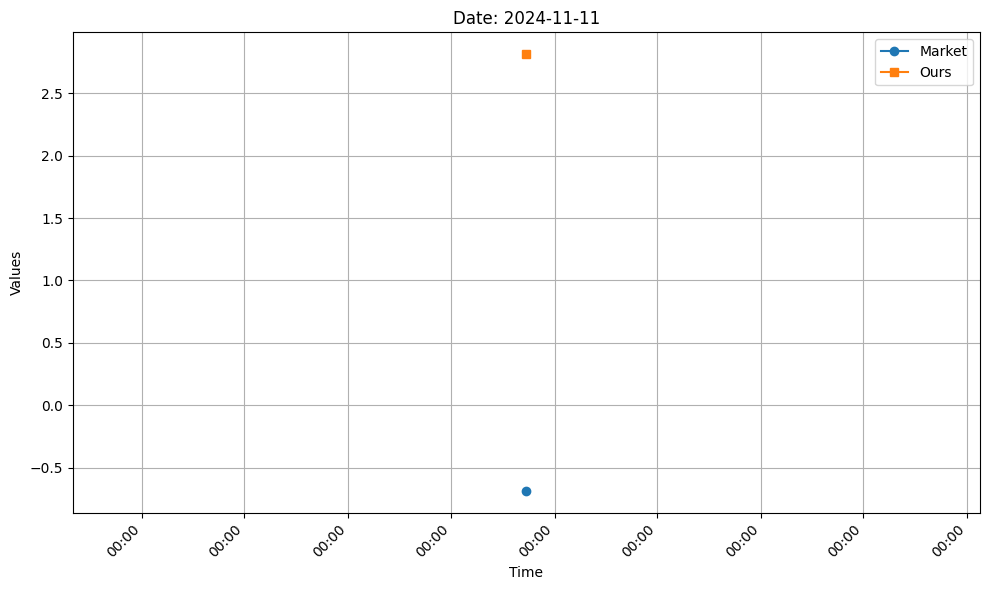

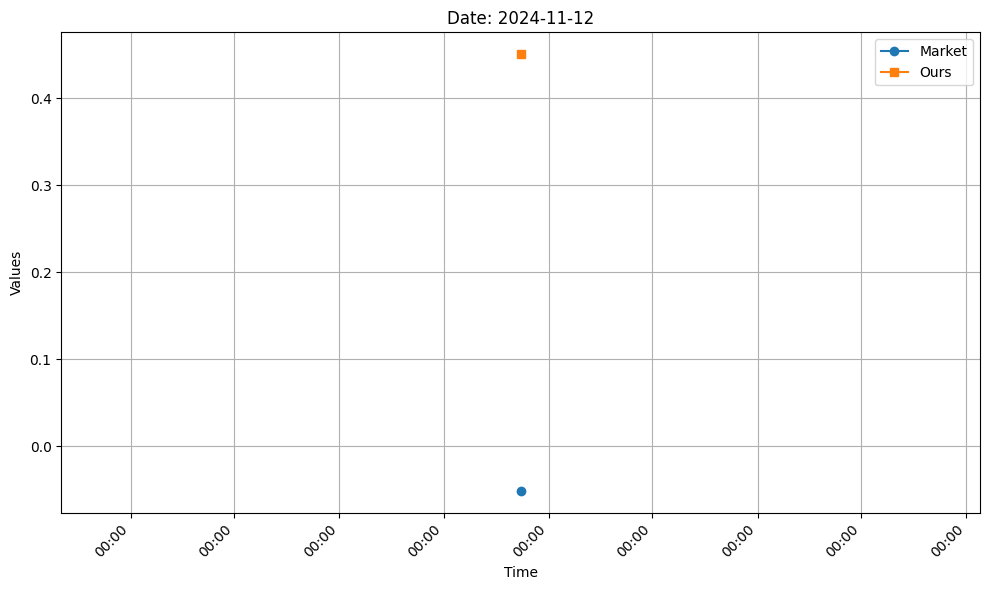

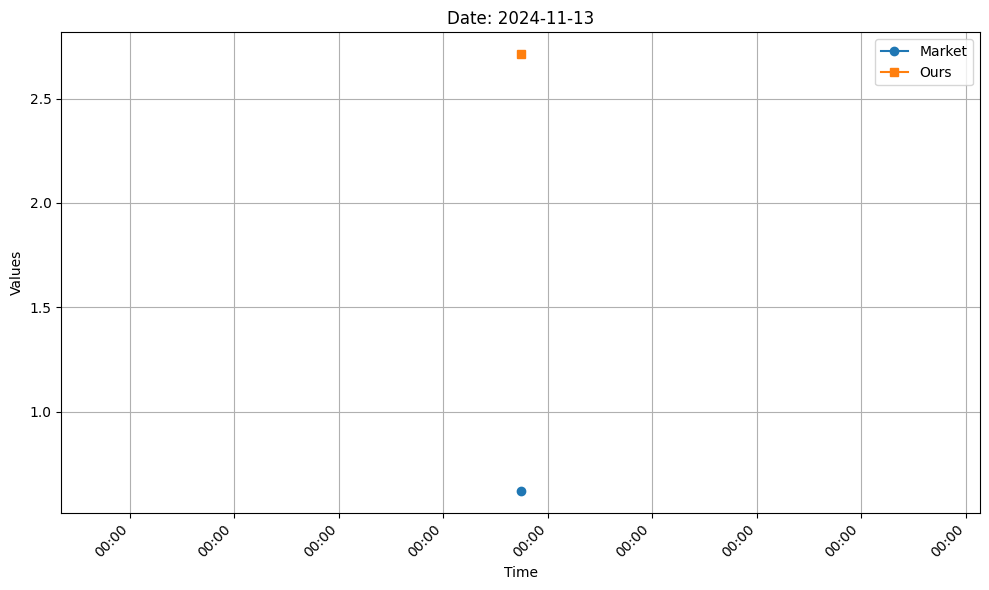

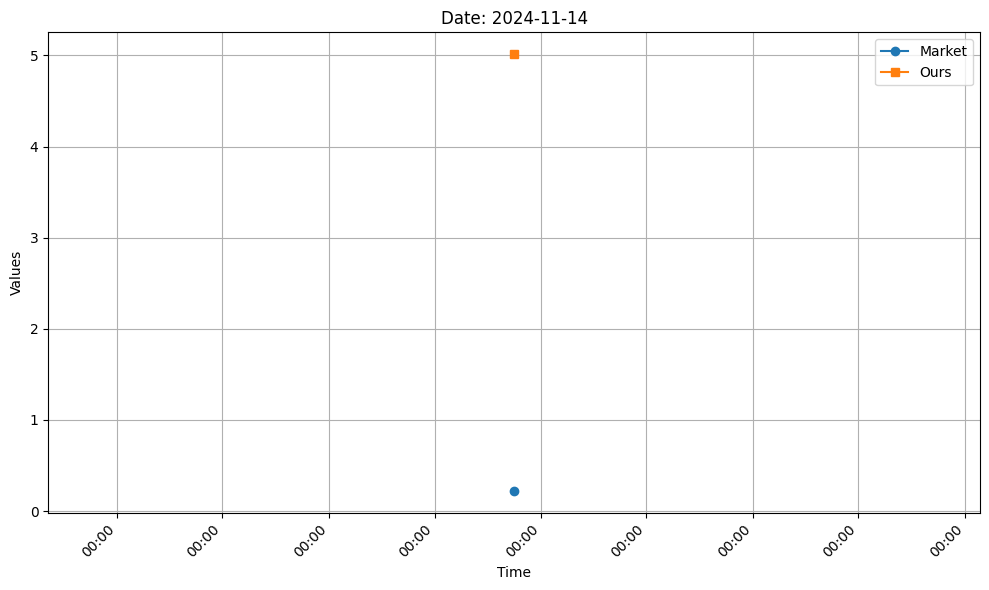

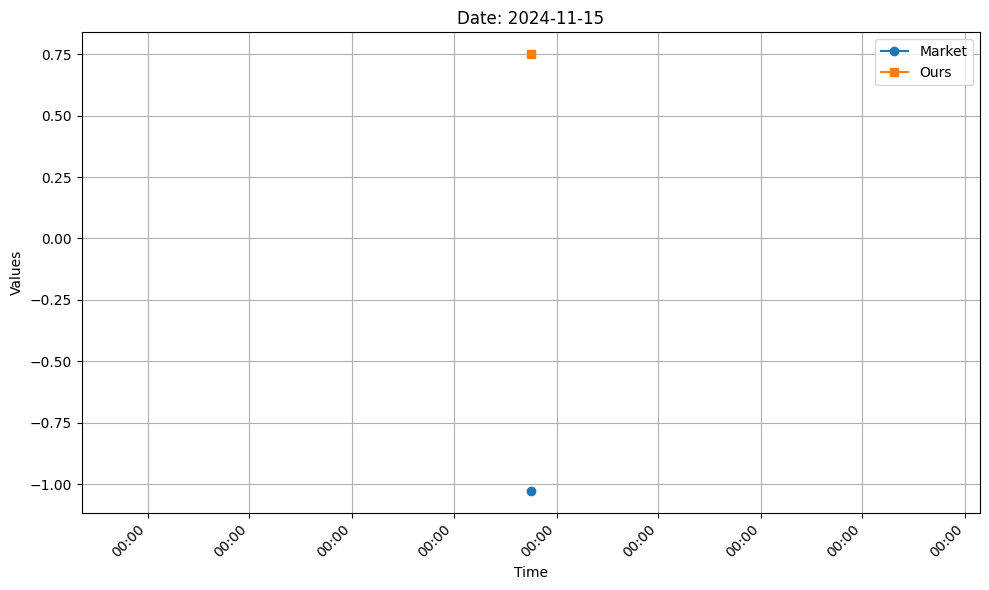

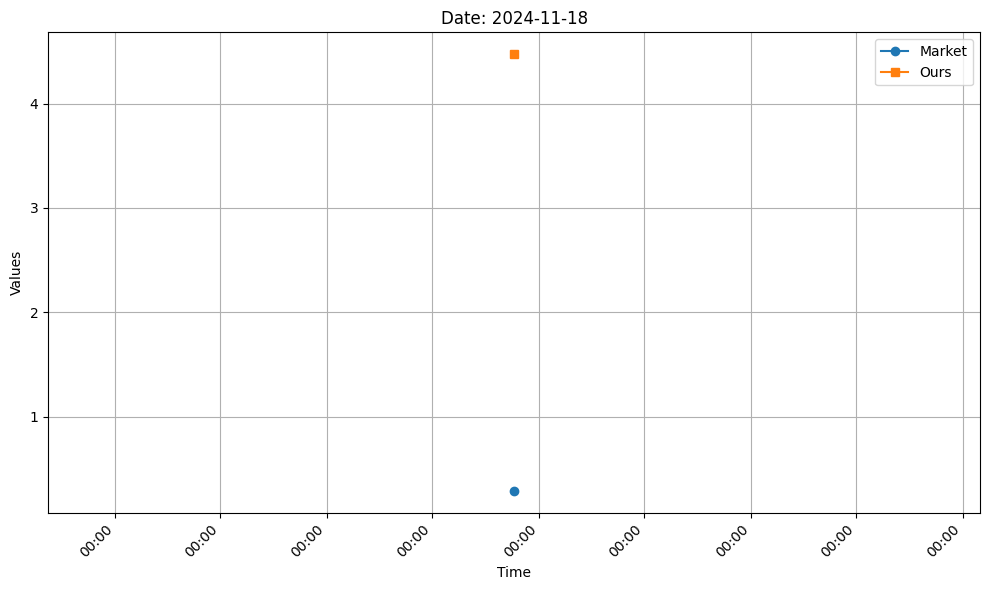

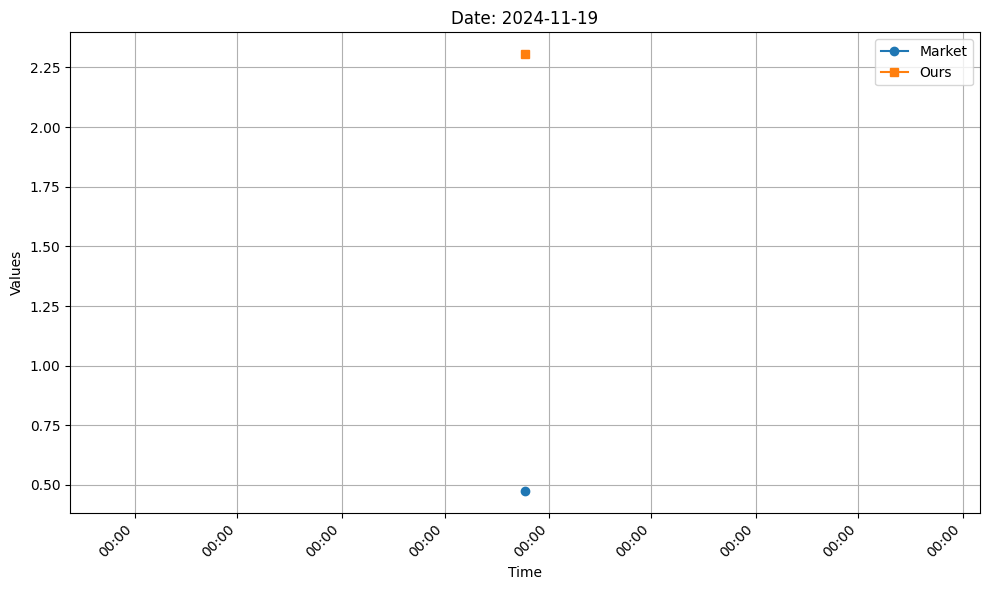

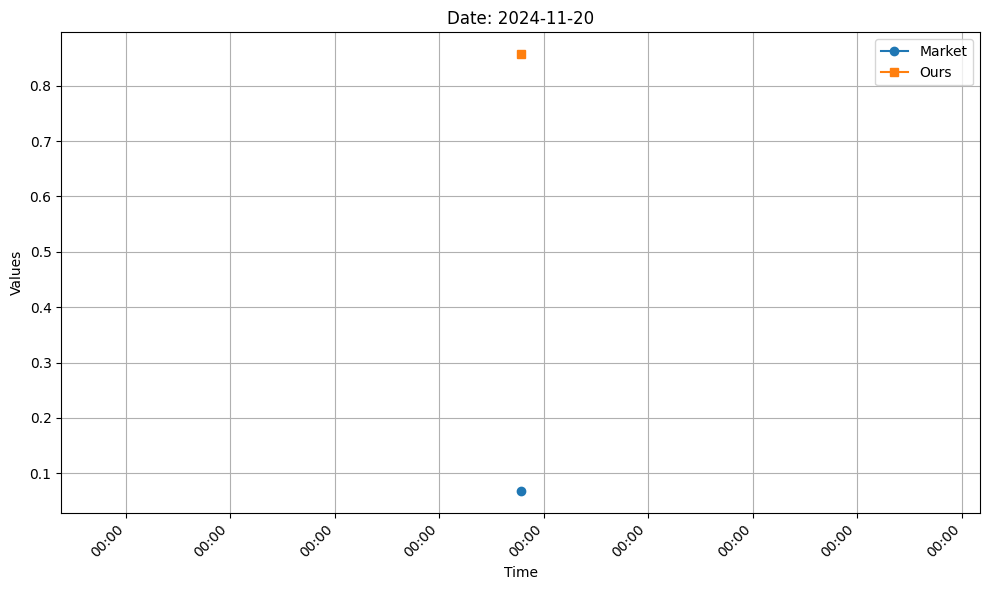

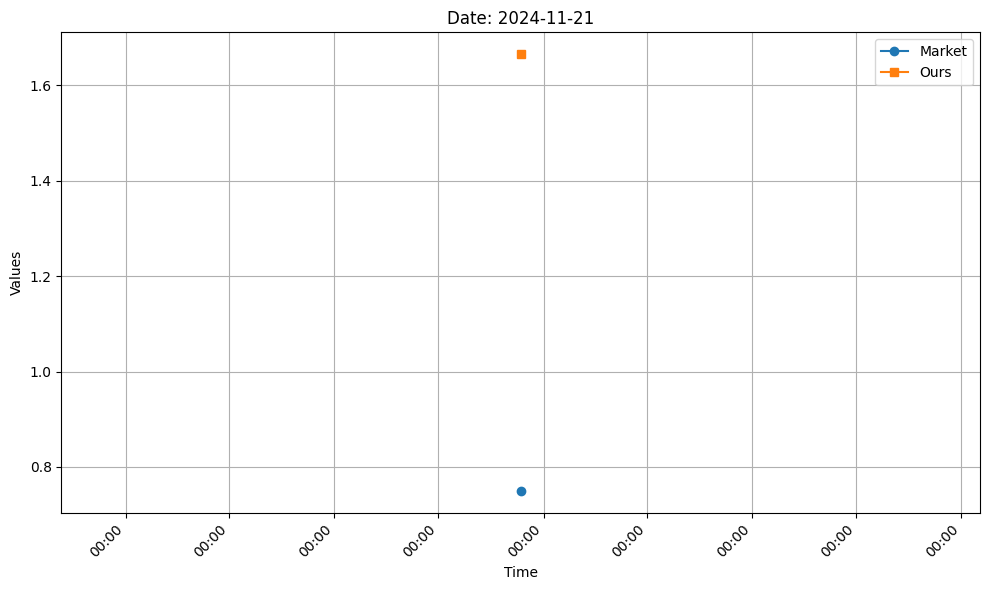

In [136]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Convert ts_event to datetime and extract the date
res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:6]  # Adjust to first 6 days

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(unique_dates)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Loop over each day and plot the time series
for date in unique_dates:
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Create a new figure for each day
    plt.figure(figsize=(10, 6))
    
    # Plot the data
    plt.plot(day_data['ts_event'], day_data['completePnL'], label='Market', marker='o')
    plt.plot(day_data['ts_event'], day_data["complete_optimal_PnL"], label='Ours', marker='s')
    
    # Formatting the x-axis to show time only
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title(f'Date: {date}')
    plt.legend()
    plt.grid(True)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()


In [133]:
diff = []
for date in unique_dates:
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    
    temp = day_data["complete_optimal_PnL"] - day_data["completePnL"]

    diff.append(temp)
    

In [134]:
diff[0]

0   -0.000155
1    0.003017
2    0.001101
3    0.000488
4    0.000026
5   -0.000107
6   -0.000104
7   -0.000256
dtype: float64

In [135]:
count = 0

indexes = []
for i in range(len(diff)):
    for idx,val in enumerate(diff[i]):
        if val < 0:
            count += 1
            indexes.append((i,diff[i]))

wins = len(diff)* 8  - count
print(f"total df : {len(diff) *8}")
print(f"Losses : {count}")
print(f"Wins : {wins}")
print(f"Win Ratio : {103/192}")

total df : 192
Losses : 83
Wins : 109
Win Ratio : 0.5364583333333334
